# NLP Classification of Technical Newsgroup Posts - EDA

notebook 1

Table of Content:

- [Problem Definition & Context](#problem-definition-context)
- [Dataset Selection & Description](#dataset-selection-description)
- [Primary Success Criteria](#primary-success-criteria)
- [Dataset overview-and-initial-checks](#dataset-overview-and-initial-checks)
- [Raw text artifact audit](#raw-text-artifact-audit)
- [Preprocessing Regimes & their impact](#preprocessing-regimes-their-impact)
- [Vocabulary and class-specific lexical signals](#vocabulary-and-class-specific-lexical-signals)
- [Category overlap and expected confusion pairs](#category-overlap-and-expected-confusion-pairs)
- [Evaluation slices derived from EDA](#evaluation-slices-derived-from-eda)
- [EDA implications for modelling](#eda-implications-for-modelling)

In [123]:
# standard library
import glob
import itertools
import json
import os
import platform
import re
import tarfile
import time
import urllib.request
from datetime import datetime
from pathlib import Path

# core data
import numpy as np
import pandas as pd

# machine learning
import sklearn
import umap

from scipy.sparse import vstack
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import (
    CountVectorizer,
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

# NLP
import spacy

# visualisation
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## <a id="problem-definition-context"></a>Problem Definition & Context

### Problem Framing

This project investigates whether NLP models can reliably classify messy technical discussion posts into fine-grained topic categories after leakage-prone metadata and source artifacts are controlled.

The task is framed as a supervised multi-class text classification problem: given the text of a post from a technical subset of the 20 Newsgroups dataset, predict its original newsgroup category.

The selected categories cover related but distinct areas of computing and technology: graphics, Windows-related discussion, IBM PC hardware, Mac hardware, X Window systems, electronics, and cryptography. Because several categories are semantically close, the task is not only broad topic recognition, but also fine-grained distinction between overlapping technical domains.

The central question is not simply whether a classifier can achieve a high score. Instead, the project asks whether model performance remains trustworthy when direct category leakage, identifying metadata, routing headers, quoted replies, signatures, and source-specific artifacts are removed or controlled.

This distinction matters because the original raw posts contain Usenet-specific structure. In this project, `text_raw` is retained for audit and feature extraction, but not treated as a fair modelling input, because it contains direct `Newsgroups` information and other metadata that would not be acceptable as predictive shortcuts in a responsible topic-routing system.

The main fair modelling representation is `text_subject_body_clean`, which preserves the subject and message body while removing or masking direct leakage and high-risk metadata. Additional text regimes are used as diagnostic ablations to test the impact of metadata-rich structure, subject removal, and quoted-text removal.

### Why this matters

Technical forums, mailing lists, and support communities often contain large volumes of unstructured text. Automatically identifying the topic of a message can support search, routing, moderation workflows, knowledge management, and user support.

However, text classification models can appear more reliable than they actually are if they learn shortcuts from metadata or formatting artifacts rather than from message content. In forum-style datasets, headers, quoted replies, signatures, sender information, email-like strings, and repeated source-specific patterns may correlate with labels and inflate performance.

This matters for both model validity and responsible use. A topic-routing model should not rely on personally identifying metadata, sender information, direct category names, or historical formatting artifacts. If performance depends heavily on such artifacts, the score may overestimate how well the model would generalize to cleaner, anonymized, or modern forum data.

For this reason, preprocessing is treated as part of the research question rather than as a mechanical cleaning step. The project evaluates not only which model performs best, but also what kind of evidence the model appears to use.

A further limitation is that 20 Newsgroups labels represent the forum where a post appeared, not always the full semantic content of the post in isolation. Some replies drift across topics, quote earlier messages, or require thread-level context. Therefore, some apparent model errors may reflect mismatch between document-level semantic content and forum-location labels rather than simple model failure.

### Research Questions

1. How accurately can a classical sparse NLP model classify technical forum posts into closely related topic categories after leakage-prone artifacts are controlled?

2. How do preprocessing choices affect model performance, especially when metadata, direct category-name leakage, quoted text, signatures, and other artifacts are removed or masked?

3. Which categories are easiest or hardest to distinguish, and what types of confusion appear between semantically overlapping technical domains?

4. Which words, phrases, or patterns are most influential for the classical baseline, and do they reflect meaningful domain-specific content or suspicious shortcut features?

5. Does a contextual transformer model improve over a tuned TF-IDF + Logistic Regression baseline, and if so, where does that improvement appear?


### Initial Hypotheses

Categories with highly distinctive vocabulary, especially `sci.crypt`, are expected to be easier to classify because they contain specialized terms related to encryption, keys, security, cryptographic systems, and policy discussions around cryptography.

Hardware-related categories, especially `comp.sys.ibm.pc.hardware` and `comp.sys.mac.hardware`, are expected to show more confusion because they share terminology around devices, components, compatibility, memory, drives, cards, and performance.

Windows, graphics, and X Window categories are also expected to overlap. Posts about drivers, displays, graphical interfaces, window systems, video cards, and software configuration may create ambiguity between `comp.graphics`, `comp.os.ms-windows.misc`, `comp.windows.x`, and hardware-related categories.

Metadata-rich representations are expected to perform competitively, but they may benefit from source-specific structure rather than purely meaningful content. If metadata-rich text performs better than cleaner regimes, the result should be interpreted as a possible shortcut-learning risk rather than automatically as better topic understanding.

TF-IDF features combined with a linear classifier are expected to provide a strong baseline because technical topic classification often depends heavily on domain-specific lexical signals.

Removing the subject line or quoted text is expected to reduce performance. Subject lines often contain compact topical information, while quotes may provide useful thread context. However, both can also introduce misleading context, so these regimes are treated as diagnostic ablations rather than automatically better preprocessing choices.

A transformer model is expected to improve over the sparse baseline.

The hardest remaining errors are expected to involve semantically adjacent technical domains, low-context posts, quote-heavy replies, or examples where the newsgroup label reflects thread/forum context that is not fully recoverable from the isolated cleaned document.

## <a id="dataset-selection-description"></a>Dataset Selection & Description

This project uses a technical subset of the 20 Newsgroups dataset, a classic benchmark collection of forum-style text posts grouped by discussion topic.

The selected subset includes seven technology-related categories:

- `comp.graphics`
- `comp.os.ms-windows.misc`
- `comp.sys.ibm.pc.hardware`
- `comp.sys.mac.hardware`
- `comp.windows.x`
- `sci.electronics`
- `sci.crypt`

The dataset contains 6,866 posts with three main fields: the raw text, the target label, and the category name. The classes are relatively balanced, with each category containing roughly 960–990 posts.

This subset was chosen because the categories are related but not identical. This makes the task more challenging and informative than broad topic classification: the model must distinguish between overlapping technical domains such as operating systems, hardware, graphics, electronics, and cryptography.

The dataset is suitable for a supervised NLP classification task because it provides labeled text data, enough examples per class, and meaningful category overlap for error analysis.

At the same time, the dataset is intentionally treated as messy forum-style text rather than as clean benchmark text. Posts may contain headers, quoted replies, signatures, email-like strings, technical paths, and other formatting artifacts. These artifacts make the dataset useful for investigating whether models learn meaningful topic signals or rely partly on shortcut features.

Initial inspection shows that the class distribution is well balanced, but document length is highly skewed. The median post length is much shorter than the longest documents, suggesting that very long posts may contain quoted threads, copied material, or other artifacts. This will be explored during EDA and considered when comparing classical models with transformer-based models that require truncation.

## <a id="primary-success-criteria"></a>Primary Success Criteria

The main success criterion is not only high classification performance, but trustworthy and interpretable performance under preprocessing conditions that match the intended use case.

The primary evaluation metric will be macro F1-score, because this is a multi-class task and the project should evaluate performance across all categories rather than only overall accuracy. Accuracy, weighted F1-score, per-class precision/recall/F1, and confusion matrices will be used as supporting metrics.

A successful model should:

1. Achieve strong performance on cleaned text, not only on metadata-rich text.
2. Outperform a simple baseline while remaining interpretable enough to inspect learned signals.
3. Show no severe collapse in performance for any single category.
4. Provide understandable confusion patterns between related technical categories.
5. Avoid relying primarily on non-content artifacts such as headers, email-like strings, quoted replies, or signatures.

As a provisional decision threshold, a cleaned-text model with macro F1-score around 0.75 or higher would be considered potentially useful for assistive topic routing, provided that error analysis does not reveal unacceptable shortcut dependence or systematic failures in specific categories.

Success will therefore be evaluated in two ways:

- Predictive performance: how well the model classifies posts.
- Diagnostic trustworthiness: whether the evidence suggests that the model is learning meaningful topic signals rather than exploiting dataset artifacts.

The final recommendation will depend on both. A high raw-text score will not be considered sufficient if cleaned-text performance drops substantially or explainability analysis shows strong reliance on metadata-like features.

### Metric Strategy

Because this is a multi-class classification task with relatively balanced classes, macro F1-score will be used as the primary model-selection metric. Hyperparameter tuning will optimize validation macro F1, since the goal is to maintain balanced performance across all seven categories rather than maximize only overall accuracy.

Accuracy and weighted F1 will be reported as secondary summary metrics, while per-class precision, recall, F1-score, and confusion matrices will be used for diagnostic analysis.

This project also includes research-oriented diagnostics that are not direct optimization targets: performance changes across preprocessing regimes, per-class score drops after artifact removal, and slice performance for metadata-heavy versus metadata-light documents. These diagnostics are used to evaluate whether a model appears to rely on meaningful topic content or on shortcut features.

Therefore, model selection will follow a simple hierarchy:

1. Optimize validation macro F1 on the selected text representation.
2. Check that no individual class shows unacceptable collapse.
3. Inspect confusion patterns and error examples.
4. Prefer models whose performance remains strong under cleaned or artifact-reduced preprocessing.

## <a id="dataset-overview-and-initial-checks"></a>Dataset overview and initial checks

### Dataset source and identity-level deduplication

This project uses the raw `20news-19997` archive rather than the sklearn-packaged version because the raw archive preserves thread metadata such as `Message-ID`, `References`, and `In-Reply-To`. These fields are required for the leakage-aware split audit in the modelling stage.

Before EDA, I perform identity-level duplicate checks using `Message-ID`. Since `Message-ID` identifies a specific Usenet post, repeated values indicate duplicate or cross-posted documents. In a single-label classification setup, such duplicates can distort label statistics and create leakage risk, so they are handled before downstream analysis.

In [2]:
# the 20news-19997 variant is used because it preserves complete Usenet headers
# including Message-ID and References, required for thread-aware group splitting
# the bydate variant used by sklearn strips these fields


extract_path = os.path.expanduser("~/scikit_learn_data/20news-19997-raw/")
archive_url  = "http://qwone.com/~jason/20Newsgroups/20news-19997.tar.gz"
archive_path = os.path.expanduser("~/scikit_learn_data/20news-19997.tar.gz")

if not os.path.exists(extract_path):
    if not os.path.exists(archive_path):
        print("Downloading 20news-19997 (~16 MB)...")
        urllib.request.urlretrieve(archive_url, archive_path)
    print("Extracting...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_path, filter="data")

full_path = os.path.join(extract_path, "20_newsgroups")

tech_categories = [
    'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware',
    'comp.sys.mac.hardware', 'comp.windows.x', 'sci.electronics', 'sci.crypt',
]

records = []
for category in tech_categories:
    folder = os.path.join(full_path, category)
    if not os.path.exists(folder):
        continue
    for filepath in glob.glob(os.path.join(folder, "*")):
        with open(filepath, "r", encoding="latin-1") as f:
            text = f.read()
        records.append({"text": text, "label": category, "filename": os.path.basename(filepath)})

df = pd.DataFrame(records)
df["label_id"] = df["label"].map({label: idx for idx, label in enumerate(sorted(df["label"].unique()))})
df = df[["text", "label_id", "label", "filename"]]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df["label"].value_counts())
df.head()

(7000, 4)
label
sci.crypt                   1000
comp.sys.ibm.pc.hardware    1000
comp.graphics               1000
comp.windows.x              1000
comp.sys.mac.hardware       1000
sci.electronics             1000
comp.os.ms-windows.misc     1000
Name: count, dtype: int64


,text,label_id,label,filename
0,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1573...,5,sci.crypt,15738
1,Newsgroups: comp.sys.ibm.pc.hardware\nPath: ca...,2,comp.sys.ibm.pc.hardware,60553
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,2,comp.sys.ibm.pc.hardware,58989
3,Newsgroups: comp.graphics\nPath: cantaloupe.sr...,0,comp.graphics,38932
4,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,4,comp.windows.x,67032


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      7000 non-null   object
 1   label_id  7000 non-null   int64 
 2   label     7000 non-null   object
 3   filename  7000 non-null   object
dtypes: int64(1), object(3)
memory usage: 218.9+ KB


In [4]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nNumber of duplicate texts:")
print(df["text"].duplicated().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())
print("\nDuplicates by filename:")
print(df.duplicated('filename').sum())  

Data types:
text        object
label_id     int64
label       object
filename    object
dtype: object

Missing values:


text        0
label_id    0
label       0
filename    0
dtype: int64


Number of duplicate texts:
32

Number of duplicate rows:
0

Duplicates by filename:
2


### Identity-level duplicate handling

Before EDA I perform identity-level duplicate handling:

1. Extract `Message-ID` from the raw top-level headers.
2. Identify repeated `Message-ID` values.
3. Remove duplicate groups where the same `Message-ID` appears with conflicting labels, because these cases are ambiguous for a single-label classification task.
4. For remaining duplicate `Message-ID` groups with consistent labels, keep the first occurrence.

This step is performed before downstream EDA so that class statistics, artifact analysis, and later split construction are based on unique message identities rather than repeated archive entries.

In [5]:
df_raw = df.copy()

df_raw["message_id"] = df_raw["text"].str.extract(
    r"(?im)^message-id:\s*(<[^>]+>)",
    expand=False
)

print(f"Rows before deduplication: {len(df_raw)}")
print(f"Unique Message-ID values: {df_raw['message_id'].nunique()}")
print(f"Missing Message-ID values: {df_raw['message_id'].isna().sum()}")
print('='*20)

message_id_audit = (
    df_raw
    .groupby("message_id", dropna=False)
    .agg(
        n_rows=("text", "size"),
        n_labels=("label", "nunique"),
        labels=("label", lambda x: sorted(x.unique())),
        n_unique_texts=("text", "nunique"),
        filenames=("filename", lambda x: list(x)[:5]),
    )
    .reset_index()
)

duplicate_message_ids = message_id_audit[message_id_audit["n_rows"] > 1]
conflicting_message_ids = duplicate_message_ids[duplicate_message_ids["n_labels"] > 1]

print(f"Duplicate Message-ID groups: {len(duplicate_message_ids)}")
print(f"Conflicting duplicate Message-ID groups: {len(conflicting_message_ids)}")

display(duplicate_message_ids.head(20))

Rows before deduplication: 7000
Unique Message-ID values: 6968
Missing Message-ID values: 0
Duplicate Message-ID groups: 32
Conflicting duplicate Message-ID groups: 31


,message_id,n_rows,n_labels,labels,n_unique_texts,filenames
196,<16APR199309101156@trentu.ca>,2,2,"[comp.graphics, comp.os.ms-windows.misc]",1,"[9499, 38341]"
217,<16BB58B33.D1SAR@VM1.CC.UAKRON.EDU>,2,2,"[comp.graphics, comp.sys.ibm.pc.hardware]",1,"[38451, 60519]"
454,<1993Apr16.003114.6828@sugra.uucp>,2,2,"[comp.graphics, comp.sys.ibm.pc.hardware]",1,"[60189, 38322]"
502,<1993Apr16.104950.22113@walter.cray.com>,2,2,"[comp.graphics, comp.sys.ibm.pc.hardware]",1,"[38349, 60260]"
569,<1993Apr16.160749.17952@midway.uchicago.edu>,2,2,"[comp.graphics, comp.os.ms-windows.misc]",1,"[38345, 9515]"
832,<1993Apr19.064154.13443@itr.ch>,2,2,"[comp.windows.x, sci.electronics]",1,"[53719, 66983]"
1174,<1993Apr20.234215.24528@kpc.com>,2,2,"[comp.graphics, comp.os.ms-windows.misc]",1,"[38544, 9700]"
1175,<1993Apr20.234822.24863@kpc.com>,2,2,"[comp.graphics, comp.os.ms-windows.misc]",1,"[38543, 9699]"
1233,<1993Apr21.094533.1636@proponent.com>,2,2,"[comp.sys.ibm.pc.hardware, comp.sys.mac.hardware]",1,"[52031, 60778]"
1347,<1993Apr21.205343.29968@wam.umd.edu>,2,2,"[comp.sys.ibm.pc.hardware, sci.electronics]",1,"[60797, 53908]"


In [6]:
# deduplication
conflicting_ids = set(conflicting_message_ids["message_id"].dropna())

df_no_conflicting_duplicates = df_raw[
    ~df_raw["message_id"].isin(conflicting_ids)
].copy()

df_dedup = (
    df_no_conflicting_duplicates
    .drop_duplicates(subset="message_id", keep="first")
    .reset_index(drop=True)
)

print(f"Rows before deduplication: {len(df_raw)}")
print(f"Rows after removing conflicting duplicate IDs and deduplicating: {len(df_dedup)}")

display(df_dedup["label"].value_counts())

Rows before deduplication: 7000
Rows after removing conflicting duplicate IDs and deduplicating: 6937


label
sci.crypt                   1000
sci.electronics              995
comp.windows.x               992
comp.sys.mac.hardware        992
comp.os.ms-windows.misc      989
comp.graphics                985
comp.sys.ibm.pc.hardware     984
Name: count, dtype: int64

In [7]:
df = df_dedup.copy()

In [8]:
# сlass distribution

class_counts = (
    df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

class_counts["proportion"] = class_counts["count"] / len(df)

display(class_counts)

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(f"Class imbalance ratio: {imbalance_ratio:.3f}")

,label,count,proportion
0,sci.crypt,1000,0.144155
1,sci.electronics,995,0.143434
2,comp.windows.x,992,0.143001
3,comp.sys.mac.hardware,992,0.143001
4,comp.os.ms-windows.misc,989,0.142569
5,comp.graphics,985,0.141992
6,comp.sys.ibm.pc.hardware,984,0.141848


Class imbalance ratio: 1.016


In [9]:
#visual 
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Document Count per Class", "Class Distribution (%)"),
    specs=[[{"type": "bar"}, {"type": "pie"}]]
)

# bar chart
fig.add_trace(
    go.Bar(
        x=class_counts["count"],
        y=class_counts["label"],
        orientation="h",
        marker=dict(
            color=class_counts["count"],
            colorscale="Teal",
            showscale=False
        ),
        text=class_counts["count"],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Count: %{x}<extra></extra>"
    ),
    row=1, col=1
)

# pie chart
fig.add_trace(
    go.Pie(
        labels=class_counts["label"],
        values=class_counts["count"],
        hole=0.4,
        textinfo="percent",
        textposition="auto",
        insidetextorientation="horizontal",
        hovertemplate="<b>%{label}</b><br>%{percent}<br>Count: %{value}<extra></extra>",
        marker=dict(colors=px.colors.sequential.Teal_r[:len(class_counts)])
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="Class Distribution — 20 Newsgroups (7 classes)",
    title_font_size=16,
    height=450,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    uniformtext_minsize=10,
    uniformtext_mode="hide",
    font=dict(family="Inter, sans-serif", size=12),
)

# bar axis labels
fig.update_xaxes(title_text="Document count", row=1, col=1, gridcolor="#eee")
fig.update_yaxes(title_text="Class", row=1, col=1)

fig.show()

The dataset contains 6,937 posts and three fields: raw text, numeric label ID, and category label.  
There are no additional engineered features at this stage; all linguistic and artifact-related features will be derived from the raw text during EDA.

Initial check shows there are no duplicate and missing-values in data which suggest good quality of collecting method and data. 

Selected subset is well balanced: each of the seven classes contains roughly the same number of posts.  
This reduces the risk that overall accuracy will be dominated by one majority class.

Because the task is multi-class and balanced performance across categories matters, macro F1 will be used as the primary model-selection metric. Accuracy will still be reported, but it will not be the only criterion for model quality.

### Text length features

Basic length features will be useful later for transformer truncation, checking long-document outliers / quote-heavy posts, slice analysis and raw vs. cleaned comparisons.

In [10]:
# basic text length features

df_eda = df.copy()

df_eda["char_count"] = df_eda["text"].str.len()
df_eda["word_count"] = df_eda["text"].str.split().str.len()
df_eda["line_count"] = df_eda["text"].str.count("\n") + 1

length_summary = df_eda[["char_count", "word_count", "line_count"]].describe().T
display(length_summary)

,count,mean,std,min,25%,50%,75%,max
char_count,6937.0,2152.496468,5139.479436,347.0,1044.0,1429.0,1975.0,161040.0
word_count,6937.0,259.201096,556.722849,21.0,114.0,172.0,259.0,11839.0
line_count,6937.0,48.313392,104.304967,9.0,25.0,33.0,44.0,2615.0


In [11]:
# length statistics by class

length_by_class = (
    df_eda
    .groupby("label")[["char_count", "word_count", "line_count"]]
    .agg(["mean", "median", "std", "min", "max"])
)

display(length_by_class)

char_count                                    \
                                 mean  median          std  min     max   
label                                                                     
comp.graphics             2174.688325  1259.0  5597.269036  425   62290   
comp.os.ms-windows.misc   2905.852376  1438.0  9300.468649  382  161040   
comp.sys.ibm.pc.hardware  1662.408537  1351.0  1820.524134  403   31710   
comp.sys.mac.hardware     1573.021169  1315.5  2313.155400  380   53051   
comp.windows.x            2417.878024  1390.5  5936.649535  395   66948   
sci.crypt                 2603.855000  1787.0  3990.192146  347   62073   
sci.electronics           1725.904523  1458.0  2444.891818  411   72996   

                          word_count                               line_count  \
                                mean median         std min    max       mean   
label                                                                           
comp.graphics             278.034518  141.0  812.098220  28   9287  51.570558   
comp.os.ms-windows.misc   234.863498  167.0  323.934486  30   5481  58.150657   
comp.sys.ibm.pc.hardware  216.534553  169.0  260.448101  35   4158  38.737805   
comp.sys.mac.hardware     203.110887  163.0  354.780087  28   7874  36.074597   
comp.windows.x            306.442540  166.5  828.535918  27   9545  58.551411   
sci.crypt                 348.896000  222.0  592.529703  21   8970  56.669000   
sci.electronics           225.619095  178.0  397.984971  21  11839  38.377889   

                                                       
                         median         std min   max  
label                                                  
comp.graphics              31.0  128.729199  10  1604  
comp.os.ms-windows.misc    33.0  152.438912  12  2615  
comp.sys.ibm.pc.hardware   32.0   42.737224  11   772  
comp.sys.mac.hardware      31.0   43.288002  12  1061  
comp.windows.x             34.0  143.354835  12  1850  
sci.crypt                  38.0   94.506608   9  1567  
sci.electronics            33.0   51.515659   9  1563

In [12]:
# visual
fig = go.Figure()

metrics = {
    "Word count": df_eda["word_count"],
    "Char count": df_eda["char_count"],
    "Line count": df_eda["line_count"],
}

for name, values in metrics.items():
    fig.add_trace(go.Box(
        x=df_eda["label"],
        y=values,
        name=name,
        boxmean=True,
        visible=(name == "Word count")  # first one visible by defaul
    ))

fig.update_layout(
    title="Document Length by Class - 95p, dropdown",
    updatemenus=[dict(
        buttons=[
            dict(label=name,
                 method="update",
                 args=[{"visible": [n == name for n in metrics]}])
            for name in metrics
        ],
        direction="down",
        x=0.01, y=1.15
    )],
    xaxis_title="Class",
    yaxis_title="Count",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(gridcolor="#eee"),
    yaxis=dict(gridcolor="#eee"),
    showlegend=False,
    height=450
)
upper = df_eda["word_count"].quantile(0.95)

fig.update_yaxes(range=[0, upper])
fig.show()

In [13]:
# visual
metrics = {
    "log(1 + word count)":  np.log1p(df_eda["word_count"]),
    "log(1 + char count)":  np.log1p(df_eda["char_count"]),
    "log(1 + line count)":  np.log1p(df_eda["line_count"]),
}

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=list(metrics.keys()),
    shared_yaxes=True,   # same Y axis for easier comaprisoan
)

for col, (label, values) in enumerate(metrics.items(), start=1):
    fig.add_trace(
        go.Histogram(
            x=values,
            nbinsx=80,
            marker_color="#01696f",
            opacity=0.85,
            hovertemplate=f"{label}: %{{x:.2f}}<br>Count: %{{y}}<extra></extra>",
            showlegend=False,
        ),
        row=1, col=col
    )
    fig.update_xaxes(title_text=label, row=1, col=col)

fig.update_yaxes(title_text="Number of posts", col=1)

fig.update_layout(
    title_text="Log-scaled Distribution of Post Lengths",
    height=400,
    plot_bgcolor="white",
    paper_bgcolor="white",
    bargap=0.05,
)
fig.update_yaxes(gridcolor="#eee")
fig.update_xaxes(gridcolor="#eee")

fig.show()

Document length is highly skewed.  
Most posts are relatively short or medium-length, while a small number of very long documents create a heavy right tail.

This matters for modelling because classical sparse models such as TF-IDF can represent the full document, while transformer models usually require truncation to a fixed token limit. Therefore, document length will be treated as a validity factor when comparing classical and transformer-based models.

### Representative examples by category

In [14]:
# select one representative near-median example per class

def preview_document_structure(text, n_head=35, n_tail=15, max_line_chars=180):
    lines = text.splitlines()
    
    def shorten(line):
        return line[:max_line_chars] + "..." if len(line) > max_line_chars else line
    
    head = [f"{i+1:03d}: {shorten(line)}" for i, line in enumerate(lines[:n_head])]
    
    if len(lines) > n_head + n_tail:
        tail_start = len(lines) - n_tail
        tail = [
            f"{i+1:03d}: {shorten(line)}"
            for i, line in enumerate(lines[tail_start:], start=tail_start)
        ]
        return "\n".join(head + ["\n... [middle lines omitted] ...\n"] + tail)
    else:
        return "\n".join(head)

def get_representative_examples_by_class(df, length_col="word_count"):
    examples = []

    for label, group in df.groupby("label"):
        class_median = group[length_col].median()
        idx = (group[length_col] - class_median).abs().idxmin()
        example = group.loc[[idx]].copy()
        example["class_median_word_count"] = class_median
        examples.append(example)

    return pd.concat(examples).sort_values("label")

representative_examples = get_representative_examples_by_class(df_eda)

representative_examples["preview"] = (
    representative_examples["text"]
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 500)
)

representative_examples[["label", "char_count", "word_count", "line_count", "class_median_word_count", "preview"]]

# line-level preview of representative examples

for idx, row in representative_examples.iterrows():
    print("=" * 120)
    print(
        f"Index: {idx} | Label: {row['label']} | "
        f"Words: {row['word_count']} | Lines: {row['line_count']} | Chars: {row['char_count']}"
    )
    print("=" * 120)
    print(preview_document_structure(row["text"], n_head=25, n_tail=0))
    print("\n")

Index: 2582 | Label: comp.graphics | Words: 141 | Lines: 24 | Chars: 1093
001: Path: cantaloupe.srv.cs.cmu.edu!das-news.harvard.edu!noc.near.net!howland.reston.ans.net!zaphod.mps.ohio-state.edu!swrinde!network.ucsd.edu!sdcc12!sdcc5!cs173sbw
002: From: cs173sbw@sdcc5.ucsd.edu (cs173sbw)
003: Newsgroups: comp.graphics
004: Subject: Re: REAL-3D
005: Message-ID: <48755@sdcc12.ucsd.edu>
006: Date: 1 May 93 10:06:11 GMT
007: References: <2965@vall.dsv.su.se> <1rquan$gs2@mserv1.dl.ac.uk>
008: Sender: news@sdcc12.ucsd.edu
009: Organization: University of California, San Diego
010: Lines: 11
011: Nntp-Posting-Host: sdcc5.ucsd.edu
012: 
013: I heard a friend who just return from NAB from Las Vegas confirm
014: that RealSoft will be releasing a Windows version of REAL-3D 2.0
015: this summer.  He was told that the rendering speed on the DX50 isn't
016: as fast as A4000.  However, he was also told that they are switching
017: from Microsoft C++ to Watcom to gain more speed.  For people who is
018:

### Representative examples by category

These examples show the typical structure of ordinary documents in the dataset.

The examples show that raw 20 Newsgroups posts preserve a consistent newsgroup-style format. Even ordinary-length posts commonly begin with metadata fields such as `From`, `Subject`, `Organization`, `Lines`, `Reply-To`, `NNTP-Posting-Host`, `Keywords`, or `X-Newsreader`. Many posts also include signatures, email addresses, institution names, quoted replies, and technical paths or file names.

This matters because these elements may provide useful but non-semantic shortcuts. A classifier trained on raw text may learn topic-correlated metadata or source-specific formatting patterns in addition to genuine topic vocabulary.

The examples also show that the categories are meaningfully related rather than cleanly separated. For instance, a `comp.graphics` post may discuss X Window background images, while a `comp.os.ms-windows.misc` post may discuss PostScript, printer drivers, DPI, and image processing. Hardware, graphics, operating-system, and window-system topics can therefore overlap in realistic ways.

These observations motivate three later steps:

1. A raw-text artifact audit to quantify how common headers, quoted replies, signatures, and email-like strings are across the dataset.
2. A preprocessing comparison to test whether model performance changes when metadata and quoted text are removed or reduced.
3. Confusion-matrix and error analysis focused on semantically close categories, especially graphics vs window systems, Windows vs X Windows, and hardware-related groups.

### Length outlier preview and safe inspection

In [15]:
# check longest documents without printing full raw text

longest_docs = (
    df_eda
    .sort_values("word_count", ascending=False)
    [["label", "char_count", "word_count", "line_count", "text"]]
    .head(10)
    .copy()
)

longest_docs["preview"] = longest_docs["text"].str.replace("\n", " ", regex=False).str.slice(0, 500)
longest_docs[["label", "char_count", "word_count", "line_count", "preview"]]

,label,char_count,word_count,line_count,preview
2500,sci.electronics,72996,11839,1563,Path: cantaloupe.srv.cs.cmu.edu!rochester!udel...
1494,comp.windows.x,66948,9545,1627,Xref: cantaloupe.srv.cs.cmu.edu comp.windows.x...
23,comp.graphics,58375,9287,1061,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
5170,comp.graphics,58130,9257,1054,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
1787,comp.graphics,57726,9200,1047,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
5945,sci.crypt,56518,8970,1223,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1517...
6279,comp.windows.x,57116,8607,1243,Xref: cantaloupe.srv.cs.cmu.edu comp.windows.o...
5014,sci.crypt,58738,8594,1242,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1517...
1253,sci.crypt,62073,8547,1567,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1517...
4673,comp.graphics,59021,8260,1539,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...


In [16]:
# inspect line structure of the longest documents
# print only selected lines, not the full documents.

for idx, row in longest_docs.head(3).iterrows():
    print("=" * 120)
    print(
        f"Index: {idx} | Label: {row['label']} | "
        f"Words: {row['word_count']} | Lines: {row['line_count']} | Chars: {row['char_count']}"
    )
    print("=" * 120)
    print(preview_document_structure(row["text"]))
    print("\n")

Index: 2500 | Label: sci.electronics | Words: 11839 | Lines: 1563 | Chars: 72996
001: Path: cantaloupe.srv.cs.cmu.edu!rochester!udel!bogus.sura.net!howland.reston.ans.net!spool.mu.edu!nigel.msen.com!sdd.hp.com!crash!cmkrnl!jeh
002: From: jeh@cmkrnl.com
003: Newsgroups: sci.electronics
004: Subject: Electrical wiring FAQ (was: A question about 120VAC outlet wiring..
005: Message-ID: <1993Apr15.213330.1836@cmkrnl.com>
006: Date: 15 Apr 93 21:33:30 PDT
007: References: <1993Apr14.172145.27458@ecsvax.uncecs.edu>
008: Reply-To: wirefaq@ferret.ocunix.on.ca
009: Followup-To: poster
010: Keywords: 120 240 AC outlets wiring power shock gfci
011: Expires: 15 May 93 21:35:16 PDT
012: Distribution: world
013: Organization: Kernel Mode Systems, San Diego, CA
014: Lines: 1547
015: 
016: Since electrical wiring questions do turn up from time to time on
017: sci.electronics (and the answers aren't always apparent, even to those skilled
018: in electronics), I am hijacking the following FAQ and posting

In [17]:
# сompare ordinary and long documents by inspecting examples near selected length percentiles

def get_nearest_quantile_row(df, column, q):
    target_value = df[column].quantile(q)
    idx = (df[column] - target_value).abs().idxmin()
    return df.loc[[idx]].assign(
        example_type=f"near_{int(q * 100)}th_percentile",
        target_word_count=target_value
    )

length_examples = pd.concat([
    get_nearest_quantile_row(df_eda, "word_count", 0.25),
    get_nearest_quantile_row(df_eda, "word_count", 0.50),
    get_nearest_quantile_row(df_eda, "word_count", 0.75),
    get_nearest_quantile_row(df_eda, "word_count", 0.95),
    get_nearest_quantile_row(df_eda, "word_count", 0.99),
])

display(length_examples[[
    "example_type", "label", "char_count", "word_count", "line_count", "target_word_count"
]])

,example_type,label,char_count,word_count,line_count,target_word_count
209,near_25th_percentile,sci.electronics,995,114,24,114.00
134,near_50th_percentile,comp.sys.ibm.pc.hardware,1523,172,35,172.00
599,near_75th_percentile,comp.windows.x,1980,259,42,259.00
3718,near_95th_percentile,comp.os.ms-windows.misc,3603,541,82,541.20
4554,near_99th_percentile,sci.crypt,12935,1766,307,1752.68


In [18]:
# check structure
for idx, row in length_examples.iterrows():
    print("=" * 120)
    print(
        f"{row['example_type']} | Index: {idx} | Label: {row['label']} | "
        f"Words: {row['word_count']} | Lines: {row['line_count']} | Chars: {row['char_count']}"
    )
    print("=" * 120)
    print(preview_document_structure(row["text"], n_head=30, n_tail=10))
    print("\n")

near_25th_percentile | Index: 209 | Label: sci.electronics | Words: 114 | Lines: 24 | Chars: 995
001: Newsgroups: sci.electronics
002: Path: cantaloupe.srv.cs.cmu.edu!rochester!udel!gatech!howland.reston.ans.net!zaphod.mps.ohio-state.edu!magnus.acs.ohio-state.edu!ebraeden
003: From: ebraeden@magnus.acs.ohio-state.edu (Eric W Braeden)
004: Subject: What exactly is an IBM 486SLC processor?
005: Message-ID: <1993Apr23.213756.29528@magnus.acs.ohio-state.edu>
006: Sender: news@magnus.acs.ohio-state.edu
007: Nntp-Posting-Host: photon.magnus.acs.ohio-state.edu
008: Organization: The Ohio State University
009: Distribution: na
010: Date: Fri, 23 Apr 1993 21:37:56 GMT
011: Lines: 11
012: 
013: Could someone please tell me if the 486SLC and 486SLC2 processors
014: IBM is putting in their Thinkpad 700's and other PC's is a REAL
015: 486 with a math coprocessor or if it is really some Kludge that
016: should not be called a 486 at all?
017: 
018: Thanks,
019: Eric
020: -- 
021: Eric W. Braeden    

### Length outlier inspection

The longest documents are not ordinary long discussion posts. Manual line-level inspection shows that several extreme outliers are structured FAQ or monthly reference postings, such as a JPEG FAQ in `comp.graphics` and an X Toolkit Intrinsics FAQ in `comp.windows.x`. These documents contain archive metadata, table-of-contents sections, contact information, FTP paths, signatures, and other repeated structural elements.

This means that extreme length is reflects a different document type. FAQ-style posts may contain strong class-specific vocabulary and therefore help classification, but they are atypical compared with shorter discussion replies. They may also introduce near-duplicate or repeated-template risks even when exact duplicate texts are not present.

Inspection of ordinary-length examples shows that raw newsgroup metadata is not limited to outliers. Even short and median-length posts commonly contain fields such as `From`, `Subject`, `Organization`, `Lines`, `Reply-To`, and `NNTP-Posting-Host`, as well as signatures, email addresses, quoted replies, and technical paths.

This has two implications for modelling. First, raw-text performance may be inflated by metadata and formatting artifacts that correlate with labels. Second, transformer-based models may be affected by truncation differently from classical sparse models: TF-IDF can represent the full document, while a transformer usually sees only the first fixed-length token window. For long FAQ-style posts, this window may contain headers and structural metadata rather than the full substantive content.

Therefore, document length and document structure will be treated as validity factors. The next EDA step will quantify metadata and quote-related artifacts across the full dataset rather than relying only on manual examples.

Also, despite exact duplicate texts were not found, the presence of recurring FAQ-style documents suggests that near-duplicate or repeated-template content may still exist. This will be considered as a possible validity threat during error analysis and preprocessing discussion.

### Transformer truncaton risk

In [19]:
# approximate truncation-risk groups using whitespace word counts.
# this is not identical to transformer token counts, but it gives an early estimate.

length_bins = pd.cut(
    df_eda["word_count"],
    bins=[0, 128, 256, 512, np.inf],
    labels=["<=128 words", "129-256 words", "257-512 words", ">512 words"]
)

length_bin_counts = (
    length_bins
    .value_counts()
    .sort_index()
    .rename_axis("length_bin")
    .reset_index(name="count")
)

length_bin_counts["proportion"] = length_bin_counts["count"] / len(df_eda)

length_bin_counts

,length_bin,count,proportion
0,<=128 words,2227,0.321032
1,129-256 words,2939,0.423670
2,257-512 words,1380,0.198933
3,>512 words,391,0.056364


In [20]:
# length-bin distribution by class normalized 

length_by_class_bins = (
    pd.crosstab(df_eda["label"], length_bins, normalize="index")
    .round(3)
)

length_by_class_bins

word_count,<=128 words,129-256 words,257-512 words,>512 words
label,,,,
comp.graphics,0.437,0.359,0.141,0.063
comp.os.ms-windows.misc,0.328,0.440,0.180,0.053
comp.sys.ibm.pc.hardware,0.332,0.431,0.201,0.036
comp.sys.mac.hardware,0.358,0.452,0.163,0.027
comp.windows.x,0.343,0.415,0.191,0.051
sci.crypt,0.161,0.429,0.288,0.122
sci.electronics,0.291,0.439,0.227,0.042


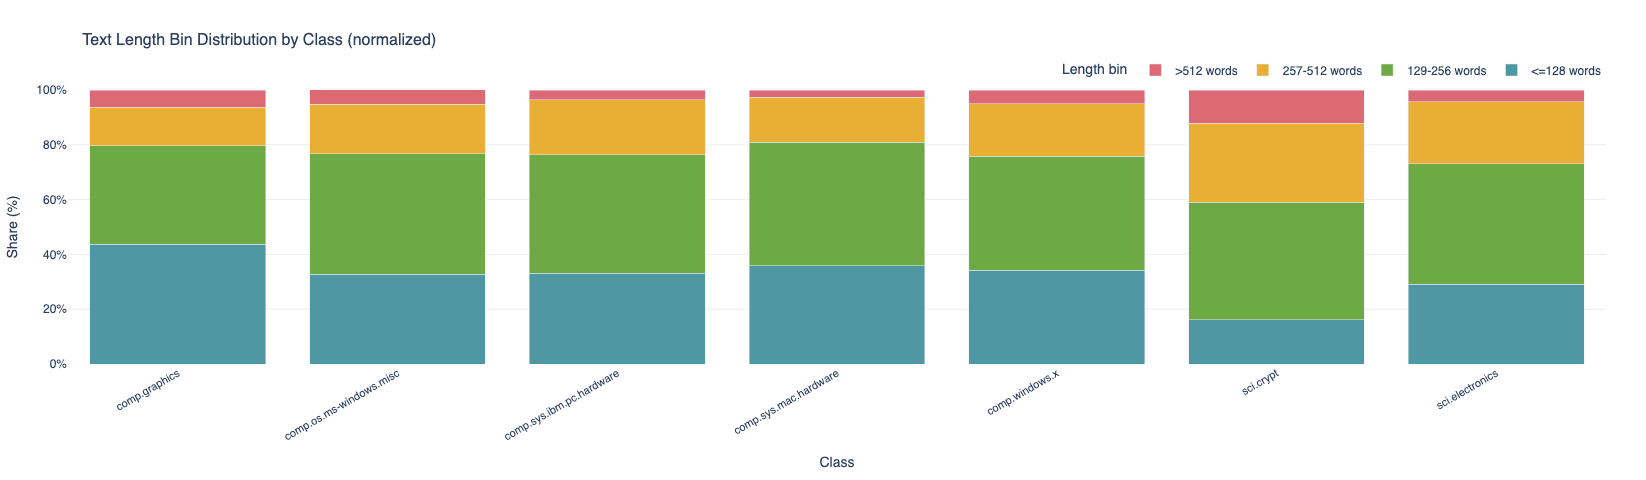

In [21]:
# visual
bin_order = ["<=128 words", "129-256 words", "257-512 words", ">512 words"]
colors = ["#4f98a3", "#6daa45", "#e8af34", "#dd6974"]

fig = go.Figure()

for i, bin_name in enumerate(bin_order):
    fig.add_trace(go.Bar(
        name=bin_name,
        x=length_by_class_bins.index,
        y=length_by_class_bins[bin_name] * 100,
        marker_color=colors[i],
        hovertemplate="<b>%{x}</b><br>" + bin_name + ": %{y:.1f}%<extra></extra>"
    ))

fig.update_layout(
    barmode="stack",
    title=dict(text="Text Length Bin Distribution by Class (normalized)", font=dict(size=16)),
    xaxis=dict(title="Class", tickangle=-30, tickfont=dict(size=11)),
    yaxis=dict(title="Share (%)", ticksuffix="%", range=[0, 100]),
    legend=dict(title="Length bin", orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=480,
    margin=dict(l=60, r=40, t=90, b=100),
    font=dict(family="Inter, sans-serif", size=12),
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor="#eee")

fig.show()

The length-bin analysis provides an early estimate of transformer truncation risk. Around 77.7% of posts are <=256 words (I keep in mind that word != tokens), so most documents are probably manageable for a 512-token transformer input. However, 17.1% are in a possible truncation-risk zone, and 5.2% are clearly long enough to require explicit handling.  

This does not mean long posts should be removed automatically. Some long posts may contain useful topic information, while others may be long because they include quoted threads, signatures, copied documentation, or other artifacts. The next EDA stage will therefore audit metadata and quoted-text patterns.

Also, truncation interacts with metadata.

If the raw document begins with:

`From`:
`Subject`:
`Organization`:
etc - 

then the transformer can spend the first tokens on metadata.

### Special document types and non-linguistic payloads

Here I check for a few special document types that may affect later modelling and error analysis.

The goal is to identify:

1. **Encoded binary payloads** embedded in text posts, such as uuencoded attachments. These are not meaningful natural-language topic content and may distort length, vocabulary, and similarity diagnostics.
2. **FAQ, digest, or multipart reference posts**, which are valid corpus documents but may behave differently from ordinary discussion replies because they are longer, more structured, and sometimes periodically reposted.
3. **Obvious language or encoding anomalies**, as a lightweight sanity check. Since this is an English-language Usenet dataset, language variation is not expected to be a major factor, but unusual cases should still be visible for later error analysis.

In [22]:
def extract_top_header_block(text):
    """
    Extract top-level header lines from the beginning of a raw Usenet post.
    The block ends at the first blank line.
    """
    if pd.isna(text):
        return []

    lines = str(text).splitlines()
    header_lines = []

    for line in lines:
        if line.strip() == "":
            break
        header_lines.append(line)

    return header_lines


def parse_top_headers(text):
    """
    Parse top-level headers into a dictionary with lowercase header names.
    Handles simple folded continuation lines.
    """
    header_lines = extract_top_header_block(text)

    headers = {}
    current_key = None

    for line in header_lines:
        match = re.match(r"^([A-Za-z][A-Za-z0-9\-]*)\s*:\s*(.*)$", line)

        if match:
            key = match.group(1).lower()
            value = match.group(2).strip()

            if key in headers:
                headers[key] = headers[key] + " " + value
            else:
                headers[key] = value

            current_key = key

        elif current_key is not None and line.startswith((" ", "\t")):
            headers[current_key] = headers[current_key] + " " + line.strip()

    return headers

In [23]:
parsed_top_headers = df_eda["text"].apply(parse_top_headers)

df_eda["subject_raw"] = parsed_top_headers.apply(lambda h: h.get("subject", ""))

In [24]:
# encoded payload / uuencoded blocks
UUENCODE_BEGIN_PATTERN = re.compile(r"(?im)^begin\s+[0-7]{3}\s+\S+")
UUENCODE_END_PATTERN   = re.compile(r"(?im)^end\s*$")


UUENCODE_DATA_LINE_PATTERN = re.compile(r"(?m)^M[!-`]{50,}$")


def has_uuencoded_block(text):
    """
    Detect uuencoded content — either a classic 'begin NNN filename' block,
    or raw uuencoded data lines (continuation parts without a 'begin' marker).
    """
    if pd.isna(text):
        return False
    t = str(text)
    return bool(UUENCODE_BEGIN_PATTERN.search(t)) or bool(UUENCODE_DATA_LINE_PATTERN.search(t))


def count_uuencoded_block_lines(text):
    """
    Count lines inside uuencoded blocks from 'begin ...' to 'end'.
    If the block is malformed and no 'end' is found, count until the end of text.
    """
    if pd.isna(text):
        return 0

    lines = str(text).splitlines()
    inside_block = False
    count = 0

    for line in lines:
        if UUENCODE_BEGIN_PATTERN.match(line):
            inside_block = True
            count += 1
            continue

        if inside_block:
            count += 1
            if UUENCODE_END_PATTERN.match(line):
                inside_block = False

    return count

In [25]:
df_eda["has_uuencoded_payload"] = df_eda["text"].apply(has_uuencoded_block)
df_eda["uuencoded_line_count"] = df_eda["text"].apply(count_uuencoded_block_lines)

if "line_count" not in df_eda.columns:
    df_eda["line_count"] = df_eda["text"].fillna("").str.splitlines().str.len()

df_eda["uuencoded_line_ratio"] = (
    df_eda["uuencoded_line_count"] /
    df_eda["line_count"].replace(0, np.nan)
).fillna(0)

print("Documents with uuencoded payloads:", df_eda["has_uuencoded_payload"].sum())

Documents with uuencoded payloads: 26


In [26]:
# FAQ / digest / multipart detection

def header_present(headers, key):
    return key.lower() in headers and str(headers.get(key.lower(), "")).strip() != ""

# Header-level signals
df_eda["has_archive_name_header"]  = parsed_top_headers.apply(lambda h: header_present(h, "archive-name"))
df_eda["has_last_modified_header"] = parsed_top_headers.apply(lambda h: header_present(h, "last-modified"))
df_eda["has_approved_header"]      = parsed_top_headers.apply(lambda h: header_present(h, "approved"))
df_eda["has_followup_to_poster"]   = parsed_top_headers.apply(
    lambda h: str(h.get("followup-to", "")).strip().lower() == "poster"
)

# Subject-level signals
subject_lower = df_eda["subject_raw"].fillna("").str.lower()

df_eda["subject_mentions_faq"]            = subject_lower.str.contains(r"\bfaq\b|frequently asked", regex=True, na=False)
df_eda["subject_mentions_digest_periodic"] = subject_lower.str.contains(
    r"\bdigest\b|\bweekly\b|\bmonthly\b|\bbiweekly\b|\bperiodic(?:al)?\b", regex=True, na=False
)
df_eda["subject_has_part_pattern"] = subject_lower.str.contains(
    r"\bpart\s*\d+\s*(?:(?:/|of)\s*\d+\b|\[\s*\d+\s*/\s*\d+\s*\])",
    regex=True, na=False)

# Body-level signals (FAQ headers sometimes appear inside the body too)
df_eda["has_archive_name_anywhere"]  = df_eda["text"].str.contains(r"(?im)^archive-name\s*:", regex=True, na=False)
df_eda["has_last_modified_anywhere"] = df_eda["text"].str.contains(r"(?im)^last-modified\s*:", regex=True, na=False)

# Composite flags 

# Multi-part series: strong signal from subject alone, no extra conditions needed
df_eda["is_multipart_series"] = df_eda["subject_has_part_pattern"]

# FAQ / digest: require at least one strong structural marker
df_eda["has_faq_digest_signal"] = (
    df_eda["has_archive_name_header"]
    | df_eda["has_archive_name_anywhere"]
    | df_eda["subject_mentions_faq"]
    | df_eda["subject_mentions_digest_periodic"]
    | (
        df_eda["has_approved_header"]
        & (
            df_eda["has_last_modified_header"]
            | df_eda["has_last_modified_anywhere"]
            | df_eda["has_followup_to_poster"]
        )
    )
)

print(f"FAQ/digest-like signal:  {df_eda['has_faq_digest_signal'].sum()}")
print(f"Multi-part series:       {df_eda['is_multipart_series'].sum()}")

FAQ/digest-like signal:  73
Multi-part series:       11


### Lightweight language / encoding sanity check

In [27]:


ENGLISH_STOPWORDS = set(ENGLISH_STOP_WORDS)


def basic_text_quality_features(text):
    """
    Lightweight text-quality and language sanity features.

    This is not a full language detector. It is used to flag obvious encoding-heavy
    or unusual documents for later review.
    """
    if pd.isna(text):
        text = ""

    text = str(text)
    chars = len(text)

    if chars == 0:
        return {
            "non_ascii_char_ratio": 0.0,
            "alphabetic_char_ratio": 0.0,
            "english_stopword_token_ratio": 0.0,
        }

    non_ascii = sum(1 for ch in text if ord(ch) > 127)
    alphabetic = sum(1 for ch in text if ch.isalpha())

    tokens = re.findall(r"\b[a-zA-Z]{2,}\b", text.lower())

    if len(tokens) == 0:
        stopword_ratio = 0.0
    else:
        stopword_ratio = sum(tok in ENGLISH_STOPWORDS for tok in tokens) / len(tokens)

    return {
        "non_ascii_char_ratio": non_ascii / chars,
        "alphabetic_char_ratio": alphabetic / chars,
        "english_stopword_token_ratio": stopword_ratio,
    }

In [28]:
text_quality_features = df_eda["text"].apply(basic_text_quality_features).apply(pd.Series)

df_eda = pd.concat([df_eda, text_quality_features], axis=1)

df_eda["language_or_encoding_review_flag"] = (
    (df_eda["non_ascii_char_ratio"] > 0.05)
    | (
        (df_eda["english_stopword_token_ratio"] < 0.03)
        & (df_eda["alphabetic_char_ratio"] < 0.50)
        & (df_eda["line_count"] > 20)
    )
)

print("Documents flagged for language/encoding review:", df_eda["language_or_encoding_review_flag"].sum())

Documents flagged for language/encoding review: 16


In [29]:
flagged = df_eda[df_eda["language_or_encoding_review_flag"]]
print(f"Of them with uuencoded: {flagged['has_uuencoded_payload'].sum()}")
print(f"Of them with FAQ/digest: {flagged['has_faq_digest_signal'].sum()}")
print(f"Neither of these: {(~flagged['has_uuencoded_payload'] & ~flagged['has_faq_digest_signal']).sum()}")

# see examples of "neither one nor the other"
unknown = flagged[~flagged["has_uuencoded_payload"] & ~flagged["has_faq_digest_signal"]]
for _, row in unknown.head(15).iterrows(): 
    print(f"\n--- {row['label']} ---") 
    print(row["text"][:900])

Of them with uuencoded: 15
Of them with FAQ/digest: 0
Neither of these: 1

--- comp.sys.mac.hardware ---
Newsgroups: comp.sys.mac.hardware
Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!bb3.andrew.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!sdd.hp.com!col.hp.com!fc.hp.com!rodc
From: rodc@fc.hp.com (Rod Cerkoney)
Subject: *$G4qxF,fekVH6
Sender: news@fc.hp.com (news daemon)
Message-ID: <C5L5ux.6sL@fc.hp.com>
Date: Fri, 16 Apr 1993 16:59:21 GMT
Nntp-Posting-Host: hpfcmrc.fc.hp.com
Organization: Hewlett Packard, Fort Collins, CO
X-Newsreader: TIN [version 1.1 PL8.5]
Lines: 15



--


Regards,
Rod Cerkoney
                                                        /\
______________________________________________         /~~\
                                                      /    \
  Rod Cerkoney MS 37     email:                      /      \ 
  Hewlett Packard         rodc@fc.hp.com        /\  /        \  
  3404 East Harmony Rd.  Hpdesk:               

#### Special document type findings

The special document type audit identifies three rare but relevant document conditions: encoded payloads, FAQ/digest-style posts, and language or encoding review cases.

A small number of documents contain encoded payloads embedded in the raw text. After expanding the detector beyond classic `begin ...` uuencoded blocks to include uuencoded-like data lines, 26 documents are flagged, representing 0.37% of the dataset. These payloads are not meaningful natural-language topic content. They can distort document length, vocabulary statistics, cosine-similarity diagnostics, and sparse lexical features. The documents are retained, but the encoded-payload flag is carried forward for later error analysis.

The encoded-payload cases are rare but not evenly distributed across classes. Most occur in `comp.os.ms-windows.misc`, which suggests that this artifact type may be related to software/file-sharing posts rather than random noise. Because the count is small, it is not treated as a main evaluation slice, but it may help explain individual outliers or unusual model errors.

The audit also flags 73 FAQ/digest-like documents, or 1.05% of the dataset. These include posts with signals such as `Archive-name`, FAQ/digest wording, periodic-posting indicators, or multipart-series patterns. These documents are valid parts of the corpus, but they differ from ordinary discussion replies: they are often longer, more structured, and sometimes periodically reposted. They are therefore retained but flagged as a special document type.

The lightweight language/encoding sanity check flags 16 documents, or 0.23% of the dataset. Manual overlap checks show that 15 of these are also encoded-payload documents, and the remaining case is an ASCII-art signature rather than a clear non-English document. Therefore, this audit does not indicate meaningful multilingual variation in the dataset. Instead, the language-review flag mainly serves as an additional encoding/artifact sanity check.

Overall, these findings do not change the main task setup. The special document types are too rare to require filtering or a separate modelling regime. However, the flags are useful for later error analysis, especially if unusually long documents, high-similarity pairs, or high-confidence errors involve encoded payloads or FAQ/digest-style posts.

In [30]:
special_document_summary = pd.DataFrame([
    {
        "feature": "has_uuencoded_payload",
        "count": int(df_eda["has_uuencoded_payload"].sum()),
        "share": df_eda["has_uuencoded_payload"].mean(),
        "interpretation": "Documents containing classic uuencoded payload blocks.",
    },
    {
        "feature": "has_faq_digest_signal",
        "count": int(df_eda["has_faq_digest_signal"].sum()),
        "share": df_eda["has_faq_digest_signal"].mean(),
        "interpretation": "Documents with FAQ, digest, periodic, or multipart-reference signals.",
    },
    {
        "feature": "language_or_encoding_review_flag",
        "count": int(df_eda["language_or_encoding_review_flag"].sum()),
        "share": df_eda["language_or_encoding_review_flag"].mean(),
        "interpretation": "Documents with unusual character/stopword patterns for manual review.",
    },
])

display(special_document_summary.style.format({"share": "{:.2%}"}))

,feature,count,share,interpretation
0,has_uuencoded_payload,26,0.37%,Documents containing classic uuencoded payload blocks.
1,has_faq_digest_signal,73,1.05%,"Documents with FAQ, digest, periodic, or multipart-reference signals."
2,language_or_encoding_review_flag,16,0.23%,Documents with unusual character/stopword patterns for manual review.


In [31]:
special_document_by_class = (
    df_eda
    .groupby("label")
    .agg(
        n_docs=("text", "size"),
        uuencoded_payload_count=("has_uuencoded_payload", "sum"),
        faq_digest_signal_count=("has_faq_digest_signal", "sum"),
        language_review_count=("language_or_encoding_review_flag", "sum"),
        mean_uuencoded_line_ratio=("uuencoded_line_ratio", "mean"),
    )
    .reset_index()
)

display(
    special_document_by_class.style.format({
        "uuencoded_payload_count": "{:.0f}",
        "faq_digest_signal_count": "{:.0f}",
        "language_review_count": "{:.0f}",
        "mean_uuencoded_line_ratio": "{:.3f}",
    })
)

,label,n_docs,uuencoded_payload_count,faq_digest_signal_count,language_review_count,mean_uuencoded_line_ratio
0,comp.graphics,985,0,14,0,0.000
1,comp.os.ms-windows.misc,989,20,2,15,0.005
2,comp.sys.ibm.pc.hardware,984,1,8,0,0.000
3,comp.sys.mac.hardware,992,1,2,1,0.001
4,comp.windows.x,992,2,27,0,0.001
5,sci.crypt,1000,1,17,0,0.001
6,sci.electronics,995,1,3,0,0.000


In [32]:
# cols to care

special_document_cols = [
    "has_uuencoded_payload",
    "uuencoded_line_count",
    "uuencoded_line_ratio",
    "has_faq_digest_signal",
    "has_archive_name_header",
    "has_last_modified_header",
    "has_approved_header",
    "has_followup_to_poster",
    "subject_mentions_faq",
    "subject_mentions_digest_or_periodic",
    "subject_has_part_pattern",
    "language_or_encoding_review_flag",
    "non_ascii_char_ratio",
    "alphabetic_char_ratio",
    "english_stopword_token_ratio",
]

special_document_cols = [col for col in special_document_cols if col in df_eda.columns]

special_document_cols

['has_uuencoded_payload',
 'uuencoded_line_count',
 'uuencoded_line_ratio',
 'has_faq_digest_signal',
 'has_archive_name_header',
 'has_last_modified_header',
 'has_approved_header',
 'has_followup_to_poster',
 'subject_mentions_faq',
 'subject_has_part_pattern',
 'language_or_encoding_review_flag',
 'non_ascii_char_ratio',
 'alphabetic_char_ratio',
 'english_stopword_token_ratio']

### Raw-text similarity check: near-duplicates or metadata artifacts?
quick validity check:

exact duplicates are absent, but repeated FAQ/monthly postings suggest near-duplicate or template-like content may exist.

In [33]:
# quick near-duplicate / repeated-template check using TF-IDF similarity

near_dup_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=2,
    max_df=0.95,
    max_features=50000
)

X_near_dup = near_dup_vectorizer.fit_transform(df_eda["text"])

nn = NearestNeighbors(
    n_neighbors=3,
    metric="cosine",
    algorithm="brute"
)

nn.fit(X_near_dup)

distances, indices = nn.kneighbors(X_near_dup)

pairs = []

for i in range(len(df_eda)):
    for rank in range(1, 3): # index 0 is document itself
        j = indices[i, rank]
        similarity = 1 - distances[i, rank]

        if i < j:
            pairs.append({
                "idx_1": i,
                "idx_2": j,
                "similarity": similarity,
                "label_1": df_eda.iloc[i]["label"],
                "label_2": df_eda.iloc[j]["label"],
                "words_1": df_eda.iloc[i]["word_count"],
                "words_2": df_eda.iloc[j]["word_count"],
                "preview_1": df_eda.iloc[i]["text"].replace("\n", " ")[:300],
                "preview_2": df_eda.iloc[j]["text"].replace("\n", " ")[:300],
            })

near_pairs = (
    pd.DataFrame(pairs)
    .sort_values("similarity", ascending=False)
    .reset_index(drop=True)
)

display(near_pairs.head(20))

,idx_1,idx_2,similarity,label_1,label_2,words_1,words_2,preview_1,preview_2
0,1030,6565,0.999814,comp.os.ms-windows.misc,comp.os.ms-windows.misc,1000,1000,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...
1,1030,5697,0.999700,comp.os.ms-windows.misc,comp.os.ms-windows.misc,1000,1000,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....
2,4363,4673,0.999642,comp.graphics,comp.graphics,8254,8260,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
3,5697,6565,0.999578,comp.os.ms-windows.misc,comp.os.ms-windows.misc,1000,1000,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...
4,23,5170,0.999577,comp.graphics,comp.graphics,9287,9257,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
5,6478,6565,0.999342,comp.os.ms-windows.misc,comp.os.ms-windows.misc,1000,1000,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...
6,1787,5170,0.999213,comp.graphics,comp.graphics,9200,9257,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
7,23,1787,0.999107,comp.graphics,comp.graphics,9287,9200,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...,Xref: cantaloupe.srv.cs.cmu.edu comp.graphics:...
8,3482,5494,0.999033,comp.windows.x,comp.windows.x,3434,3435,Xref: cantaloupe.srv.cs.cmu.edu comp.windows.x...,Xref: cantaloupe.srv.cs.cmu.edu comp.windows.x...
9,4692,5697,0.999009,comp.os.ms-windows.misc,comp.os.ms-windows.misc,493,1000,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....,Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv....


In [34]:
# inspect a few highly similar raw-text pairs.
# this is exploratory only: high raw similarity does not prove true duplication.

for _, row in near_pairs.head(3).iterrows():
    i, j = row["idx_1"], row["idx_2"]

    print("=" * 120)
    print(f"Pair: {i} ↔ {j} | similarity={row['similarity']:.4f}")
    print(f"Labels: {row['label_1']} ↔ {row['label_2']}")
    print(f"Words: {row['words_1']} ↔ {row['words_2']}")
    print("-" * 120)
    print("DOC 1:")
    print(preview_document_structure(df_eda.loc[i, "text"], n_head=18, n_tail=0))
    print("-" * 120)
    print("DOC 2:")
    print(preview_document_structure(df_eda.loc[j, "text"], n_head=18, n_tail=0))
    print("\n")

Pair: 1030 ↔ 6565 | similarity=0.9998
Labels: comp.os.ms-windows.misc ↔ comp.os.ms-windows.misc
Words: 1000 ↔ 1000
------------------------------------------------------------------------------------------------------------------------
DOC 1:
001: Path: cantaloupe.srv.cs.cmu.edu!crabapple.srv.cs.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!emory!sol.ctr.columbia.edu!destroyer!newsrelay.iastate.edu!iscsvax.uni.edu!sunfish!pw...
002: Newsgroups: comp.os.ms-windows.misc
003: Subject: roman.bmp 12/14 
004: Message-ID: <C65Gv3.1uz@sunfish.usd.edu>
005: From: pwiseman@salmon.usd.edu (Cliff)
006: Date: Tue, 27 Apr 1993 16:09:01 GMT
007: Reply-To: pwiseman@salmon.usd.edu (Cliff)
008: Sender: pwiseman@sunfish.usd.edu (Cliff)
009: Distribution: usa
010: Organization: University of South Dakota
011: Lines: 956
012: 
013: 
014: ------------ Part 12 of 14 ------------
015: MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'
016: MAX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX>'AX

A lightweight TF-IDF nearest-neighbor check on the raw texts to see whether the dataset contains repeated or highly templated documents shows that top similar pairs have 1 cosine similarity. But at this stage I can not see if the reason is quotas or metadata - this initial observation suggests a more reliable near-duplicate audit that would compare raw-text similarity with cleaned/body-text similarity. If a pair is highly similar in raw text but not after metadata removal, the similarity is likely artifact-driven. If it remains highly similar after cleaning, it may indicate a true repeated template, FAQ version, or near-duplicate document.

### Initial dataset overview findings and implications

The dataset contains 6,866 posts across seven technical categories with no missing values or exact duplicates. The class distribution is highly balanced (imbalance ratio 1.029), supporting stratified splits and macro F1 as the primary metric.

Raw posts preserve newsgroup-style structure: ordinary-length documents commonly include metadata fields (From, Subject, Organization, Lines, NNTP-Posting-Host), quoted replies, signatures, and technical references. Category boundaries are meaningful but not perfectly clean — topic overlap between adjacent categories (e.g. comp.graphics and comp.os.ms-windows.misc) is expected and may produce genuine model errors.

The main structural issue is length skew. The median is 154 words, the mean is 243, and the longest document is 11,821 words. Manual inspection confirms that outliers are FAQ or monthly-reference posts with repeated templates rather than ordinary replies. 77.7% of posts are ≤256 words; 5.2% exceed 512. Because tokenizers split technical strings into subwords, whitespace word counts underestimate transformer truncation risk — and this risk appears class-dependent, with sci.crypt containing a larger share of long documents.

A preliminary TF-IDF nearest-neighbor check found several pairs with cosine similarity ≥0.999, including subscription posts and closely repeated messages. Since the check was performed on raw text, high similarity may reflect metadata or same-author patterns rather than substantive duplication. Near-duplicate risk will be revisited after preprocessing.

These findings lead to five decisions:

1. Use macro F1 as primary metric.

2. Treat document length as a validity factor when comparing classical and transformer models.

3. Audit raw-text artifacts next.

4. Compare preprocessing regimes rather than assuming raw text is optimal.

5. Revisit near-duplicate risk after cleaning.

## <a id="raw-text-artifact-audit"></a>Raw text artifact audit

Manual inspection showed that both ordinary posts and length outliers preserve raw newsgroup-style structure. This includes metadata fields, quoted replies, signatures, email addresses, technical paths, and repeated formatting.

This section quantifies these artifacts across the full dataset. The goal is to understand which non-content or semi-structured elements are common enough to affect feature representations and model evaluation.

In [35]:
# helper functions for raw-text artifact detection

def regex_count(text, pattern, flags=0):
    """Count regex matches in a text string."""
    if pd.isna(text):
        return 0
    return len(re.findall(pattern, text, flags=flags))


def has_header_field(text, field_name):
    """Check whether a specific newsgroup-style header field appears in the text."""
    pattern = rf"^\s*{re.escape(field_name)}\s*:"
    return bool(re.search(pattern, text, flags=re.IGNORECASE | re.MULTILINE))

# this detects header-like lines anywhere in the raw text, including quoted or embedded material
def count_header_fields(text, fields):
    """Count how many selected header fields are present."""
    return sum(has_header_field(text, field) for field in fields)


def count_quote_lines(text):
    """Count lines that look like quoted replies using a conservative '>' marker."""
    if pd.isna(text):
        return 0
    return sum(1 for line in text.splitlines() if re.match(r"^\s*>", line))


def count_hash_quote_lines(text):
    """Count lines that may be quoted with # markers, common in some mailing-list style posts."""
    if pd.isna(text):
        return 0
    return sum(1 for line in text.splitlines() if re.match(r"^\s*#", line))


def count_separator_lines(text):
    """Count long separator-like lines made of repeated punctuation."""
    if pd.isna(text):
        return 0
    return sum(
        1 for line in text.splitlines()
        if re.match(r"^\s*[-=*_\|]{6,}\s*$", line))

In [36]:
# header groups
# these categories are analytical, not final preprocessing decisions.

label_leakage_headers = [
    "Newsgroups",
]

source_identity_headers = [
    "From",
    "Sender",
    "Reply-To",
    "Organization",
    "Originator",
    "To",
]

routing_threading_headers = [
    "Path",
    "Message-ID",
    "References",
    "In-Reply-To",
    "Xref",
    "NNTP-Posting-Host",
]

content_adjacent_headers = [
    "Subject",
    "Keywords",
    "Summary",
]

administrative_headers = [
    "Lines",
    "Date",
    "Expires",
    "Supersedes",
    "Archive-name",
    "Version",
    "Distribution",
    "X-Newsreader",
]

In [37]:
# create raw-text artifact features
df_artifacts = df_eda.copy()

# email-like strings
df_artifacts["email_count"] = df_artifacts["text"].apply(
    lambda x: regex_count(x, r"\b[\w\.\-]+@[\w\.\-]+\.[\w\-]+\b")
)
df_artifacts["has_email"] = df_artifacts["email_count"] > 0

# URLs / FTP-like references
df_artifacts["url_count"] = df_artifacts["text"].apply(
    lambda x: regex_count(x, r"https?://\S+|www\.\S+|\bftp\.[\w\.\-]+\b", flags=re.IGNORECASE)
)
df_artifacts["has_url_or_ftp"] = df_artifacts["url_count"] > 0

# unix-like or file-system-like paths
df_artifacts["path_like_count"] = df_artifacts["text"].apply(
    lambda x: regex_count(x, r"(?<!\w)/(?:[\w\.\-]+/)+[\w\.\-]*")
)
df_artifacts["has_path_like"] = df_artifacts["path_like_count"] > 0

# header groups — 4 analytical categories
df_artifacts["label_leakage_header_count"] = df_artifacts["text"].apply(
    lambda x: count_header_fields(x, label_leakage_headers)
)
df_artifacts["has_label_leakage_header"] = df_artifacts["label_leakage_header_count"] > 0

df_artifacts["source_identity_header_count"] = df_artifacts["text"].apply(
    lambda x: count_header_fields(x, source_identity_headers)
)
df_artifacts["has_source_identity_header"] = df_artifacts["source_identity_header_count"] > 0

df_artifacts["routing_threading_header_count"] = df_artifacts["text"].apply(
    lambda x: count_header_fields(x, routing_threading_headers)
)
df_artifacts["has_routing_threading_header"] = df_artifacts["routing_threading_header_count"] > 0

df_artifacts["content_adjacent_header_count"] = df_artifacts["text"].apply(
    lambda x: count_header_fields(x, content_adjacent_headers)
)
df_artifacts["has_content_adjacent_header"] = df_artifacts["content_adjacent_header_count"] > 0

df_artifacts["administrative_header_count"] = df_artifacts["text"].apply(
    lambda x: count_header_fields(x, administrative_headers)
)
df_artifacts["has_administrative_header"] = df_artifacts["administrative_header_count"] > 0

# quoted replies and formatting
df_artifacts["quote_line_count"] = df_artifacts["text"].apply(count_quote_lines)
df_artifacts["hash_quote_line_count"] = df_artifacts["text"].apply(count_hash_quote_lines)
df_artifacts["separator_line_count"] = df_artifacts["text"].apply(count_separator_lines)

df_artifacts["has_quote_lines"] = df_artifacts["quote_line_count"] > 0
df_artifacts["has_hash_quote_lines"] = df_artifacts["hash_quote_line_count"] > 0
df_artifacts["has_separator_lines"] = df_artifacts["separator_line_count"] > 0

# signature marker
df_artifacts["signature_marker_count"] = df_artifacts["text"].apply(
    lambda x: regex_count(x, r"(?m)^--\s*$")
)
df_artifacts["has_signature_marker"] = df_artifacts["signature_marker_count"] > 0

# ratios
df_artifacts["quote_line_ratio"] = (
    df_artifacts["quote_line_count"] / df_artifacts["line_count"].replace(0, np.nan)
).fillna(0)

df_artifacts["structural_line_count"] = (
    df_artifacts["quote_line_count"]
    + df_artifacts["hash_quote_line_count"]
    + df_artifacts["separator_line_count"]
    + df_artifacts["signature_marker_count"]
)

df_artifacts["structural_line_ratio"] = (
    df_artifacts["structural_line_count"] / df_artifacts["line_count"].replace(0, np.nan)
).fillna(0)



df_artifacts.head()

,text,label_id,label,filename,message_id,char_count,word_count,line_count,subject_raw,has_uuencoded_payload,...,hash_quote_line_count,separator_line_count,has_quote_lines,has_hash_quote_lines,has_separator_lines,signature_marker_count,has_signature_marker,quote_line_ratio,structural_line_count,structural_line_ratio
0,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1573...,5,sci.crypt,15738,<1993Apr21.184113.3505@nmt.edu>,3706,543,63,public awareness (wasRe: text of White House a...,False,...,0,0,True,False,False,0,False,0.492063,31,0.492063
1,Newsgroups: comp.sys.ibm.pc.hardware\nPath: ca...,2,comp.sys.ibm.pc.hardware,60553,<1993Apr19.185511.2072@icd.teradyne.com>,2480,352,51,Re: Recommendations for a Local BUS (Cache,False,...,0,0,True,False,False,0,False,0.372549,19,0.372549
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,2,comp.sys.ibm.pc.hardware,58989,<1pstlnINN4r5@srvr1.engin.umich.edu>,1131,142,30,Floppy file copying,False,...,0,0,False,False,False,0,False,0.000000,0,0.000000
3,Newsgroups: comp.graphics\nPath: cantaloupe.sr...,0,comp.graphics,38932,<1993Apr28.181756.15458@kpc.com>,2115,210,48,Re: Kubota Kenai/Denali specs,False,...,0,1,True,False,True,0,False,0.333333,17,0.354167
4,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,4,comp.windows.x,67032,<1qv9bo$frb@menudo.uh.edu>,469,42,13,"Ask the ftp address of ""Kerberos Version 5 dra...",False,...,0,0,False,False,False,0,False,0.000000,0,0.000000


In [38]:
# overall artifact prevalence

artifact_presence_cols = [
    "has_email",
    "has_url_or_ftp",
    "has_path_like",
    "has_label_leakage_header",      
    "has_source_identity_header",      
    "has_routing_threading_header",    
    "has_content_adjacent_header",
    "has_administrative_header",
    "has_quote_lines",
    "has_hash_quote_lines",
    "has_signature_marker",
    "has_separator_lines",
]

artifact_overall = []

for col in artifact_presence_cols:
    artifact_overall.append({
        "artifact_feature": col,
        "share_of_posts": df_artifacts[col].mean(),
        "count": df_artifacts[col].sum()
    })

artifact_overall = pd.DataFrame(artifact_overall).sort_values("share_of_posts", ascending=False)

display(
    artifact_overall.style.format({
        "share_of_posts": "{:.1%}",
        "count": "{:,.0f}"
    })
)

,artifact_feature,share_of_posts,count
3,has_label_leakage_header,100.0%,"6,937"
4,has_source_identity_header,100.0%,"6,937"
5,has_routing_threading_header,100.0%,"6,937"
6,has_content_adjacent_header,100.0%,"6,937"
7,has_administrative_header,100.0%,"6,937"
0,has_email,100.0%,"6,936"
8,has_quote_lines,40.7%,"2,820"
10,has_signature_marker,37.8%,"2,619"
11,has_separator_lines,16.2%,"1,122"
2,has_path_like,4.5%,311


In [39]:
# artifact prevalence by class

artifact_by_class = (
    df_artifacts
    .groupby("label")[artifact_presence_cols]
    .mean()
    .sort_index()
)

artifact_by_class.style.format("{:.1%}")

,has_email,has_url_or_ftp,has_path_like,has_label_leakage_header,has_source_identity_header,has_routing_threading_header,has_content_adjacent_header,has_administrative_header,has_quote_lines,has_hash_quote_lines,has_signature_marker,has_separator_lines
label,,,,,,,,,,,,
comp.graphics,100.0%,2.0%,5.8%,100.0%,100.0%,100.0%,100.0%,100.0%,29.3%,1.4%,35.2%,17.6%
comp.os.ms-windows.misc,100.0%,4.9%,4.1%,100.0%,100.0%,100.0%,100.0%,100.0%,44.8%,1.1%,38.3%,19.5%
comp.sys.ibm.pc.hardware,100.0%,0.9%,1.8%,100.0%,100.0%,100.0%,100.0%,100.0%,32.8%,1.0%,35.9%,17.5%
comp.sys.mac.hardware,100.0%,0.6%,1.8%,100.0%,100.0%,100.0%,100.0%,100.0%,40.9%,0.9%,29.0%,15.2%
comp.windows.x,99.9%,2.5%,11.9%,100.0%,100.0%,100.0%,100.0%,100.0%,25.1%,6.4%,44.5%,21.0%
sci.crypt,100.0%,1.1%,4.7%,100.0%,100.0%,100.0%,100.0%,100.0%,63.9%,3.1%,48.6%,8.5%
sci.electronics,100.0%,0.1%,1.2%,100.0%,100.0%,100.0%,100.0%,100.0%,47.3%,1.4%,32.7%,14.1%


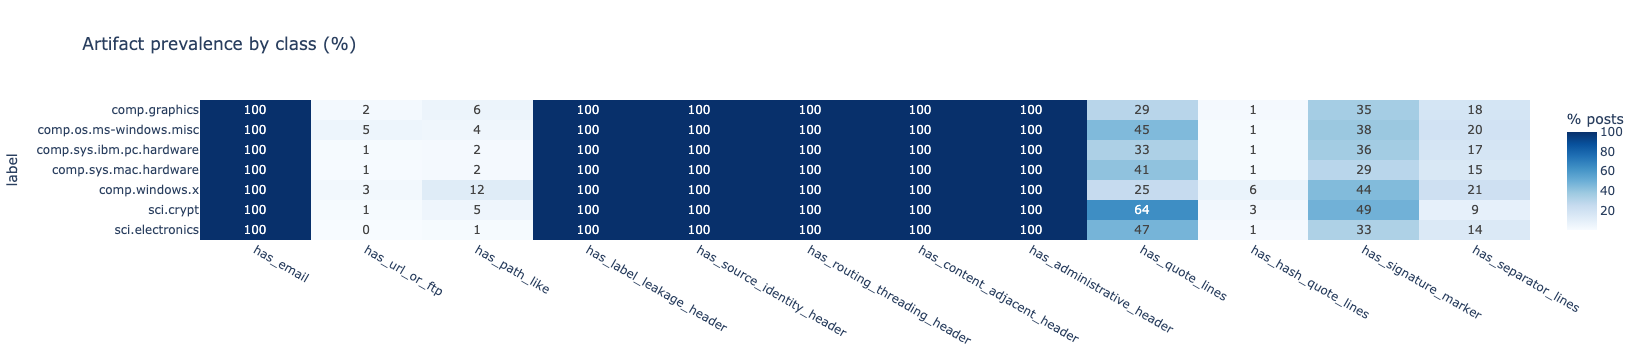

In [40]:
fig = px.imshow(
    artifact_by_class * 100,
    text_auto=".0f",
    color_continuous_scale="Blues",
    labels=dict(color="% posts"),
    title="Artifact prevalence by class (%)",
    aspect="auto"
)
fig.update_xaxes(tickangle=30)
fig.show()

In [41]:
# artifact intensity by class

artifact_intensity_cols = [
    "email_count",
    "url_count",
    "path_like_count",
    "label_leakage_header_count",        
    "source_identity_header_count",      
    "routing_threading_header_count",    
    "content_adjacent_header_count",
    "administrative_header_count",
    "quote_line_count",
    "quote_line_ratio",
    "hash_quote_line_count",
    "signature_marker_count",
    "separator_line_count",
    "structural_line_count",             
    "structural_line_ratio",
]

artifact_intensity_by_class = (
    df_artifacts
    .groupby("label")[artifact_intensity_cols]
    .agg(["mean", "median"])
)

artifact_intensity_by_class

email_count        url_count        path_like_count  \
                                mean median      mean median            mean   
label                                                                          
comp.graphics               5.592893    5.0  0.110660    0.0        0.326904   
comp.os.ms-windows.misc     5.646107    5.0  0.052578    0.0        0.438827   
comp.sys.ibm.pc.hardware    5.216463    4.0  0.017276    0.0        0.030488   
comp.sys.mac.hardware       5.112903    5.0  0.013105    0.0        0.025202   
comp.windows.x              5.764113    5.0  0.083669    0.0        0.700605   
sci.crypt                   7.086000    7.0  0.042000    0.0        0.146000   
sci.electronics             5.550754    5.0  0.001005    0.0        0.013065   

                                label_leakage_header_count         \
                         median                       mean median   
label                                                               
comp.graphics               0.0                        1.0    1.0   
comp.os.ms-windows.misc     0.0                        1.0    1.0   
comp.sys.ibm.pc.hardware    0.0                        1.0    1.0   
comp.sys.mac.hardware       0.0                        1.0    1.0   
comp.windows.x              0.0                        1.0    1.0   
sci.crypt                   0.0                        1.0    1.0   
sci.electronics             0.0                        1.0    1.0   

                         source_identity_header_count         ...  \
                                                 mean median  ...   
label                                                         ...   
comp.graphics                                2.669036    3.0  ...   
comp.os.ms-windows.misc                      2.666330    3.0  ...   
comp.sys.ibm.pc.hardware                     2.650407    3.0  ...   
comp.sys.mac.hardware                        2.662298    3.0  ...   
comp.windows.x                               2.933468    3.0  ...   
sci.crypt                                    2.633000    3.0  ...   
sci.electronics                              2.598995    3.0  ...   

                         hash_quote_line_count        signature_marker_count  \
                                          mean median                   mean   
label                                                                          
comp.graphics                         0.044670    0.0               0.385787   
comp.os.ms-windows.misc               0.028311    0.0               0.398382   
comp.sys.ibm.pc.hardware              0.030488    0.0               0.364837   
comp.sys.mac.hardware                 0.025202    0.0               0.292339   
comp.windows.x                        0.416331    0.0               0.454637   
sci.crypt                             0.137000    0.0               0.516000   
sci.electronics                       0.043216    0.0               0.331658   

                                separator_line_count         \
                         median                 mean median   
label                                                         
comp.graphics               0.0             0.761421    0.0   
comp.os.ms-windows.misc     0.0             0.408493    0.0   
comp.sys.ibm.pc.hardware    0.0             0.290650    0.0   
comp.sys.mac.hardware       0.0             0.263105    0.0   
comp.windows.x              0.0             0.644153    0.0   
sci.crypt                   0.0             0.258000    0.0   
sci.electronics             0.0             0.263317    0.0   

                         structural_line_count        structural_line_ratio  \
                                          mean median                  mean   
label                                                                         
comp.graphics                         3.832487    1.0              0.075764   
comp.os.ms-windows.misc               5.564206    2.0              0.127322   
comp.sys.ibm.pc

In [42]:
# inspect examples with high structural-line ratio

high_artifact_examples = (
    df_artifacts
    .sort_values("structural_line_ratio", ascending=False)
    [[
        "label",
        "word_count",
        "line_count",
        "quote_line_count",
        "hash_quote_line_count",
        "separator_line_count",
        "signature_marker_count",
        "structural_line_ratio",
        "text",
    ]]
    .head(5)
    .copy()
)

display(high_artifact_examples.drop(columns=["text"]))

,label,word_count,line_count,quote_line_count,hash_quote_line_count,separator_line_count,signature_marker_count,structural_line_ratio
2966,sci.electronics,612,84,63,0,2,1,0.785714
719,comp.sys.mac.hardware,526,71,53,0,0,0,0.746479
2480,sci.electronics,543,75,54,0,0,0,0.720000
1288,sci.crypt,499,67,46,0,0,0,0.686567
4459,sci.crypt,294,44,30,0,0,0,0.681818


In [43]:
for idx, row in high_artifact_examples.iterrows():
    print("=" * 120)
    print(
        f"Index: {idx} | Label: {row['label']} | "
        f"Words: {row['word_count']} | Lines: {row['line_count']} | "
        f"Structural ratio: {row['structural_line_ratio']:.2f}"
    )
    print("=" * 120)
    print(preview_document_structure(row["text"], n_head=35, n_tail=10))
    print("\n")

Index: 2966 | Label: sci.electronics | Words: 612 | Lines: 84 | Structural ratio: 0.79
001: Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!emory!sol.ctr.columbia.edu!destroyer!cs.ubc.ca!mala.bc.ca!wagner
002: From: wagner@mala.bc.ca (TOM WAGNER, Wizzard of old Audio/Visual Equipment........Nanaimo Campus)
003: Newsgroups: sci.electronics
004: Subject: correction of last followup re relays
005: Message-ID: <1993Apr20.103012.1710@mala.bc.ca>
006: Date: 20 Apr 93 10:30:12 -0700
007: References: <C5qsBF.IEK@ms.uky.edu> <C5r60r.4ID@megatest.com> <1993Apr20.102756.1709@mala.bc.ca>
008: Organization: Malaspina College
009: Lines: 73
010: 
011: In article <1993Apr20.102756.1709@mala.bc.ca>, wagner@mala.bc.ca (TOM WAGNER, Wizzard of old Audio/Visual Equipment........Nanaimo Campus) writes:
012: > In article <C5r60r.4ID@megatest.com>, alung@megatest.com (Aaron Lung) writes:
013: >> In article <C5qsBF.IEK@ms.uky.edu> billq@ms.uky.e

In [44]:
# check leakage label examples becaise I see "Newsgroups: comp.windows.x" which is label leakahe 
label_leakage_examples = (
    df_artifacts[df_artifacts["has_label_leakage_header"]]
    [["label", "word_count", "line_count", "text"]]
    .copy()
)

label_leakage_examples["preview"] = (
    label_leakage_examples["text"]
    .str.replace("\n", " ", regex=False)
    .str.slice(0, 500)
)

display(label_leakage_examples[["label", "word_count", "line_count", "preview"]].head(10))

,label,word_count,line_count,preview
0,sci.crypt,543,63,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1573...
1,comp.sys.ibm.pc.hardware,352,51,Newsgroups: comp.sys.ibm.pc.hardware Path: can...
2,comp.sys.ibm.pc.hardware,142,30,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...
3,comp.graphics,210,48,Newsgroups: comp.graphics Path: cantaloupe.srv...
4,comp.windows.x,42,13,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...
5,comp.sys.mac.hardware,160,33,Newsgroups: comp.sys.mac.hardware Path: cantal...
6,sci.crypt,697,78,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1560...
7,sci.crypt,97,23,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1604...
8,sci.crypt,255,45,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...
9,sci.electronics,135,37,Newsgroups: sci.electronics Path: cantaloupe.s...


In [45]:
for idx, row in label_leakage_examples.head(3).iterrows():
    print("=" * 120)
    print(f"Index: {idx} | Label: {row['label']} | Words: {row['word_count']} | Lines: {row['line_count']}")
    print("=" * 120)
    print(preview_document_structure(row["text"], n_head=25, n_tail=0))
    print("\n")

Index: 0 | Label: sci.crypt | Words: 543 | Lines: 63
001: Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:15738 alt.security:10080 comp.org.eff.talk:17114 comp.security.misc:3535 comp.org.acm:1694 comp.org.ieee:1623
002: Newsgroups: sci.crypt,alt.security,comp.org.eff.talk,comp.security.misc,comp.org.acm,comp.org.ieee
003: Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!howland.reston.ans.net!usc!sdd.hp.com!network.ucsd.edu!nmt.edu!msny...
004: From: msnyder@nmt.edu (Rebecca Snyder)
005: Subject: public awareness (wasRe: text of White House announcement and Q&As on clipper chip encryption)
006: Message-ID: <1993Apr21.184113.3505@nmt.edu>
007: Organization: New Mexico Tech
008: References: <1993Apr17.001805.11432@clarinet.com> <1qnpjuINN8ci@gap.caltech.edu> <2076@rwing.UUCP>
009: Distribution: na
010: Date: Wed, 21 Apr 1993 18:41:13 GMT
011: Lines: 50
012: 
013: In article <2076@rwing.UUCP> pat@rwing.UUCP (Pat Myrto) writes:
014

In [46]:
# artifact prevalence by class selected columns
selected_artifact_presence = [
    "has_email",
    "has_routing_threading_header",
    "has_quote_lines",
    "has_signature_marker",
    "has_separator_lines",
    "has_label_leakage_header",
]

artifact_by_class_selected = (
    df_artifacts
    .groupby("label")[selected_artifact_presence]
    .mean()
    .sort_index()
)

artifact_by_class_selected.style.format("{:.1%}")

,has_email,has_routing_threading_header,has_quote_lines,has_signature_marker,has_separator_lines,has_label_leakage_header
label,,,,,,
comp.graphics,100.0%,100.0%,29.3%,35.2%,17.6%,100.0%
comp.os.ms-windows.misc,100.0%,100.0%,44.8%,38.3%,19.5%,100.0%
comp.sys.ibm.pc.hardware,100.0%,100.0%,32.8%,35.9%,17.5%,100.0%
comp.sys.mac.hardware,100.0%,100.0%,40.9%,29.0%,15.2%,100.0%
comp.windows.x,99.9%,100.0%,25.1%,44.5%,21.0%,100.0%
sci.crypt,100.0%,100.0%,63.9%,48.6%,8.5%,100.0%
sci.electronics,100.0%,100.0%,47.3%,32.7%,14.1%,100.0%


In [47]:
selected_artifact_intensity = [
    "email_count",
    "quote_line_count",
    "quote_line_ratio",
    "signature_marker_count",
    "structural_line_ratio",
]

artifact_intensity_selected = (
    df_artifacts
    .groupby("label")[selected_artifact_intensity]
    .agg(["mean", "median"])
)

artifact_intensity_selected

email_count        quote_line_count         \
                                mean median             mean median   
label                                                                 
comp.graphics               5.592893    5.0         2.640609    0.0   
comp.os.ms-windows.misc     5.646107    5.0         4.729019    0.0   
comp.sys.ibm.pc.hardware    5.216463    4.0         3.580285    0.0   
comp.sys.mac.hardware       5.112903    5.0         4.016129    0.0   
comp.windows.x              5.764113    5.0         2.347782    0.0   
sci.crypt                   7.086000    7.0         6.996000    4.0   
sci.electronics             5.550754    5.0         4.919598    0.0   

                         quote_line_ratio           signature_marker_count  \
                                     mean    median                   mean   
label                                                                        
comp.graphics                    0.057415  0.000000               0.385787   
comp.os.ms-windows.misc          0.106455  0.000000               0.398382   
comp.sys.ibm.pc.hardware         0.077505  0.000000               0.364837   
comp.sys.mac.hardware            0.093010  0.000000               0.292339   
comp.windows.x                   0.049674  0.000000               0.454637   
sci.crypt                        0.122530  0.096774               0.516000   
sci.electronics                  0.107422  0.000000               0.331658   

                                structural_line_ratio            
                         median                  mean    median  
label                                                            
comp.graphics               0.0              0.075764  0.028571  
comp.os.ms-windows.misc     0.0              0.127322  0.058824  
comp.sys.ibm.pc.hardware    0.0              0.095531  0.033333  
comp.sys.mac.hardware       0.0              0.110379  0.046333  
comp.windows.x              0.0              0.075715  0.032258  
sci.crypt                   0.0              0.140242  0.121212  
sci.electronics             0.0              0.124975  0.065217

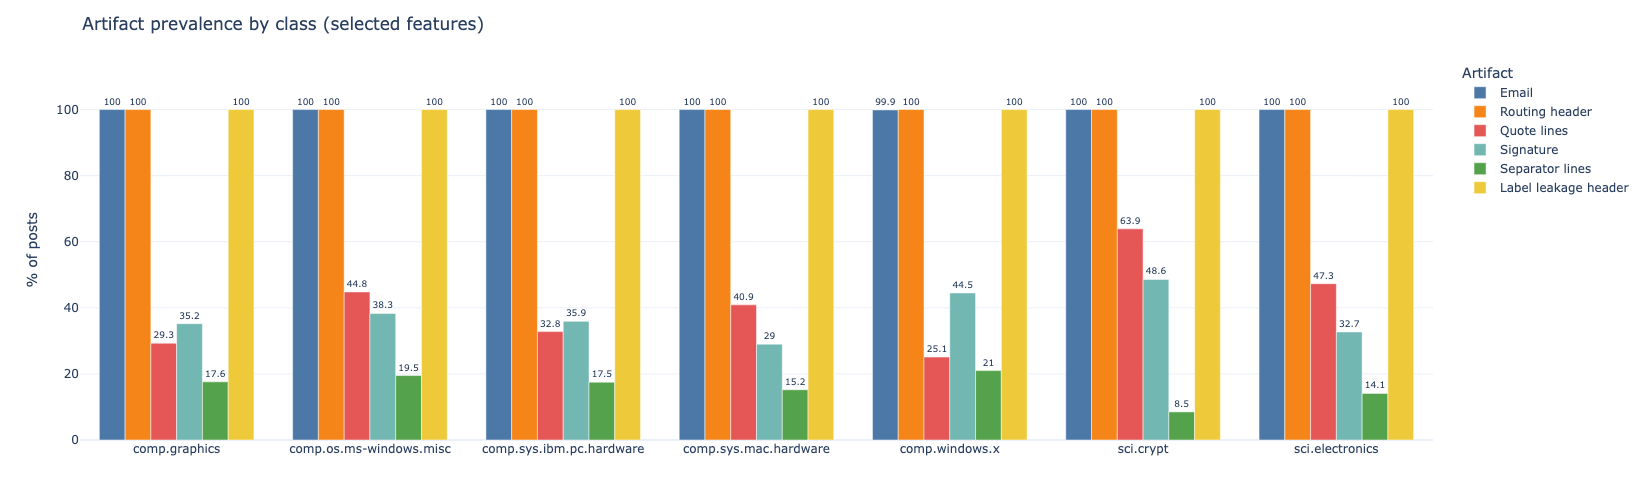

In [48]:
#visual
labels = artifact_by_class_selected.index.tolist()

# column names for display
col_labels = {
    "has_email": "Email",
    "has_routing_threading_header": "Routing header",
    "has_quote_lines": "Quote lines",
    "has_signature_marker": "Signature",
    "has_separator_lines": "Separator lines",
    "has_label_leakage_header": "Label leakage header",
}

fig = go.Figure()

for col in selected_artifact_presence:
    fig.add_trace(go.Bar(
        name=col_labels[col],
        x=labels,
        y=(artifact_by_class_selected[col] * 100).round(1),
        text=(artifact_by_class_selected[col] * 100).round(1),
        textposition="outside",
        textfont=dict(size=9),
    ))

fig.update_layout(
    barmode="group",
    title="Artifact prevalence by class (selected features)",
    xaxis_title=None,
    yaxis_title="% of posts",
    yaxis=dict(range=[0, 115]),
    legend_title="Artifact",
    height=480,
    colorway=px.colors.qualitative.T10,
    template="plotly_white",
    margin=dict(t=60, b=40),
)

fig.show()

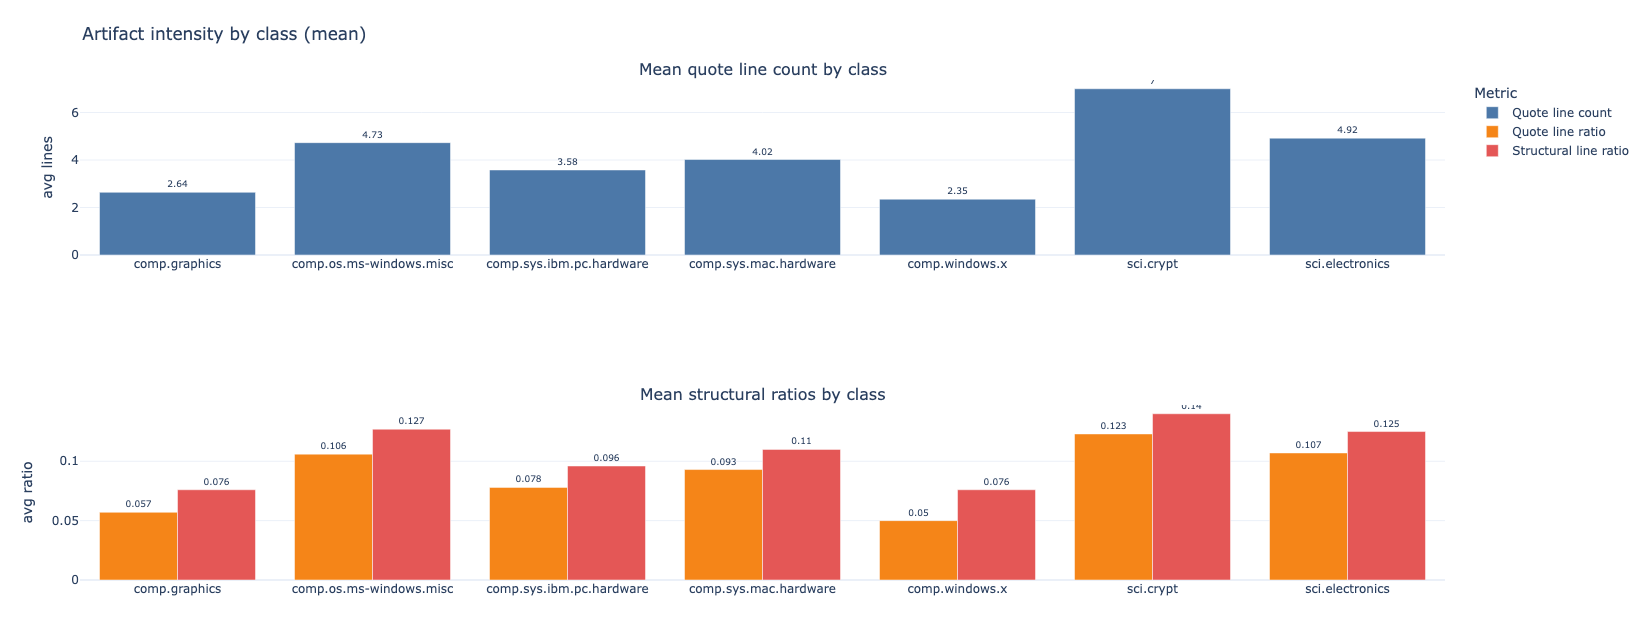

In [49]:
# visual
labels = artifact_intensity_selected.index.tolist()

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        "Mean quote line count by class",
        "Mean structural ratios by class"
    ),
    vertical_spacing=0.30
)

# row 1: quote_line_count (mean)
fig.add_trace(go.Bar(
    name="Quote line count",
    x=labels,
    y=artifact_intensity_selected["quote_line_count"]["mean"].round(2),
    text=artifact_intensity_selected["quote_line_count"]["mean"].round(2),
    textposition="outside",
    textfont=dict(size=9),
    marker_color=px.colors.qualitative.T10[0],
), row=1, col=1)

# row 2: quote_line_ratio and structural_line_ratio (mean)
for i, (col, label) in enumerate([
    ("quote_line_ratio", "Quote line ratio"),
    ("structural_line_ratio", "Structural line ratio"),
]):
    fig.add_trace(go.Bar(
        name=label,
        x=labels,
        y=artifact_intensity_selected[col]["mean"].round(3),
        text=artifact_intensity_selected[col]["mean"].round(3),
        textposition="outside",
        textfont=dict(size=9),
        marker_color=px.colors.qualitative.T10[i + 1],
    ), row=2, col=1)

fig.update_layout(
    title="Artifact intensity by class (mean)",
    height=620,
    template="plotly_white",
    colorway=px.colors.qualitative.T10,
    barmode="group",
    legend_title="Metric",
    margin=dict(t=80, b=40),
)

fig.update_yaxes(title_text="avg lines", row=1, col=1)
fig.update_yaxes(title_text="avg ratio", row=2, col=1)

fig.show()

### How many Newsgroups-like lines are top-level vs embedded/quoted?

In [50]:
# split top header vs body
def split_header_body(text):
    """
    Split a raw newsgroup post into an initial header block and the remaining body.
    The initial header block is defined as all lines before the first blank line.
    """
    lines = text.splitlines()
    header_lines = []
    body_start = len(lines)

    for i, line in enumerate(lines):
        if line.strip() == "":
            body_start = i + 1
            break
        header_lines.append(line)

    body_lines = lines[body_start:]
    return header_lines, body_lines


def count_header_like_lines(lines, field_name):
    """
    Count header-like lines in a list of lines.
    Allows indentation and common quote markers because embedded quoted metadata
    may appear as '  Newsgroups:' or '> Newsgroups:'.
    """
    pattern = rf"^\s*(?:[>#|]\s+)?{re.escape(field_name)}\s*:"
    return sum(bool(re.match(pattern, line, flags=re.IGNORECASE)) for line in lines)


def count_top_level_header_lines(text, field_name):
    header_lines, _ = split_header_body(text)
    pattern = rf"^{re.escape(field_name)}\s*:"
    return sum(bool(re.match(pattern, line, flags=re.IGNORECASE)) for line in header_lines)


def count_body_header_like_lines(text, field_name):
    _, body_lines = split_header_body(text)
    return count_header_like_lines(body_lines, field_name)

In [51]:
# newsgroups top-level vs body
df_artifacts["newsgroups_top_count"] = df_artifacts["text"].apply(
    lambda x: count_top_level_header_lines(x, "Newsgroups"))

df_artifacts["newsgroups_body_count"] = df_artifacts["text"].apply(
    lambda x: count_body_header_like_lines(x, "Newsgroups"))

df_artifacts["newsgroups_any_count"] = (
    df_artifacts["newsgroups_top_count"] + df_artifacts["newsgroups_body_count"])

df_artifacts["has_newsgroups_top"] = df_artifacts["newsgroups_top_count"] > 0
df_artifacts["has_newsgroups_body"] = df_artifacts["newsgroups_body_count"] > 0
df_artifacts["has_newsgroups_any"] = df_artifacts["newsgroups_any_count"] > 0

newsgroups_summary = pd.DataFrame({
    "feature": [
        "has_newsgroups_any",
        "has_newsgroups_top",
        "has_newsgroups_body",
    ],
    "count": [
        df_artifacts["has_newsgroups_any"].sum(),
        df_artifacts["has_newsgroups_top"].sum(),
        df_artifacts["has_newsgroups_body"].sum(),
    ],
    "share": [
        df_artifacts["has_newsgroups_any"].mean(),
        df_artifacts["has_newsgroups_top"].mean(),
        df_artifacts["has_newsgroups_body"].mean(),
    ],
})

newsgroups_summary.style.format({"share": "{:.2%}"})

,feature,count,share
0,has_newsgroups_any,6937,100.00%
1,has_newsgroups_top,6937,100.00%
2,has_newsgroups_body,25,0.36%


In [52]:
# label_leakage_headers uses strict RFC-style matching (no indent allowed)
# count_header_fields pattern: ^FieldName\s*: at line start
# this intentionally differs from count_header_like_lines which allows indent/quotes
# 24 posts have true Newsgroups: header; 25 posts have Newsgroups: anywhere in body (incl quoted)

In [53]:
# inspect examples
newsgroups_examples = (
    df_artifacts[df_artifacts["has_newsgroups_any"]]
    [["label", "word_count", "line_count", "newsgroups_top_count", "newsgroups_body_count", "text"]]
    .copy()
)

newsgroups_examples.drop(columns=["text"]).head(10)

,label,word_count,line_count,newsgroups_top_count,newsgroups_body_count
0,sci.crypt,543,63,1,0
1,comp.sys.ibm.pc.hardware,352,51,1,0
2,comp.sys.ibm.pc.hardware,142,30,1,0
3,comp.graphics,210,48,1,0
4,comp.windows.x,42,13,1,0
5,comp.sys.mac.hardware,160,33,1,0
6,sci.crypt,697,78,1,0
7,sci.crypt,97,23,1,0
8,sci.crypt,255,45,1,0
9,sci.electronics,135,37,1,0


In [54]:
for idx, row in newsgroups_examples.head(5).iterrows():
    print("=" * 120)
    print(
        f"Index: {idx} | Label: {row['label']} | "
        f"Words: {row['word_count']} | Lines: {row['line_count']} | "
        f"Top Newsgroups: {row['newsgroups_top_count']} | "
        f"Body Newsgroups: {row['newsgroups_body_count']}"
    )
    print("=" * 120)
    print(preview_document_structure(row["text"], n_head=35, n_tail=0))
    print("\n")

Index: 0 | Label: sci.crypt | Words: 543 | Lines: 63 | Top Newsgroups: 1 | Body Newsgroups: 0
001: Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:15738 alt.security:10080 comp.org.eff.talk:17114 comp.security.misc:3535 comp.org.acm:1694 comp.org.ieee:1623
002: Newsgroups: sci.crypt,alt.security,comp.org.eff.talk,comp.security.misc,comp.org.acm,comp.org.ieee
003: Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!fs7.ece.cmu.edu!europa.eng.gtefsd.com!howland.reston.ans.net!usc!sdd.hp.com!network.ucsd.edu!nmt.edu!msny...
004: From: msnyder@nmt.edu (Rebecca Snyder)
005: Subject: public awareness (wasRe: text of White House announcement and Q&As on clipper chip encryption)
006: Message-ID: <1993Apr21.184113.3505@nmt.edu>
007: Organization: New Mexico Tech
008: References: <1993Apr17.001805.11432@clarinet.com> <1qnpjuINN8ci@gap.caltech.edu> <2076@rwing.UUCP>
009: Distribution: na
010: Date: Wed, 21 Apr 1993 18:41:13 GMT
011: Lines: 50
012: 
013: In article <2076@rwing.UUC

In [55]:
# body line counts and body quote ratio
def get_body_line_count(text):
    _, body_lines = split_header_body(text)
    return len(body_lines)


def count_quote_lines_in_body(text):
    _, body_lines = split_header_body(text)
    return sum(1 for line in body_lines if re.match(r"^\s*>", line))


df_artifacts["body_line_count"] = df_artifacts["text"].apply(get_body_line_count)
df_artifacts["body_quote_line_count"] = df_artifacts["text"].apply(count_quote_lines_in_body)

df_artifacts["body_quote_line_ratio"] = (
    df_artifacts["body_quote_line_count"] / df_artifacts["body_line_count"].replace(0, np.nan)
).fillna(0)

In [56]:
# how many posts are quote jeavy? 
quote_thresholds = [0.25, 0.50, 0.75]

quote_dominance_summary = []

for threshold in quote_thresholds:
    quote_dominance_summary.append({
        "body_quote_line_ratio_threshold": f">= {threshold:.2f}",
        "count": (df_artifacts["body_quote_line_ratio"] >= threshold).sum(),
        "share": (df_artifacts["body_quote_line_ratio"] >= threshold).mean(),
    })

quote_dominance_summary = pd.DataFrame(quote_dominance_summary)

display(quote_dominance_summary.style.format({"share": "{:.1%}"}))

,body_quote_line_ratio_threshold,count,share
0,>= 0.25,1793,25.8%
1,>= 0.50,499,7.2%
2,>= 0.75,51,0.7%


In [57]:
# quote dominance by class
quote_dominance_by_class = (
    df_artifacts
    .groupby("label")
    .agg(
        mean_body_quote_ratio=("body_quote_line_ratio", "mean"),
        median_body_quote_ratio=("body_quote_line_ratio", "median"),
        share_quote_heavy_25=("body_quote_line_ratio", lambda x: (x >= 0.25).mean()),
        share_quote_heavy_50=("body_quote_line_ratio", lambda x: (x >= 0.50).mean()),
        share_quote_heavy_75=("body_quote_line_ratio", lambda x: (x >= 0.75).mean()),
    )
)

quote_dominance_by_class.style.format("{:.1%}")

,mean_body_quote_ratio,median_body_quote_ratio,share_quote_heavy_25,share_quote_heavy_50,share_quote_heavy_75
label,,,,,
comp.graphics,8.7%,0.0%,17.1%,4.1%,0.0%
comp.os.ms-windows.misc,16.1%,0.0%,32.1%,10.7%,1.1%
comp.sys.ibm.pc.hardware,11.4%,0.0%,21.5%,7.9%,1.0%
comp.sys.mac.hardware,14.4%,0.0%,28.8%,7.9%,0.8%
comp.windows.x,7.5%,0.0%,13.8%,3.6%,0.4%
sci.crypt,18.7%,15.5%,35.7%,7.4%,0.5%
sci.electronics,16.2%,0.0%,31.8%,8.7%,1.3%


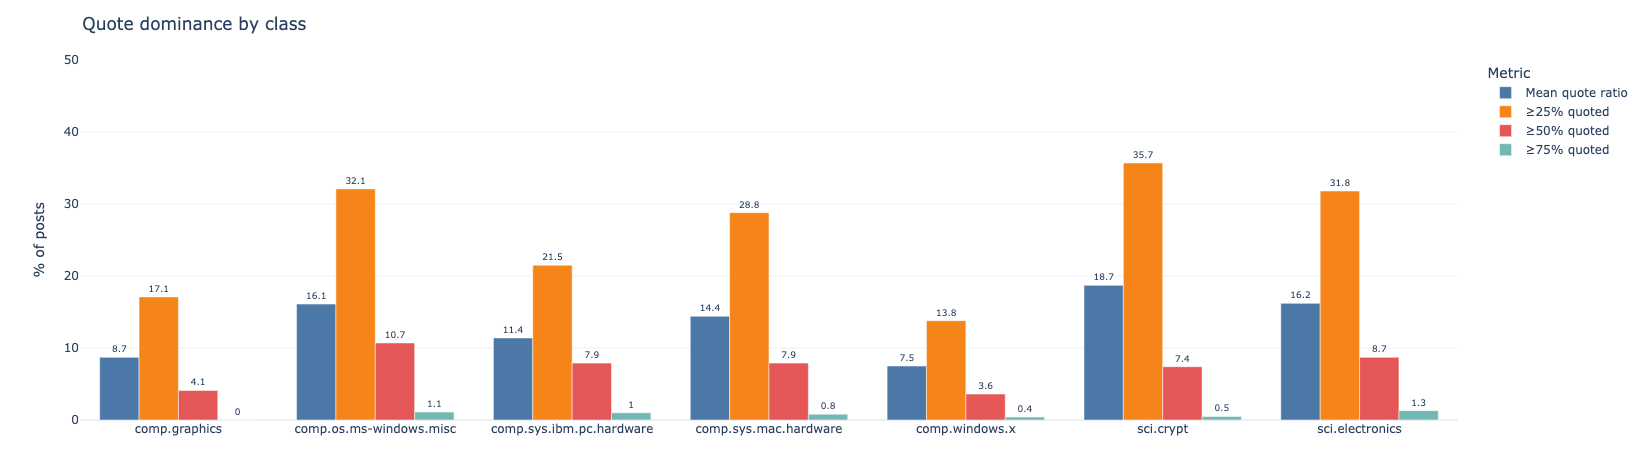

In [58]:
#visual
labels = quote_dominance_by_class.index.tolist()

cols = {
    "mean_body_quote_ratio": "Mean quote ratio",
    "share_quote_heavy_25": "≥25% quoted",
    "share_quote_heavy_50": "≥50% quoted",
    "share_quote_heavy_75": "≥75% quoted",
}

fig = go.Figure()

for col, name in cols.items():
    fig.add_trace(go.Bar(
        name=name,
        x=labels,
        y=(quote_dominance_by_class[col] * 100).round(1),
        text=(quote_dominance_by_class[col] * 100).round(1),
        textposition="outside",
        textfont=dict(size=9),
    ))

fig.update_layout(
    barmode="group",
    title="Quote dominance by class",
    xaxis_title=None,
    yaxis_title="% of posts",
    yaxis=dict(range=[0, 50]),
    legend_title="Metric",
    height=460,
    template="plotly_white",
    colorway=px.colors.qualitative.T10,
    margin=dict(t=60, b=40),
)

fig.show()

### Raw text artifact audit findings

Raw posts are structured Usenet-style records, not plain body-only texts. In the raw `20news-19997` archive, source and identity headers, routing/threading headers, content-adjacent headers, administrative headers, and `Newsgroups` headers appear in all documents. Email-like strings also appear in almost all documents. This means that the original raw input contains extensive metadata beyond the message body.

The most important source-specific finding is direct label leakage. Unlike the previously inspected sklearn-packaged version, the raw archive preserves the top-level `Newsgroups` header. In this selected subset, `Newsgroups` appears in 100% of documents and directly exposes the target category. Therefore, the original raw text is not a valid fair modelling input for topic classification. It is retained only as an audit reference and as a source for thread metadata extraction.

Other raw-format artifacts are also highly prevalent. Quoted replies appear in 40.7% of posts, signature markers in 37.8%, separator lines in 16.2%, path-like strings in 4.5%, hash-style quote markers in 2.2%, and URL/FTP-like strings in 1.7%. Quote behavior varies by class: `sci.crypt` remains the most quote-heavy category, followed by classes such as `sci.electronics`, `comp.os.ms-windows.misc`, and `comp.sys.mac.hardware`. This means quote structure itself may correlate with class labels.

Some high-structural-ratio posts consist mostly of quoted previous messages with a short author response appended. For classification, the full post can still be treated as the document input, but the model may learn from quoted prior content rather than the current author's own contribution.

The raw archive also contains rare special document types, including encoded payloads and FAQ/digest-style posts. These cases are retained but flagged because they may affect length, vocabulary, similarity diagnostics, and later error analysis.

### Artifact audit implications for modelling

1. Do not use `text_raw` as a fair modelling input. The raw archive contains top-level `Newsgroups` headers in all documents, which directly expose the target label.

2. Keep `text_raw` only as an audit reference and for metadata extraction needed during split construction, especially `Message-ID`, `References`, and `In-Reply-To`.

3. Create a metadata-rich but leakage-controlled representation that removes `Newsgroups` lines while preserving most other raw structure. This allows later comparison between metadata-rich and cleaned inputs without giving the model the label itself.

4. Compare metadata-rich no-leakage text against cleaned/body-focused text, because source, routing, administrative, and identity metadata are nearly universal in the raw archive.

5. Track quote-heavy posts as an evaluation slice, since quote behavior varies by class, especially for `sci.crypt`.

6. Do not assume quoted text is always noise. It may carry real topic vocabulary from a prior message, but it does not necessarily represent the current author's own contribution.

7. Be cautious when interpreting high performance on metadata-rich text. Sparse models may learn headers, signatures, sender/source information, repeated formatting patterns, or quoted context rather than robust topic vocabulary.

8. Use feature inspection for the TF-IDF baseline to distinguish meaningful topic terms from artifact-like tokens.

9. Revisit near-duplicate and thread-overlap risk during the modelling notebook. High raw similarity may reflect shared metadata, repeated quoted material, encoded payloads, FAQ reposts, or thread structure rather than independent content similarity.

In [59]:
df_artifacts.head()

,text,label_id,label,filename,message_id,char_count,word_count,line_count,subject_raw,has_uuencoded_payload,...,structural_line_ratio,newsgroups_top_count,newsgroups_body_count,newsgroups_any_count,has_newsgroups_top,has_newsgroups_body,has_newsgroups_any,body_line_count,body_quote_line_count,body_quote_line_ratio
0,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1573...,5,sci.crypt,15738,<1993Apr21.184113.3505@nmt.edu>,3706,543,63,public awareness (wasRe: text of White House a...,False,...,0.492063,1,0,1,True,False,True,50,31,0.620000
1,Newsgroups: comp.sys.ibm.pc.hardware\nPath: ca...,2,comp.sys.ibm.pc.hardware,60553,<1993Apr19.185511.2072@icd.teradyne.com>,2480,352,51,Re: Recommendations for a Local BUS (Cache,False,...,0.372549,1,0,1,True,False,True,38,19,0.500000
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,2,comp.sys.ibm.pc.hardware,58989,<1pstlnINN4r5@srvr1.engin.umich.edu>,1131,142,30,Floppy file copying,False,...,0.000000,1,0,1,True,False,True,15,0,0.000000
3,Newsgroups: comp.graphics\nPath: cantaloupe.sr...,0,comp.graphics,38932,<1993Apr28.181756.15458@kpc.com>,2115,210,48,Re: Kubota Kenai/Denali specs,False,...,0.354167,1,0,1,True,False,True,35,16,0.457143
4,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,4,comp.windows.x,67032,<1qv9bo$frb@menudo.uh.edu>,469,42,13,"Ask the ftp address of ""Kerberos Version 5 dra...",False,...,0.000000,1,0,1,True,False,True,1,0,0.000000


## <a id="preprocessing-regimes-their-impact"></a>Preprocessing Regimes & their impact

Preprocessing is treated as an experimental design choice. The goal is to create several controlled text representations and compare how much the task changes when direct label leakage, metadata, subject lines, and quoted material are included or removed.

This project separates two concepts:

- **Text-level preprocessing**: which parts of the original post are kept or removed before modelling.
- **Model-specific preprocessing**: how a vectorizer or tokenizer later converts that text into numerical features.

### Text regimes

Five text representations are created, but they do not have the same status.

| Regime | Description | Purpose |
|---|---|---|
| `text_raw` | Original archive text with all headers, metadata, `Newsgroups`, quotes, signatures, and body text preserved. | Audit-only raw reference. It is not used as a fair modelling input because it contains direct `Newsgroups` label leakage in all documents. |
| `text_metadata_rich_no_leakage` | Keeps most raw Usenet structure, including headers, threading metadata, quotes, signatures, and body text, but removes `Newsgroups` lines, masks contacts/URLs, and removes encoded payloads. | Diagnostic metadata-rich condition without direct label leakage. It tests how much models benefit from raw metadata and structure after explicit label leakage is removed. |
| `text_subject_body_clean` | Keeps the subject line and message body, while removing source, routing, administrative, and leakage-style metadata. Contacts/URLs are masked and encoded payloads are removed. | Main cleaned candidate. This is closest to a realistic topic-routing input where title + body are available. |
| `text_body_only_clean` | Removes all top-level headers, including `Subject`, and keeps only cleaned body text. | Ablation to test whether classification depends heavily on the subject line. |
| `text_subject_body_no_quotes` | Starts from `text_subject_body_clean` and removes classic `>`-style quoted reply lines. | Diagnostic condition to test how much models rely on quoted previous-message content. |

`text_subject_body_no_quotes` removes `>`-style quoted lines only. Indented body lines from quoted messages without `>` markers are retained. This is a conservative choice consistent with the Usenet quote convention and avoids aggressively removing potentially relevant content.

Encoded payloads are treated differently from quoted text. They are not meaningful natural-language topic content, so they are removed or replaced with a placeholder in modelling-ready text regimes while the documents themselves are retained.

#### Boundary decisions

The preprocessing strategy follows these decisions:

1. **Do not filter by document length at this stage.**  
   Long documents and very short documents are part of the dataset. Removing them would change the task definition. Instead, length will be tracked as an evaluation slice.

2. **Keep `Subject` in the main cleaned representation.**  
   The subject line is a realistic title-like signal for topic routing. However, `text_body_only_clean` is created to measure how much performance depends on this signal.

3. **Remove direct leakage-style metadata from cleaned regimes.**  
   `Newsgroups`-style lines are removed from cleaned variants because they can expose the target category name directly, even when they appear inside embedded or quoted metadata.

4. **Do not assume quoted text is always noise.**  
   Quoted replies may contain useful topic context, but they may represent previous-message content rather than the current author’s own contribution. For this reason, quote removal is tested as a separate regime instead of being treated as automatically correct.

5. **Preserve technical vocabulary where possible.**  
   Numbers, abbreviations, software names, standards, and technical tokens may carry genuine topic signal. The preprocessing should remove structural artifacts without aggressively destroying domain-specific terms.

#### What this section evaluates

For each text regime, the analysis will compare:

- document length changes;
- number of empty or very short documents after cleaning;
- remaining artifact indicators;
- vocabulary size and frequent terms;
- examples before and after preprocessing.

This section does not decide the final model yet. Its purpose is to show how preprocessing changes the input space and to prepare controlled comparisons for the baseline and transformer stages.

In [60]:
# helper functions

ALL_HEADER_FIELDS = (
    label_leakage_headers
    + source_identity_headers
    + routing_threading_headers
    + content_adjacent_headers
    + administrative_headers
)

# A sorted unique list avoids duplicate field names and matches longer fields first.
ALL_HEADER_FIELDS = sorted(set(ALL_HEADER_FIELDS), key=len, reverse=True)


def split_header_body(text):
    """
    Split a raw newsgroup post into the initial header block and body.
    The header block is defined as all lines before the first blank line.
    """
    if pd.isna(text):
        return [], []

    lines = str(text).splitlines()
    header_lines = []
    body_start = len(lines)

    for i, line in enumerate(lines):
        if line.strip() == "":
            body_start = i + 1
            break
        header_lines.append(line)

    body_lines = lines[body_start:]
    return header_lines, body_lines


def extract_top_header_value(text, field_name):
    """
    Extract a field value from the initial top-level header block only.
    Example: Subject: Re: something -> Re: something
    """
    header_lines, _ = split_header_body(text)

    pattern = rf"^{re.escape(field_name)}\s*:\s*(.*)$"

    for line in header_lines:
        match = re.match(pattern, line, flags=re.IGNORECASE)
        if match:
            return match.group(1).strip()

    return ""


def is_header_like_line(line, header_fields=ALL_HEADER_FIELDS):
    """
    Detect header-like lines anywhere in the body.

    This intentionally allows indentation and quote-like prefixes because
    embedded/quoted metadata can appear as:
      Newsgroups: ...
         Newsgroups: ...
      > From: ...
    """
    fields_pattern = "|".join(re.escape(field) for field in header_fields)
    pattern = rf"^\s*(?:[>#|]+\s*)?(?:{fields_pattern})\s*:"

    return bool(re.match(pattern, line, flags=re.IGNORECASE))


def is_label_leakage_line(line):
    """
    Detect Newsgroups-style label leakage lines anywhere in the document.

    In the raw 20news-19997 archive, top-level Newsgroups headers directly expose
    the target category. Quoted or embedded Newsgroups lines can also expose labels.
    """
    return bool(
        re.match(
            r"^\s*(?:[>#|]+\s*)?Newsgroups\s*:",
            line,
            flags=re.IGNORECASE,
        )
    )


def remove_label_leakage_lines(text):
    """
    Remove Newsgroups header-like lines anywhere in the document.
    This is used to remove direct label leakage from metadata-rich representations.
    """
    if pd.isna(text):
        return ""

    cleaned_lines = [
        line for line in str(text).splitlines()
        if not is_label_leakage_line(line)
    ]

    return "\n".join(cleaned_lines)


def is_quote_line(line):
    """
    Conservative quote detection.
    Removes classic Usenet quoted lines starting with >.
    Does not remove colon-style, indentation-only, or hash-style quote lines by default.
    """
    return bool(re.match(r"^\s*>", line))


def remove_signature_block(text, max_signature_lines=40):
    """
    Conservatively remove a signature block if a '--' marker appears near the end.
    This avoids removing mid-document separators or content sections.
    """
    lines = str(text).splitlines()

    signature_indices = [
        i for i, line in enumerate(lines)
        if re.match(r"^\s*--\s*$", line)
    ]

    if not signature_indices:
        return text

    last_sig_idx = signature_indices[-1]

    # Remove only if the signature marker is near the end.
    if len(lines) - last_sig_idx <= max_signature_lines:
        lines = lines[:last_sig_idx]

    return "\n".join(lines)


def remove_separator_lines(text):
    """
    Remove purely decorative separator lines.
    Keeps normal technical text and code-like content.
    """
    lines = str(text).splitlines()

    cleaned_lines = [
        line for line in lines
        if not re.match(r"^\s*[-=*_\|]{6,}\s*$", line)
    ]

    return "\n".join(cleaned_lines)


def mask_email_and_url(text):
    """
    Replace email-like strings and URL/FTP references with placeholders.
    Generic file paths are not masked here to avoid deleting useful technical signal.
    """
    text = str(text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " <EMAIL> ", text)
    text = re.sub(
        r"https?://\S+|www\.\S+|\bftp\.[\w\.-]+\b",
        " <URL> ",
        text,
        flags=re.IGNORECASE,
    )
    return text


UUENCODE_BEGIN_PATTERN = re.compile(r"(?im)^begin\s+[0-7]{3}\s+\S+")
UUENCODE_END_PATTERN = re.compile(r"(?im)^end\s*$")

# Uuencoded-like payload lines often start with M and contain long printable encoded sequences.
UUENCODE_DATA_LINE_PATTERN = re.compile(r"^\s*M[!-`]{50,}\s*$")


def remove_encoded_payload(text, placeholder="<ENCODED_PAYLOAD>"):
    """
    Remove or replace uuencoded / encoded-payload content from text.

    Handles:
    1. Classic uuencoded blocks from 'begin 644 filename' to 'end'.
    2. Standalone uuencoded-like payload lines such as long lines starting with 'M'.

    The document is retained; only non-linguistic encoded payload content is removed.
    """
    if pd.isna(text):
        return ""

    lines = str(text).splitlines()
    cleaned_lines = []

    inside_block = False
    placeholder_added_for_block = False
    previous_line_was_payload = False

    for line in lines:
        if UUENCODE_BEGIN_PATTERN.match(line):
            inside_block = True
            placeholder_added_for_block = True
            previous_line_was_payload = False
            cleaned_lines.append(placeholder)
            continue

        if inside_block:
            if UUENCODE_END_PATTERN.match(line):
                inside_block = False
            continue

        if UUENCODE_DATA_LINE_PATTERN.match(line):
            # Add one placeholder for a consecutive standalone payload region.
            if not previous_line_was_payload:
                cleaned_lines.append(placeholder)
            previous_line_was_payload = True
            continue

        previous_line_was_payload = False
        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def normalize_whitespace(text):
    """
    Normalize repeated whitespace while keeping paragraph boundaries lightly.
    """
    text = str(text)

    # Remove trailing spaces per line.
    lines = [line.rstrip() for line in text.splitlines()]

    # Collapse repeated blank lines.
    normalized_lines = []
    blank_seen = False

    for line in lines:
        if line.strip() == "":
            if not blank_seen:
                normalized_lines.append("")
            blank_seen = True
        else:
            normalized_lines.append(line)
            blank_seen = False

    text = "\n".join(normalized_lines).strip()

    # Collapse excessive spaces/tabs inside lines.
    text = re.sub(r"[ \t]+", " ", text)

    return text

In [61]:
def build_metadata_rich_no_leakage(text):
    """
    Build a metadata-rich diagnostic representation without direct label leakage.

    Keeps most raw Usenet structure, including headers, threading metadata,
    quoted replies, signatures, and body text.

    Removes:
    - Newsgroups lines, because they directly expose the target label;
    - encoded payloads, because they are non-linguistic artifacts;
    - raw email/URL strings, which are replaced with placeholders.
    """
    if pd.isna(text):
        return ""

    cleaned_text = remove_label_leakage_lines(text)
    cleaned_text = remove_encoded_payload(cleaned_text)
    cleaned_text = mask_email_and_url(cleaned_text)
    cleaned_text = normalize_whitespace(cleaned_text)

    return cleaned_text

In [62]:
def build_clean_text(
    text,
    keep_subject=True,
    remove_quotes=False,
    remove_embedded_headers=True,
    remove_signature=True,
    remove_separators=True,
    mask_contacts=True,
    remove_encoded_payloads=True,
):
    """
    Build cleaned text from a raw Usenet post.

    The main cleaned regime keeps Subject + body while removing metadata-heavy
    and leakage-style structure. Ablation regimes can remove Subject or quotes.
    """
    if pd.isna(text):
        return ""

    subject = extract_top_header_value(text, "Subject")
    _, body_lines = split_header_body(text)

    cleaned_body_lines = []

    for line in body_lines:
        if remove_quotes and is_quote_line(line):
            continue

        if remove_embedded_headers and is_header_like_line(line):
            continue

        cleaned_body_lines.append(line)

    cleaned_text = "\n".join(cleaned_body_lines)

    if remove_encoded_payloads:
        cleaned_text = remove_encoded_payload(cleaned_text)

    if remove_separators:
        cleaned_text = remove_separator_lines(cleaned_text)

    if remove_signature:
        cleaned_text = remove_signature_block(cleaned_text, max_signature_lines=40)

    if mask_contacts:
        cleaned_text = mask_email_and_url(cleaned_text)

    cleaned_text = normalize_whitespace(cleaned_text)

    if keep_subject and subject:
        cleaned_text = normalize_whitespace(subject + "\n\n" + cleaned_text)

    # Important: mask contacts again after adding Subject.
    # Some Subject lines contain raw email addresses.
    if mask_contacts:
        cleaned_text = mask_email_and_url(cleaned_text)

    cleaned_text = normalize_whitespace(cleaned_text)

    return cleaned_text

In [63]:
df_preprocessed = df_eda.copy()

df_preprocessed["text_raw"] = df_preprocessed["text"]

df_preprocessed["text_metadata_rich_no_leakage"] = df_preprocessed["text"].apply(
    build_metadata_rich_no_leakage
)

df_preprocessed["text_subject_body_clean"] = df_preprocessed["text"].apply(
    lambda x: build_clean_text(
        x,
        keep_subject=True,
        remove_quotes=False,
    )
)

df_preprocessed["text_body_only_clean"] = df_preprocessed["text"].apply(
    lambda x: build_clean_text(
        x,
        keep_subject=False,
        remove_quotes=False,
    )
)

df_preprocessed["text_subject_body_no_quotes"] = df_preprocessed["text"].apply(
    lambda x: build_clean_text(
        x,
        keep_subject=True,
        remove_quotes=True,
    )
)

In [64]:
# add lenght columsn to eacg regime
text_regimes = [
    "text_raw",
    "text_metadata_rich_no_leakage",
    "text_subject_body_clean",
    "text_body_only_clean",
    "text_subject_body_no_quotes",
]

modeling_text_regimes = [
    "text_metadata_rich_no_leakage",
    "text_subject_body_clean",
    "text_body_only_clean",
    "text_subject_body_no_quotes",
]


for col in text_regimes:
    df_preprocessed[f"{col}_char_count"] = df_preprocessed[col].str.len()
    df_preprocessed[f"{col}_word_count"] = df_preprocessed[col].str.split().str.len()
    df_preprocessed[f"{col}_line_count"] = df_preprocessed[col].str.count("\n") + 1
    df_preprocessed[f"{col}_is_empty"] = df_preprocessed[col].str.strip().eq("")
    df_preprocessed[f"{col}_is_very_short"] = df_preprocessed[f"{col}_word_count"].fillna(0) < 20

In [65]:
# compare lenght impact
length_impact_rows = []

for col in text_regimes:
    length_impact_rows.append({
        "text_regime": col,
        "mean_words": df_preprocessed[f"{col}_word_count"].mean(),
        "median_words": df_preprocessed[f"{col}_word_count"].median(),
        "max_words": df_preprocessed[f"{col}_word_count"].max(),
        "mean_lines": df_preprocessed[f"{col}_line_count"].mean(),
        "median_lines": df_preprocessed[f"{col}_line_count"].median(),
        "empty_docs": df_preprocessed[f"{col}_is_empty"].sum(),
        "very_short_docs_<20_words": df_preprocessed[f"{col}_is_very_short"].sum(),
        "very_short_share": df_preprocessed[f"{col}_is_very_short"].mean(),
    })

length_impact = pd.DataFrame(length_impact_rows)

display(
    length_impact.style.format({
        "mean_words": "{:.1f}",
        "median_words": "{:.1f}",
        "max_words": "{:.0f}",
        "mean_lines": "{:.1f}",
        "median_lines": "{:.1f}",
        "empty_docs": "{:.0f}",
        "very_short_docs_<20_words": "{:.0f}",
        "very_short_share": "{:.1%}",
    })
)

,text_regime,mean_words,median_words,max_words,mean_lines,median_lines,empty_docs,very_short_docs_<20_words,very_short_share
0,text_raw,259.2,172.0,11839,48.3,33.0,0,0,0.0%
1,text_metadata_rich_no_leakage,258.9,174.0,11844,42.5,30.0,0,0,0.0%
2,text_subject_body_clean,212.9,128.0,11351,31.2,19.0,0,146,2.1%
3,text_body_only_clean,207.2,122.0,11341,29.3,17.0,33,220,3.2%
4,text_subject_body_no_quotes,176.3,94.0,11351,26.7,15.0,0,195,2.8%


In [66]:
# visual
regimes = length_impact["text_regime"].tolist()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Mean & median word count by regime", "Very short docs (<20 words) share"),
    horizontal_spacing=0.12
)

# Left: mean + median words 
fig.add_trace(go.Bar(
    name="Mean words",
    x=regimes,
    y=length_impact["mean_words"].round(1),
    text=length_impact["mean_words"].round(1),
    textposition="outside",
    textfont=dict(size=9),
    marker_color=px.colors.qualitative.T10[0],
), row=1, col=1)

fig.add_trace(go.Bar(
    name="Median words",
    x=regimes,
    y=length_impact["median_words"].round(1),
    text=length_impact["median_words"].round(1),
    textposition="outside",
    textfont=dict(size=9),
    marker_color=px.colors.qualitative.T10[1],
), row=1, col=1)

#  Right: very short share
fig.add_trace(go.Bar(
    name="Very short share",
    x=regimes,
    y=(length_impact["very_short_share"] * 100).round(1),
    text=(length_impact["very_short_share"] * 100).round(1),
    textposition="outside",
    textfont=dict(size=9),
    marker_color=px.colors.qualitative.T10[2],
    showlegend=True,
), row=1, col=2)

fig.update_layout(
    title="Length impact by preprocessing regime",
    barmode="group",
    height=420,
    template="plotly_white",
    colorway=px.colors.qualitative.T10,
    legend_title="Metric",
    margin=dict(t=70, b=60),
)

fig.update_yaxes(title_text="word count", row=1, col=1)
fig.update_yaxes(title_text="% of posts", row=1, col=2)
fig.update_xaxes(tickangle=15)

fig.show()

In [67]:
# retained-word ratio compared with raw
for col in text_regimes:
    if col == "text_raw":
        continue

    df_preprocessed[f"{col}_word_retention_vs_raw"] = (
        df_preprocessed[f"{col}_word_count"] /
        df_preprocessed["text_raw_word_count"].replace(0, np.nan)
    ).fillna(0)


retention_cols = [
    f"{col}_word_retention_vs_raw"
    for col in text_regimes
    if col != "text_raw"
]

retention_summary = (
    df_preprocessed[retention_cols]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .T
)

retention_summary.style.format("{:.2f}")

,count,mean,std,min,10%,25%,50%,75%,90%,max
text_metadata_rich_no_leakage_word_retention_vs_raw,6937.00,1.01,0.05,0.02,1.00,1.00,1.01,1.03,1.04,1.21
text_subject_body_clean_word_retention_vs_raw,6937.00,0.73,0.16,0.01,0.50,0.64,0.76,0.85,0.90,1.02
text_body_only_clean_word_retention_vs_raw,6937.00,0.69,0.18,0.00,0.45,0.59,0.73,0.83,0.89,1.00
text_subject_body_no_quotes_word_retention_vs_raw,6937.00,0.59,0.21,0.01,0.29,0.44,0.62,0.76,0.86,1.02


In [68]:
# preprocess impackt by class 
class_length_impact = []

for label, group in df_preprocessed.groupby("label"):
    row = {"label": label}

    for col in text_regimes:
        row[f"{col}_median_words"] = group[f"{col}_word_count"].median()
        row[f"{col}_mean_words"] = group[f"{col}_word_count"].mean()

    row["subject_body_clean_retention_median"] = group[
        "text_subject_body_clean_word_retention_vs_raw"
    ].median()

    row["body_only_clean_retention_median"] = group[
        "text_body_only_clean_word_retention_vs_raw"
    ].median()

    row["no_quotes_retention_median"] = group[
        "text_subject_body_no_quotes_word_retention_vs_raw"
    ].median()

    class_length_impact.append(row)

class_length_impact = pd.DataFrame(class_length_impact)

display(
    class_length_impact.style.format({
        col: "{:.1f}" for col in class_length_impact.columns
        if col != "label"
    })
)

,label,text_raw_median_words,text_raw_mean_words,text_metadata_rich_no_leakage_median_words,text_metadata_rich_no_leakage_mean_words,text_subject_body_clean_median_words,text_subject_body_clean_mean_words,text_body_only_clean_median_words,text_body_only_clean_mean_words,text_subject_body_no_quotes_median_words,text_subject_body_no_quotes_mean_words,subject_body_clean_retention_median,body_only_clean_retention_median,no_quotes_retention_median
0,comp.graphics,141.0,278.0,144.0,281.2,100.0,236.3,95.0,231.3,83.0,214.5,0.7,0.7,0.6
1,comp.os.ms-windows.misc,167.0,234.9,165.0,214.4,122.0,169.0,117.0,163.4,82.0,129.8,0.7,0.7,0.5
2,comp.sys.ibm.pc.hardware,169.0,216.5,172.0,218.8,128.0,176.6,122.0,171.1,99.0,145.2,0.8,0.7,0.7
3,comp.sys.mac.hardware,163.0,203.1,164.0,205.8,122.0,163.7,114.0,157.9,85.0,129.0,0.8,0.7,0.6
4,comp.windows.x,166.5,306.4,169.0,307.6,120.0,259.1,114.0,253.8,99.5,239.2,0.7,0.7,0.7
5,sci.crypt,222.0,348.9,228.5,354.3,174.5,301.0,168.0,293.5,126.0,237.2,0.8,0.8,0.6
6,sci.electronics,178.0,225.6,182.0,228.9,136.0,183.9,131.0,178.4,97.0,138.9,0.8,0.7,0.6


In [69]:
# visula

# tight orders
regime_cols = [
    "text_raw_median_words",
    "text_subject_body_clean_median_words",
    "text_body_only_clean_median_words",
    "text_subject_body_no_quotes_median_words",
]
regime_labels = ["raw", "subject+body\nclean", "body only\nclean", "no quotes"]

fig = go.Figure()

for _, row in class_length_impact.iterrows():
    label = row["label"]
    y_vals = [row[col] for col in regime_cols]
    fig.add_trace(go.Scatter(
        x=regime_labels,
        y=y_vals,
        mode="lines+markers",
        name=label,
        text=[f"{v:.0f}" for v in y_vals],
        textposition="top center",
        textfont=dict(size=8),
        marker=dict(size=7),
    ))

fig.update_layout(
    title="Median word count by class across preprocessing regimes",
    xaxis_title="Preprocessing regime",
    yaxis_title="Median word count",
    height=440,
    template="plotly_white",
    colorway=px.colors.qualitative.T10,
    legend_title="Class",
    margin=dict(t=60, b=40),
)

fig.show()

In [70]:
# visual heatmap retention by cladss

retention_cols = [
    "subject_body_clean_retention_median",
    "body_only_clean_retention_median",
    "no_quotes_retention_median",
]
retention_labels = ["subject+body clean", "body only clean", "no quotes"]

z = class_length_impact[retention_cols].values * 100
labels = class_length_impact["label"].tolist()

fig = go.Figure(go.Heatmap(
    z=z,
    x=retention_labels,
    y=labels,
    colorscale="Blues",
    text=[[f"{v:.0f}%" for v in row] for row in z],
    texttemplate="%{text}",
    textfont=dict(size=11),
    colorbar=dict(title="% retained"),
    zmin=0,
    zmax=100,
))

fig.update_layout(
    title="Word retention by class vs raw (median)",
    height=360,
    template="plotly_white",
    margin=dict(t=60, b=40, l=160),
    xaxis=dict(side="bottom"),
)

fig.show()

In [79]:
# fix! # stricter leakage control for modelling-ready text regimes
# This removes target category names and related group variants such as:
# comp.graphics, comp.graphics.visualization, comp.windows.x.apps, sci.crypt
# It intentionally does not remove ordinary semantic words like "graphics" or "windows".

NEWSGROUP_NAME_PATTERN = re.compile(
    r"(?i)(?<![A-Za-z0-9_+-])"
    r"(?:comp|sci|alt|rec|talk|soc|misc)"
    r"(?:\.[a-z0-9][a-z0-9_+-]*){1,}"
    r"(?![A-Za-z0-9_+-])"
)


def remove_newsgroup_names(text):
    """
    Remove explicit Usenet newsgroup-style names from modelling-ready text.

    Examples removed:
      comp.graphics
      comp.graphics.visualization
      comp.os.ms-windows.misc
      comp.windows.x.apps
      sci.crypt

    This step removes direct category-name shortcuts while preserving
    ordinary semantic topic words such as graphics, windows, crypt, electronics.
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = NEWSGROUP_NAME_PATTERN.sub(" ", text)
    text = normalize_whitespace(text)

    return text

FAIR_TEXT_REGIMES_TO_SANITIZE = [
    "text_metadata_rich_no_leakage",
    "text_subject_body_clean",
    "text_body_only_clean",
    "text_subject_body_no_quotes",
]

for col in FAIR_TEXT_REGIMES_TO_SANITIZE:
    df_preprocessed[col] = df_preprocessed[col].apply(remove_newsgroup_names)

In [80]:
# check before/after examples
def print_regime_comparison(df, idx, max_chars=1200):
    row = df.loc[idx]

    print("=" * 120)
    print(f"Index: {idx} | Label: {row['label']}")
    print("=" * 120)

    for col in text_regimes:
        text = row[col]
        preview = text[:max_chars] + ("..." if len(text) > max_chars else "")

        print(f"\n--- {col} ---")
        print(
            f"chars={row[f'{col}_char_count']} | "
            f"words={row[f'{col}_word_count']} | "
            f"lines={row[f'{col}_line_count']}"
        )
        print(preview)
        print()

interesting_indices = [
    521,   # embedded Newsgroups leakage
    6716,  # high quote ratio
    683,   # FAQ / long reference post
    275,   # representative comp.graphics example
]

for idx in interesting_indices:
    print_regime_comparison(df_preprocessed, idx, max_chars=1200)

Index: 521 | Label: sci.electronics

--- text_raw ---
chars=1242 | words=158 | lines=28
Newsgroups: sci.electronics
Path: cantaloupe.srv.cs.cmu.edu!rochester!udel!bogus.sura.net!darwin.sura.net!zaphod.mps.ohio-state.edu!magnus.acs.ohio-state.edu!mbattist
From: mbattist@magnus.acs.ohio-state.edu (Mark A Battisti)
Subject: Re: Clear LCD or LED "sheets"
Message-ID: <1993Apr26.183654.29750@magnus.acs.ohio-state.edu>
Sender: news@magnus.acs.ohio-state.edu
Nntp-Posting-Host: magnusug.magnus.acs.ohio-state.edu
Organization: The Ohio State University
 writes:
References: <1993Apr26.141409.22154@magnus.acs.ohio-state.edu> <1rgssrINNnqb@ga
Distribution: usa
Date: Mon, 26 Apr 1993 18:36:54 GMT
Lines: 13

>>An ideal item would be an LED array for which each LED is about 1/2" square.
>>(Yes very coarse)  This is for distance viewing, but on a window.
>>Any pointers of suggestions would be much appreciated.
>
>What, pray tell, are you putting together?  And what about costs?  And does it
>have to be

### Residual artifact check after preprocessing

After creating the text regimes, I run a residual artifact check to verify that preprocessing changed the intended properties of the text.

This check does not prove that the cleaned text is fully artifact-free. Instead, it tests whether the main obvious artifacts are reduced: raw email strings, URL/FTP strings, embedded `Newsgroups` or `Path` lines, header-like lines, quote markers, signatures, and separators.

Masked placeholders such as `<EMAIL>` are counted separately from raw email strings. Their presence means that contact information was detected and replaced, not that the original email address remains.

In [81]:
# fix! after additional cleaning stage!

TARGET_CATEGORY_PATTERN = re.compile(
    "|".join(re.escape(label) for label in sorted(df_preprocessed["label"].unique(), key=len, reverse=True)),
    flags=re.IGNORECASE,
)

def has_target_category_name(text):
    if pd.isna(text):
        return False
    return bool(TARGET_CATEGORY_PATTERN.search(str(text)))


def has_newsgroup_like_name(text):
    if pd.isna(text):
        return False
    return bool(NEWSGROUP_NAME_PATTERN.search(str(text)))

In [82]:
def has_encoded_payload_residual(text):
    """
    Detect residual encoded payload content after preprocessing.
    This catches both classic uuencode block starts and uuencoded-like data lines.
    """
    if pd.isna(text):
        return False

    text = str(text)

    return bool(
        UUENCODE_BEGIN_PATTERN.search(text)
        or any(UUENCODE_DATA_LINE_PATTERN.match(line) for line in text.splitlines())
    )


def artifact_summary_for_text_column(df, text_col):
    """
    Summarize residual artifact indicators for one text representation.

    Some indicators are expected to remain in metadata-rich regimes
    (e.g. header-like lines, Path lines, quotes, signatures).
    Critical safety checks are:
    - raw email/url strings should be removed or masked;
    - Newsgroups lines should be removed from modelling-ready regimes;
    - encoded payloads should be removed or replaced.
    """
    texts = df[text_col].fillna("")

    summary = {
        # raw contact artifacts
        "has_raw_email": texts.apply(
            lambda x: regex_count(x, r"\b[\w\.-]+@[\w\.-]+\.\w+\b") > 0
        ).mean(),

        "has_raw_url_or_ftp": texts.apply(
            lambda x: regex_count(
                x,
                r"https?://\S+|www\.\S+|\bftp\.[\w\.-]+\b",
                flags=re.IGNORECASE
            ) > 0
        ).mean(),

        # masked placeholders
        "has_email_placeholder": texts.str.contains(r"<EMAIL>", regex=True).mean(),
        "has_url_placeholder": texts.str.contains(r"<URL>", regex=True).mean(),
        "has_encoded_payload_placeholder": texts.str.contains(
            r"<ENCODED_PAYLOAD>", regex=True
        ).mean(),

        # direct label leakage
        "has_newsgroups_line": texts.apply(
            lambda x: regex_count(
                x,
                r"(?mi)^\s*(?:[>#|]+\s*)?Newsgroups\s*:"
            ) > 0
        ).mean(),

        # routing-style metadata
        "has_path_line": texts.apply(
            lambda x: regex_count(
                x,
                r"(?mi)^\s*(?:[>#|]+\s*)?Path\s*:"
            ) > 0
        ).mean(),

        # target category name leakage (label names in text body)
        "has_target_category_name": texts.apply(has_target_category_name).mean(),

        # newsgroup-like name pattern (comp.*, sci.*, talk.*, etc.)
        "has_newsgroup_like_name": texts.apply(has_newsgroup_like_name).mean(),

        # any known header-like line
        "has_header_like_line": texts.apply(
            lambda x: any(is_header_like_line(line) for line in str(x).splitlines())
        ).mean(),

        # residual encoded payloads
        "has_encoded_payload_residual": texts.apply(has_encoded_payload_residual).mean(),

        # quoting / signature / formatting artifacts
        "has_quote_lines": texts.apply(
            lambda x: count_quote_lines(x) > 0
        ).mean(),

        "has_signature_marker": texts.apply(
            lambda x: regex_count(x, r"(?m)^--\s*$") > 0
        ).mean(),

        "has_separator_lines": texts.apply(
            lambda x: count_separator_lines(x) > 0
        ).mean(),
    }

    return pd.Series(summary)

In [83]:
# run for all regimes
artifact_residuals = pd.DataFrame({
    col: artifact_summary_for_text_column(df_preprocessed, col)
    for col in text_regimes
}).T

artifact_residuals.style.format("{:.1%}")

,has_raw_email,has_raw_url_or_ftp,has_email_placeholder,has_url_placeholder,has_encoded_payload_placeholder,has_newsgroups_line,has_path_line,has_target_category_name,has_newsgroup_like_name,has_header_like_line,has_encoded_payload_residual,has_quote_lines,has_signature_marker,has_separator_lines
text_raw,100.0%,1.7%,0.0%,0.0%,0.0%,100.0%,100.0%,100.0%,100.0%,100.0%,0.4%,40.7%,37.8%,16.2%
text_metadata_rich_no_leakage,0.0%,0.0%,100.0%,1.7%,0.4%,0.0%,100.0%,0.0%,0.0%,100.0%,0.0%,40.5%,37.7%,16.2%
text_subject_body_clean,0.0%,0.0%,65.8%,1.7%,0.4%,0.0%,0.0%,0.0%,0.0%,0.2%,0.0%,40.4%,1.0%,0.0%
text_body_only_clean,0.0%,0.0%,65.8%,1.7%,0.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,40.4%,1.0%,0.0%
text_subject_body_no_quotes,0.0%,0.0%,65.0%,1.5%,0.4%,0.0%,0.0%,0.0%,0.0%,0.2%,0.0%,0.0%,1.0%,0.0%


The residual artifact check is interpreted differently for different regimes. `text_raw` is an audit-only source representation and is expected to contain direct `Newsgroups` leakage and raw metadata. `text_metadata_rich_no_leakage` is still metadata-rich by design, so routing headers, header-like lines, quotes, and signatures may remain. However, it should remove direct `Newsgroups` leakage, raw contact strings, URLs, and encoded payloads.

The cleaned regimes are expected to remove both direct leakage and most raw structural artifacts while preserving topic-relevant content.

In [84]:
residual_raw_email_examples = df_preprocessed[
    df_preprocessed["text_subject_body_clean"].apply(
        lambda x: regex_count(x, r"\b[\w\.-]+@[\w\.-]+\.\w+\b") > 0
    )
][["label", "text_subject_body_clean"]]

print("Residual raw email examples:", len(residual_raw_email_examples))

for idx, row in residual_raw_email_examples.head(5).iterrows():
    print("=" * 120)
    print(f"Index: {idx} | Label: {row['label']}")
    print("=" * 120)
    print(row["text_subject_body_clean"][:1500])
    print()

Residual raw email examples: 0


In [85]:
# nspect residual header-like lines
def get_header_like_lines(text):
    return [
        line for line in text.splitlines()
        if is_header_like_line(line)
    ]


residual_header_examples = df_preprocessed[
    df_preprocessed["text_subject_body_clean"].apply(
        lambda x: len(get_header_like_lines(x)) > 0
    )
][["label", "text_subject_body_clean"]]

print("Residual header-like examples:", len(residual_header_examples))

for idx, row in residual_header_examples.head(10).iterrows():
    print("=" * 120)
    print(f"Index: {idx} | Label: {row['label']}")
    print("Header-like lines:")
    for line in get_header_like_lines(row["text_subject_body_clean"]):
        print(repr(line))
    print()

Residual header-like examples: 11
Index: 723 | Label: comp.os.ms-windows.misc
Header-like lines:
'Summary: ATI Graphics Ultra Questions etc'

Index: 875 | Label: comp.os.ms-windows.misc
Header-like lines:
'SUMMARY: Canon BJ200 vs. HP DeskJet 500'

Index: 1638 | Label: comp.windows.x
Header-like lines:
"SUMMARY: How to make a window's input be ALL CAPS"

Index: 1867 | Label: comp.windows.x
Header-like lines:
'SUMMARY: virtual mouse in ol{v}wm'

Index: 2775 | Label: comp.sys.ibm.pc.hardware
Header-like lines:
'Summary: DoubleDisk Gold v 6.0'

Index: 3205 | Label: comp.sys.mac.hardware
Header-like lines:
'SUMMARY: ZyXEL Strings'

Index: 3523 | Label: comp.sys.ibm.pc.hardware
Header-like lines:
'Subject: Re: 16550 v. 16550A ???'

Index: 4190 | Label: sci.crypt
Header-like lines:
'SUMMARY: responses / research on oracle password security'

Index: 5095 | Label: sci.crypt
Header-like lines:
'Summary: How sensible is DES towards bit-errors?'

Index: 5154 | Label: sci.crypt
Header-like lines:
'

In [86]:
# inspect residual signature markers
residual_signature_examples = df_preprocessed[
    df_preprocessed["text_subject_body_clean"].apply(
        lambda x: regex_count(x, r"(?m)^--\s*$") > 0
    )
][["label", "text_subject_body_clean"]]

print("Residual signature examples:", len(residual_signature_examples))

for idx, row in residual_signature_examples.head(5).iterrows():
    print("=" * 120)
    print(f"Index: {idx} | Label: {row['label']}")
    print("=" * 120)
    print(row["text_subject_body_clean"][-1500:])
    print()

Residual signature examples: 68
Index: 122 | Label: comp.sys.mac.hardware
Re: PC Syquest on a Mac??

In <1qsk6u$ <EMAIL> > <EMAIL> (Robert C. Sprecher) writes:

>Is it possible, ie via creative cable splicing or whatever, to
>hook a Syquest 44MB removable drive to a Mac?

>Is there any difference with the guts of the drive or is it
>just cable differences?

>Thanks.

Their should be no difference in the drive itself between IBM-PC and Mac.
The two main differences are the formatting of the disk itself (but with
the correct software each can read the others) and maybe the cable
(depends on your SCSI board on IBM-PC).

If you get some Mac softawre to allow mounting of ANY IBM-formatted disk
and the correct cable you should br able to mount and read your IBM-PC
syquest.

good luck,

--Paul

--
 +-------------------------------------------------------------------------+
 | Paul Hardwick | Technical Consulting | InterNet: <EMAIL> |
 | P.O. Box 1482 | for MVS (SP/XA/ESA) | Voice: (212) 535-0

### Residual artifact check findings

The residual artifact check confirms that the preprocessing regimes behave as intended.

The original `text_raw` representation preserves the full raw archive format: raw email strings, `Newsgroups` lines, `Path` lines, and header-like metadata appear in essentially all documents. This confirms that `text_raw` is not suitable as a fair modelling input and should be treated as an audit-only source representation.

The `text_metadata_rich_no_leakage` regime successfully removes the critical unsafe artifacts while preserving raw Usenet structure. Raw email and URL strings drop to 0.0%, `Newsgroups` lines drop to 0.0%, and residual encoded payloads drop to 0.0%. At the same time, `Path` lines, header-like lines, quote lines, signatures, and separators remain common by design. This regime is therefore metadata-rich but direct-leakage-controlled.

The main cleaned representation, `text_subject_body_clean`, removes direct leakage, raw contacts, routing metadata, encoded payloads, and separator lines while preserving the subject, body, and quoted context. Header-like residuals are rare at 0.2%, and signature markers remain in about 1.0% of documents. These residuals are kept because more aggressive cleaning could remove valid technical content.

The `text_subject_body_no_quotes` regime removes detected `>`-style quoted lines completely, reducing quote-line presence to 0.0%. This confirms that it can be used as a quote-dependence diagnostic.

Overall, the residual check supports the updated preprocessing design: `text_raw` is retained only for audit, `text_metadata_rich_no_leakage` tests metadata-rich inputs without direct label leakage, and the cleaned regimes provide progressively more body-focused representations for fair modelling comparisons.

## <a id="vocabulary-and-class-specific-lexical-signals"></a>Vocabulary and class-specific lexical signals

After creating the preprocessing regimes, the next step is to inspect what lexical signals remain in each representation.

This analysis has two goals. First, it checks whether the cleaned text still preserves meaningful technical vocabulary for topic classification. Second, it helps detect whether raw or cleaned representations contain suspicious artifact-like tokens, such as header terms, email fragments, organization names, routing tokens, or repeated formatting artifacts.

This is an exploratory analysis, not the final classifier. TF-IDF is used here as a diagnostic tool because it highlights terms that are frequent in a class but less common across the full corpus.

In [87]:
# vectorizer settings for EDA
# for clarity I use same settings for all regimes

# diagnostic stop words for readability
custom_stops = ["ax", "max", "don", "just", "like", "know", "use", "does", "email", "url","path", "nntp", "encoded_payload"]

vocab_eda_vectorizer_params = {
    "lowercase": True,
    "stop_words": list(CountVectorizer(stop_words="english").get_stop_words()) + custom_stops,
    "min_df": 5,
    "max_df": 0.80,
    "ngram_range": (1, 2),
    "max_features": 20000,
    "token_pattern": r"(?u)\b[a-zA-Z][a-zA-Z0-9_+\-\.]{1,}\b",
}

For this vocab diagnostic I use unigrams and bigrams with English stopword removal. The token pattern keeps many technical tokens that contain digits, underscores, hyphens, plus signs, or dots, because it may carry topic signal.

The same vectorizer settings are applied to each text regime so that vocabulary changes reflect preprocessing differences rather than different feature extraction rules.

In [88]:
# vocab size and matrix density by regime

def get_vectorizer_diagnostics(texts, vectorizer_cls=TfidfVectorizer, params=None):
    if params is None:
        params = {}

    vectorizer = vectorizer_cls(**params)
    X = vectorizer.fit_transform(texts.fillna(""))

    n_docs, n_features = X.shape
    density = X.nnz / (n_docs * n_features)

    return {
        "n_docs": n_docs,
        "n_features": n_features,
        "matrix_density": density,
        "avg_nonzero_features_per_doc": X.nnz / n_docs,
    }


vocab_diagnostics_rows = []

for col in text_regimes:
    diagnostics = get_vectorizer_diagnostics(
        df_preprocessed[col],
        vectorizer_cls=TfidfVectorizer,
        params=vocab_eda_vectorizer_params,
    )
    diagnostics["text_regime"] = col
    vocab_diagnostics_rows.append(diagnostics)

vocab_diagnostics = pd.DataFrame(vocab_diagnostics_rows)

display(
    vocab_diagnostics[
        [
            "text_regime",
            "n_docs",
            "n_features",
            "matrix_density",
            "avg_nonzero_features_per_doc",
        ]
    ].style.format({
        "n_docs": "{:,.0f}",
        "n_features": "{:,.0f}",
        "matrix_density": "{:.4%}",
        "avg_nonzero_features_per_doc": "{:.1f}",
    })
)

,text_regime,n_docs,n_features,matrix_density,avg_nonzero_features_per_doc
0,text_raw,"6,937","20,000",0.5581%,111.6
1,text_metadata_rich_no_leakage,"6,937","20,000",0.5289%,105.8
2,text_subject_body_clean,"6,937","20,000",0.3525%,70.5
3,text_body_only_clean,"6,937","20,000",0.3419%,68.4
4,text_subject_body_no_quotes,"6,937","17,158",0.3337%,57.3


In [89]:
# top frequent terms overall by regime

def get_top_count_terms(texts, params, top_n=30):
    vectorizer = CountVectorizer(**params)
    X = vectorizer.fit_transform(texts.fillna(""))

    term_counts = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())

    top_idx = term_counts.argsort()[::-1][:top_n]

    return pd.DataFrame({
        "term": terms[top_idx],
        "count": term_counts[top_idx],
    })


top_terms_by_regime = {}

for col in text_regimes:
    top_terms_by_regime[col] = get_top_count_terms(
        df_preprocessed[col],
        params=vocab_eda_vectorizer_params,
        top_n=30,
    )

    print("=" * 25)
    print(col)
    print("=" * 25)
    display(top_terms_by_regime[col])

text_raw


,term,count
0,apr gmt,5482
1,news,4108
2,howland.reston.ans.net,3895
3,references,3869
4,sender,3604
5,writes,3457
6,university,3366
7,nntp-posting-host,3139
8,article,2892
9,windows,2804


text_metadata_rich_no_leakage


,term,count
0,apr gmt,5482
1,howland.reston.ans.net,3895
2,references,3869
3,sender,3604
4,writes,3457
5,university,3366
6,nntp-posting-host,3139
7,article,2892
8,windows,2804
9,zaphod.mps.ohio-state.edu,2778


text_subject_body_clean


,term,count
0,writes,3456
1,article,2879
2,windows,2730
3,file,2563
4,using,2070
5,need,1988
6,problem,1919
7,program,1856
8,thanks,1845
9,used,1806


text_body_only_clean


,term,count
0,writes,3455
1,article,2875
2,file,2481
3,windows,2426
4,using,2040
5,thanks,1841
6,need,1808
7,program,1805
8,problem,1788
9,used,1779


text_subject_body_no_quotes


,term,count
0,writes,2829
1,article,2369
2,file,2279
3,windows,2184
4,using,1721
5,program,1609
6,thanks,1601
7,need,1601
8,problem,1569
9,data,1569


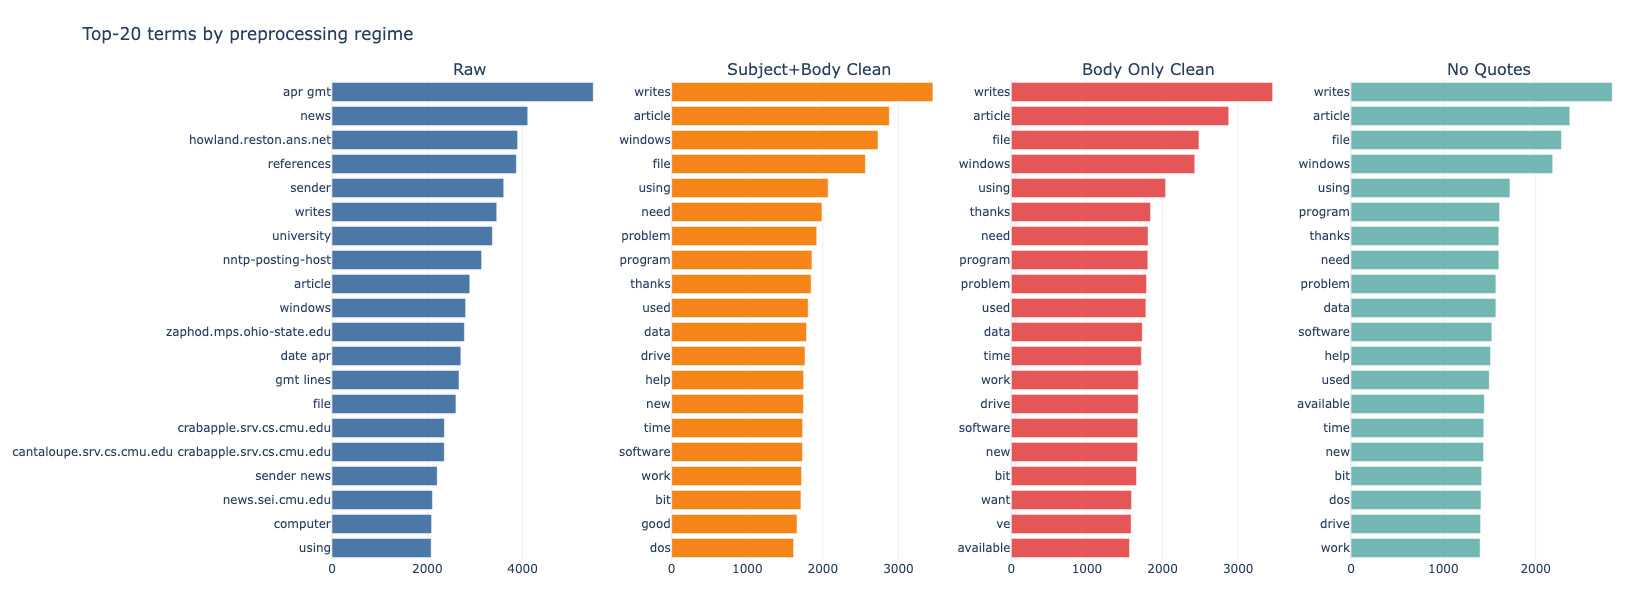

In [90]:
# visual

top_n_plot = 20
regime_labels = {
    "text_raw": "Raw",
    "text_subject_body_clean": "Subject+Body Clean",
    "text_body_only_clean": "Body Only Clean",
    "text_subject_body_no_quotes": "No Quotes",
}

fig = make_subplots(
    rows=1, cols=4,
    subplot_titles=list(regime_labels.values()),
    shared_xaxes=False,
)

colors = px.colors.qualitative.T10

for i, (col, label) in enumerate(regime_labels.items(), start=1):
    df_top = top_terms_by_regime[col].head(top_n_plot).sort_values("count")
    fig.add_trace(
        go.Bar(
            x=df_top["count"],
            y=df_top["term"],
            orientation="h",
            marker_color=colors[i - 1],
            showlegend=False,
        ),
        row=1, col=i,
    )

fig.update_layout(
    title="Top-20 terms by preprocessing regime",
    height=600,
    template="plotly_white",
    margin=dict(t=80, b=40, l=120, r=20),
)
fig.show()

In [91]:
# top tf-idf terms by class

def get_top_tfidf_terms_by_class(df, text_col, label_col="label", params=None, top_n=15):
    if params is None:
        params = {}

    vectorizer = TfidfVectorizer(**params)
    X = vectorizer.fit_transform(df[text_col].fillna(""))
    terms = np.array(vectorizer.get_feature_names_out())

    rows = []

    for label in sorted(df[label_col].unique()):
        label_mask = df[label_col].eq(label).values
        class_mean_tfidf = np.asarray(X[label_mask].mean(axis=0)).ravel()

        top_idx = class_mean_tfidf.argsort()[::-1][:top_n]

        for rank, idx in enumerate(top_idx, start=1):
            rows.append({
                "text_regime": text_col,
                "label": label,
                "rank": rank,
                "term": terms[idx],
                "mean_tfidf": class_mean_tfidf[idx],
            })

    return pd.DataFrame(rows)

In [92]:
# i choose 2 regmes to show max contrast 
top_class_terms_raw = get_top_tfidf_terms_by_class(
    df_preprocessed,
    text_col="text_raw",
    params=vocab_eda_vectorizer_params,
    top_n=15,
)

top_class_terms_clean = get_top_tfidf_terms_by_class(
    df_preprocessed,
    text_col="text_subject_body_clean",
    params=vocab_eda_vectorizer_params,
    top_n=15,
)

def display_terms_as_lists(top_terms_df):
    return (
        top_terms_df
        .sort_values(["label", "rank"])
        .groupby("label")["term"]
        .apply(lambda terms: ", ".join(terms))
        .reset_index(name="top_terms")
    )


print("Top class-associated TF-IDF terms: RAW")
display(display_terms_as_lists(top_class_terms_raw))

print("Top class-associated TF-IDF terms: SUBJECT + BODY CLEAN")
display(display_terms_as_lists(top_class_terms_clean))

Top class-associated TF-IDF terms: RAW


,label,top_terms
0,comp.graphics,"comp.graphics, newsgroups comp.graphics, graph..."
1,comp.os.ms-windows.misc,"windows, comp.os.ms-windows.misc, newsgroups c..."
2,comp.sys.ibm.pc.hardware,"comp.sys.ibm.pc.hardware, newsgroups comp.sys...."
3,comp.sys.mac.hardware,"comp.sys.mac.hardware, newsgroups comp.sys.mac..."
4,comp.windows.x,"comp.windows.x, newsgroups comp.windows.x, win..."
5,sci.crypt,"sci.crypt, clipper, key, netcom.com, encryptio..."
6,sci.electronics,"sci.electronics, newsgroups sci.electronics, s..."


Top class-associated TF-IDF terms: SUBJECT + BODY CLEAN


,label,top_terms
0,comp.graphics,"graphics, image, thanks, images, files, file, ..."
1,comp.os.ms-windows.misc,"windows, dos, file, files, driver, microsoft, ..."
2,comp.sys.ibm.pc.hardware,"drive, card, ide, scsi, controller, bus, thank..."
3,comp.sys.mac.hardware,"mac, apple, drive, monitor, centris, duo, quad..."
4,comp.windows.x,"window, motif, server, xterm, x11r5, widget, a..."
5,sci.crypt,"clipper, key, encryption, chip, government, ke..."
6,sci.electronics,"writes, power, circuit, article, used, need, r..."


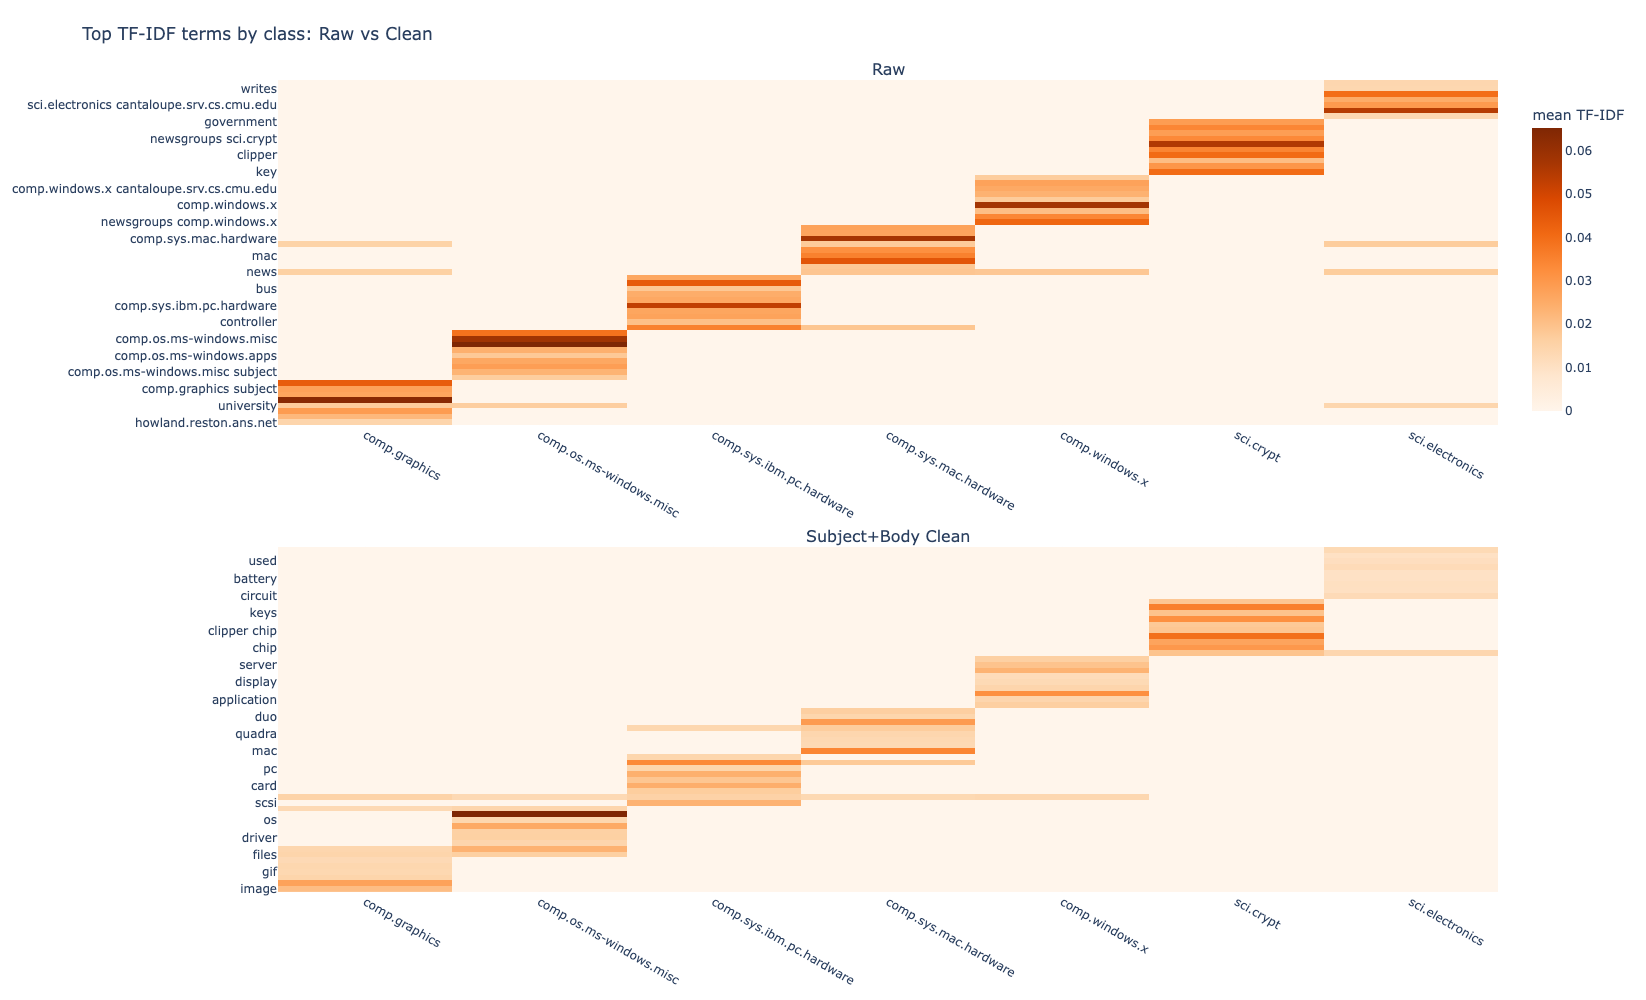

In [93]:
def build_tfidf_heatmap_data(top_terms_df, top_n=12):
    """Pivot top TF-IDF terms into a heatmap matrix (classes × terms)."""
    # Take top_n terms per class by rank
    filtered = top_terms_df[top_terms_df["rank"] <= top_n].copy()
    pivot = filtered.pivot_table(
        index="label", columns="term", values="mean_tfidf", aggfunc="mean"
    ).fillna(0)
    return pivot

pivot_raw   = build_tfidf_heatmap_data(top_class_terms_raw,   top_n=12)
pivot_clean = build_tfidf_heatmap_data(top_class_terms_clean, top_n=12)

# Union of all terms for shared column space
all_terms = list(dict.fromkeys(
    list(pivot_raw.columns) + list(pivot_clean.columns)
))
pivot_raw   = pivot_raw.reindex(columns=all_terms, fill_value=0)
pivot_clean = pivot_clean.reindex(columns=all_terms, fill_value=0)

top_n_plot = 10

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=["Raw", "Subject+Body Clean"],
    vertical_spacing=0.15,
)

for row_idx, (top_terms_df, label) in enumerate(
    [(top_class_terms_raw, "Raw"), (top_class_terms_clean, "Clean")], start=1
):
    # Take only top_n terms per class (by rank), keep them class-specific
    filtered = top_terms_df[top_terms_df["rank"] <= top_n_plot].copy()
    
    pivot = filtered.pivot_table(
        index="term", columns="label", values="mean_tfidf", aggfunc="mean"
    ).fillna(0)
    
    # Sort terms by which class they belong to (group by dominant class)
    pivot["dominant_class"] = pivot.idxmax(axis=1)
    pivot = pivot.sort_values("dominant_class").drop(columns="dominant_class")

    fig.add_trace(
        go.Heatmap(
            z=pivot.values,
            x=pivot.columns.tolist(),
            y=pivot.index.tolist(),
            colorscale="Oranges",
            showscale=(row_idx == 1),
            colorbar=dict(title="mean TF-IDF", len=0.4, y=0.78),
            zmin=0,
        ),
        row=row_idx, col=1,
    )

fig.update_layout(
    title="Top TF-IDF terms by class: Raw vs Clean",
    height=1000,
    width=850,
    template="plotly_white",
    margin=dict(t=80, b=60, l=160, r=80),
)
fig.update_xaxes(tickangle=30)
fig.show()

Running POS tagging... (~1-2 min)


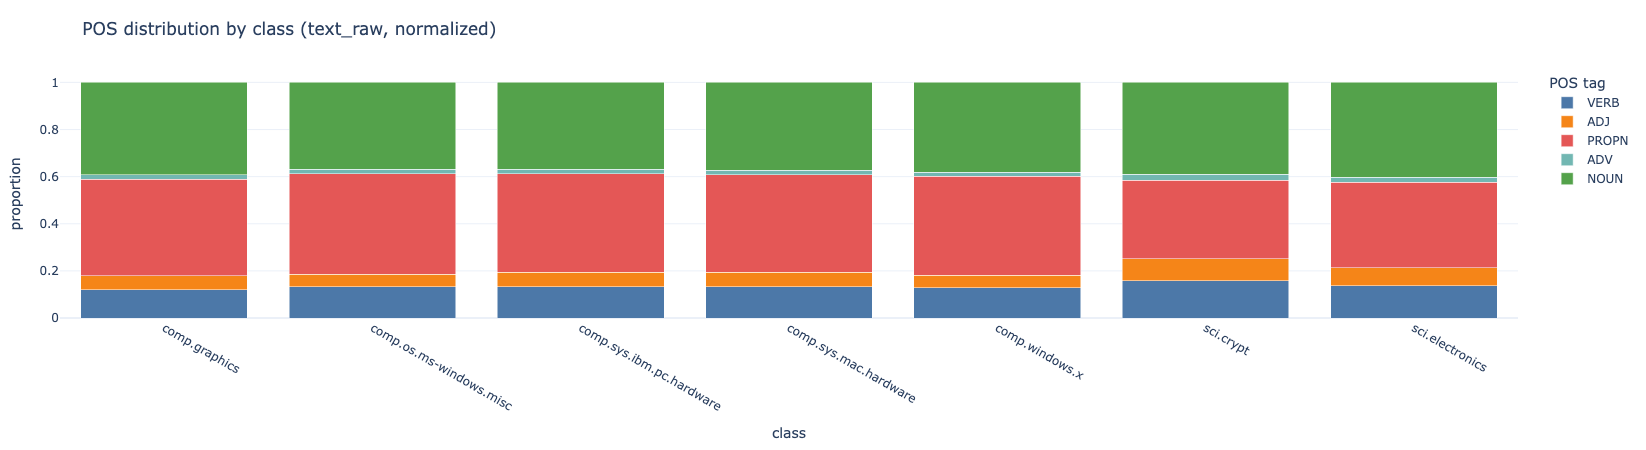

In [94]:
# POS analysis by class for text_raw

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

POS_KEEP = {"NOUN", "VERB", "ADJ", "ADV", "PROPN"}

def get_pos_shares(text):
    doc = nlp(text[:5000])
    counts = {pos: 0 for pos in POS_KEEP}
    total = 0
    for token in doc:
        if token.pos_ in POS_KEEP and not token.is_stop and not token.is_punct:
            counts[token.pos_] += 1
            total += 1
    if total > 0:
        return {k: v / total for k, v in counts.items()}
    return counts

print("Running POS tagging... (~1-2 min)")
pos_results = df_preprocessed["text_raw"].apply(get_pos_shares)
pos_df = pd.DataFrame(pos_results.tolist())
pos_df["label"] = df_preprocessed["label"].values

pos_by_class = (
    pos_df.groupby("label")[list(POS_KEEP)]
    .mean()
    .reset_index()
)

pos_long = pos_by_class.melt(id_vars="label", var_name="POS", value_name="share")

fig = px.bar(
    pos_long,
    x="label",
    y="share",
    color="POS",
    barmode="stack",
    color_discrete_sequence=px.colors.qualitative.T10,
    title="POS distribution by class (text_raw, normalized)",
    labels={"share": "proportion", "label": "class"},
    height=450,
    template="plotly_white",
)
fig.update_layout(
    xaxis_tickangle=30,
    margin=dict(t=70, b=100, l=60, r=20),
    legend_title="POS tag",
)
fig.show()

### Vocabulary diagnostic findings

The vocabulary diagnostic shows that raw and cleaned text representations differ not only in length, but also in the type of lexical signal they expose.

In the raw representation, frequent terms include metadata and Usenet-format artifacts and other generic reply or source-related tokens. This supports the earlier artifact audit: raw text contains source and formatting cues that may become predictive features.

For readability, a small set of diagnostic stop words was added for the vocabulary plots. This list includes high-frequency non-informative tokens such as `ax`, `max`, generic discourse words, and masking placeholders such as `email` and `url`. These stop words are used for exploratory vocabulary inspection.

The strongest distinctive lexical signal appears in `sci.crypt`, where terms such as `clipper`, `key`, `encryption`, `chip`, and `government` dominate. This supports the expectation that `sci.crypt` may be relatively easy for lexical classifiers.

Other categories show more overlap which suggest likely future confusion pairs for model evaluation.

Overall, the vocabulary analysis supports using TF-IDF as a strong classical baseline: the task has clear lexical topic signals, but also meaningful overlap between related technical categories.

POS distribution is nearly uniform across all classes (~40% nouns, ~35% proper nouns, ~15% verbs), confirming that classes share a common discourse style. Topic separation is driven by lexical content — which words appear — rather than grammatical structure. This supports the use of bag-of-words and TF-IDF approaches as appropriate baselines.

### Vocab implications for modelling

These findings motivate a TF-IDF + Logistic Regression baseline. TF-IDF is appropriate because many categories are distinguished by domain-specific vocabulary, while Logistic Regression allows later inspection of class-weighted features.

However, the vocabulary analysis also shows why preprocessing-regime comparison is essential. The raw representation contains direct label leakage and cannot be used as a fair modelling input. The metadata-rich no-leakage representation still contains many shortcut-prone source and routing features. Therefore, the main baseline should be evaluated on `text_subject_body_clean`, with `text_metadata_rich_no_leakage`, `text_body_only_clean`, and `text_subject_body_no_quotes` used as diagnostic comparisons.

Aggregate accuracy will not be enough. Some classes have highly distinctive terms, while others share substantial technical vocabulary. Later evaluation should therefore include macro F1, per-class F1, confusion matrices, feature inspection, and targeted error analysis for expected overlap pairs.

## <a id="category-overlap-and-expected-confusion-pairs"></a>Category overlap and expected confusion pairs

This section examines which categories are likely to be confused before training any classifier.

I use TF-IDF vector space diagnostics to estimate how close the class vocabularies are after preprocessing. If two classes have similar centroid vectors or share many high-weight terms, later confusion between them may reflect genuine topic overlap rather than only model failure.

The main analysis uses `text_subject_body_clean`, because this is the primary cleaned representation. The raw representation was already shown to contain metadata and source artifacts, so the cleaned representation is more relevant for estimating semantic category overlap.

In [95]:
overlap_text_col = "text_subject_body_clean"

tfidf_overlap_vectorizer = TfidfVectorizer(**vocab_eda_vectorizer_params)

X_overlap = tfidf_overlap_vectorizer.fit_transform(
    df_preprocessed[overlap_text_col].fillna("")
)

overlap_terms = np.array(tfidf_overlap_vectorizer.get_feature_names_out())

X_overlap.shape

(6937, 20000)

In [96]:
# class centroid cosine similarity
labels_sorted = sorted(df_preprocessed["label"].unique())

class_centroids = []

for label in labels_sorted:
    mask = df_preprocessed["label"].eq(label).values
    centroid = np.asarray(X_overlap[mask].mean(axis=0)).flatten() 
    class_centroids.append(centroid)

class_centroids = np.vstack(class_centroids)

centroid_similarity = cosine_similarity(class_centroids)

centroid_similarity_df = pd.DataFrame(
    centroid_similarity,
    index=labels_sorted,
    columns=labels_sorted,
)

centroid_similarity_df.style.format("{:.3f}")

,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,sci.crypt,sci.electronics
comp.graphics,1.000,0.530,0.480,0.438,0.560,0.334,0.491
comp.os.ms-windows.misc,0.530,1.000,0.533,0.419,0.519,0.271,0.395
comp.sys.ibm.pc.hardware,0.480,0.533,1.000,0.618,0.401,0.293,0.506
comp.sys.mac.hardware,0.438,0.419,0.618,1.000,0.372,0.303,0.500
comp.windows.x,0.560,0.519,0.401,0.372,1.000,0.301,0.417
sci.crypt,0.334,0.271,0.293,0.303,0.301,1.000,0.416
sci.electronics,0.491,0.395,0.506,0.500,0.417,0.416,1.000


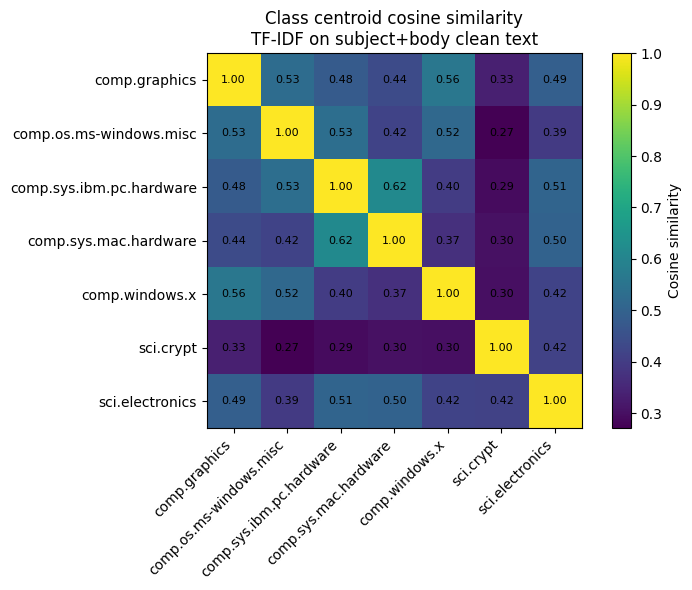

In [97]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(centroid_similarity_df.values)

ax.set_xticks(np.arange(len(labels_sorted)))
ax.set_yticks(np.arange(len(labels_sorted)))

ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticklabels(labels_sorted)

ax.set_title("Class centroid cosine similarity\nTF-IDF on subject+body clean text")

fig.colorbar(im, ax=ax, label="Cosine similarity")

for i in range(len(labels_sorted)):
    for j in range(len(labels_sorted)):
        value = centroid_similarity_df.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [98]:
# diagnostic 2D projection

svd_50 = TruncatedSVD(n_components=50, random_state=42)
normalizer = Normalizer(copy=False)

lsa_pipeline = make_pipeline(svd_50, normalizer)

X_lsa_50 = lsa_pipeline.fit_transform(X_overlap)

X_lsa_50.shape

(6937, 50)

In [99]:
reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.1,
        metric="cosine",
        random_state=42,
    )

X_projection_2d = reducer.fit_transform(X_lsa_50)
projection_method = "UMAP"

    
umap_df = pd.DataFrame({
    "x": X_projection_2d[:, 0],
    "y": X_projection_2d[:, 1],
    "label": df_preprocessed["label"].values,
    "text": df_preprocessed["text_subject_body_clean"].str[:120].values,
})

/Users/avr/Library/Python/3.13/lib/python/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [100]:
# UMAP projection is used only as an exploratory visualization
# it can reveal local structure and possible overlap regions, but it does not provide a reliable quantitative measure of class separability
# centroid similarity table is used as the main quantitative diagnostic in this section

fig = px.scatter(
    umap_df,
    x="x",
    y="y",
    color="label",
    hover_data={"x": False, "y": False, "text": True, "label": True},
    color_discrete_sequence=px.colors.qualitative.T10,
    title="UMAP projection of TF-IDF/SVD text space<br><sup>text_subject_body_clean</sup>",
    labels={"x": "Component 1", "y": "Component 2", "label": "class"},
    height=600,
    template="plotly_white",
    opacity=0.6,
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(
    margin=dict(t=80, b=40, l=40, r=40),
    legend_title="class",
)
fig.show()

In [101]:
# compare centroid cimilarity across regimes

def compute_centroid_pair_similarities(df, text_col, label_col="label", vectorizer_params=None):
    if vectorizer_params is None:
        vectorizer_params = {}

    vectorizer = TfidfVectorizer(**vectorizer_params)
    X = vectorizer.fit_transform(df[text_col].fillna(""))

    labels = sorted(df[label_col].unique())

    centroids = []
    for label in labels:
        mask = df[label_col].eq(label).values
        centroid = np.asarray(X[mask].mean(axis=0)).flatten()
        centroids.append(centroid)


    centroids = np.vstack(centroids)
    sim = cosine_similarity(centroids)

    rows = []
    for i, j in itertools.combinations(range(len(labels)), 2):
        rows.append({
            "text_regime": text_col,
            "class_a": labels[i],
            "class_b": labels[j],
            "centroid_cosine_similarity": sim[i, j],
        })

    return pd.DataFrame(rows)


centroid_pairs_all_regimes = pd.concat(
    [
        compute_centroid_pair_similarities(
            df_preprocessed,
            text_col=col,
            vectorizer_params=vocab_eda_vectorizer_params,
        )
        for col in text_regimes
    ],
    ignore_index=True,
)

display(
    centroid_pairs_all_regimes
    .sort_values(["text_regime", "centroid_cosine_similarity"], ascending=[True, False])
    .groupby("text_regime")
    .head(5)
    .style.format({"centroid_cosine_similarity": "{:.3f}"})
)

,text_regime,class_a,class_b,centroid_cosine_similarity
74,text_body_only_clean,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,0.658
66,text_body_only_clean,comp.graphics,comp.windows.x,0.596
63,text_body_only_clean,comp.graphics,comp.os.ms-windows.misc,0.580
69,text_body_only_clean,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,0.580
71,text_body_only_clean,comp.os.ms-windows.misc,comp.windows.x,0.554
32,text_metadata_rich_no_leakage,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,0.711
24,text_metadata_rich_no_leakage,comp.graphics,comp.windows.x,0.678
21,text_metadata_rich_no_leakage,comp.graphics,comp.os.ms-windows.misc,0.669
26,text_metadata_rich_no_leakage,comp.graphics,sci.electronics,0.658
38,text_metadata_rich_no_leakage,comp.sys.mac.hardware,sci.electronics,0.655


In [102]:
# short names
centroid_pairs_all_regimes["pair"] = (
    centroid_pairs_all_regimes["class_a"].str.replace("comp.", "", regex=False)
    .str.replace("sci.", "", regex=False)
    + " vs\n" +
    centroid_pairs_all_regimes["class_b"].str.replace("comp.", "", regex=False)
    .str.replace("sci.", "", regex=False)
)

regime_order = [
    "text_raw",
    "text_subject_body_clean",
    "text_body_only_clean",
    "text_subject_body_no_quotes",
]
regime_labels = {
    "text_raw": "Raw",
    "text_subject_body_clean": "Subject+Body Clean",
    "text_body_only_clean": "Body Only Clean",
    "text_subject_body_no_quotes": "No Quotes",
}
centroid_pairs_all_regimes["regime_label"] = centroid_pairs_all_regimes["text_regime"].map(regime_labels)

# Top-6 pairsby similarity from one regime
top_pairs = (
    centroid_pairs_all_regimes[centroid_pairs_all_regimes["text_regime"] == "text_subject_body_clean"]
    .nlargest(6, "centroid_cosine_similarity")["pair"]
    .tolist()
)

plot_df = centroid_pairs_all_regimes[centroid_pairs_all_regimes["pair"].isin(top_pairs)]

fig = px.bar(
    plot_df,
    y="pair",          
    x="centroid_cosine_similarity",  
    color="regime_label",
    barmode="group",
    orientation="h",    
    category_orders={"regime_label": list(regime_labels.values())},
    color_discrete_sequence=px.colors.qualitative.T10,
    title="Centroid cosine similarity for top confusable class pairs<br><sup>by preprocessing regime</sup>",
    labels={"centroid_cosine_similarity": "cosine similarity", "pair": "class pair", "regime_label": "regime"},
    height=500,
    template="plotly_white",
)
fig.update_layout(
    margin=dict(t=80, b=40, l=200, r=20),
    xaxis_range=[0, 0.75],
)

In [103]:
# shared top terms between class pairs
def get_top_terms_for_label(top_terms_df, label, top_n=20):
    return (
        top_terms_df[top_terms_df["label"] == label]
        .sort_values("rank")
        .head(top_n)["term"]
        .tolist()
    )


def shared_top_terms_for_pairs(top_terms_df, pairs_df, top_n_terms=20, top_n_pairs=10):
    rows = []

    for _, row in pairs_df.head(top_n_pairs).iterrows():
        class_a = row["class_a"]
        class_b = row["class_b"]

        terms_a = set(get_top_terms_for_label(top_terms_df, class_a, top_n=top_n_terms))
        terms_b = set(get_top_terms_for_label(top_terms_df, class_b, top_n=top_n_terms))

        shared = sorted(terms_a & terms_b)

        rows.append({
            "class_a": class_a,
            "class_b": class_b,
            "centroid_cosine_similarity": row["centroid_cosine_similarity"],
            "n_shared_top_terms": len(shared),
            "shared_top_terms": ", ".join(shared),
        })

    return pd.DataFrame(rows)
    
pair_similarity_df = (
    centroid_pairs_all_regimes[
        centroid_pairs_all_regimes["text_regime"] == "text_subject_body_clean"
    ]
    .nlargest(10, "centroid_cosine_similarity")
    .reset_index(drop=True)
)


shared_terms_pairs = shared_top_terms_for_pairs(
    top_class_terms_clean,
    pair_similarity_df,
    top_n_terms=20,
    top_n_pairs=10,
)

shared_terms_pairs.style.format({"centroid_cosine_similarity": "{:.3f}",})

,class_a,class_b,centroid_cosine_similarity,n_shared_top_terms,shared_top_terms
0,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,0.618,4,"drive, monitor, scsi, thanks"
1,comp.graphics,comp.windows.x,0.560,3,"file, program, thanks"
2,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,0.533,3,"card, dos, thanks"
3,comp.graphics,comp.os.ms-windows.misc,0.530,4,"file, files, program, thanks"
4,comp.os.ms-windows.misc,comp.windows.x,0.519,4,"file, program, thanks, using"
5,comp.sys.ibm.pc.hardware,sci.electronics,0.506,2,"help, thanks"
6,comp.sys.mac.hardware,sci.electronics,0.500,1,thanks
7,comp.graphics,sci.electronics,0.491,3,"help, need, thanks"
8,comp.graphics,comp.sys.ibm.pc.hardware,0.480,2,"help, thanks"
9,comp.graphics,comp.sys.mac.hardware,0.438,1,thanks


### Category overlap findings

The category-overlap diagnostic suggests that the classes are not randomly mixed in TF-IDF space. The UMAP projection shows several partially separated regions, especially for more distinctive categories such as `sci.crypt`. At the same time, related technical categories still overlap, which suggests that some later model confusions should be expected.

The centroid similarity analysis identifies the most lexically similar class pair as `comp.sys.ibm.pc.hardware` and `comp.sys.mac.hardware` with cosine similarity of 0.621. This is expected because both categories discuss hardware topics and share terms such as `drive`, `monitor`, and `scsi`.

Other likely confusion pairs include:

- `comp.graphics` vs `comp.windows.x`, due to shared software/interface vocabulary;
- `comp.os.ms-windows.misc` vs `comp.windows.x`, due to overlapping Windows/window-system terminology;
- `comp.os.ms-windows.misc` vs `comp.sys.ibm.pc.hardware`, due to shared driver, card, and system-configuration language;
- `comp.sys.ibm.pc.hardware` vs `sci.electronics`, due to broader hardware/electronics vocabulary.

Some of the shared top terms, such as `thanks`, `help`, `file`, or `program`, are generic forum or technical-support terms rather than strong semantic class markers. Therefore, centroid similarity should be interpreted as a diagnostic signal, not as proof that two classes are truly indistinguishable.

The comparison across preprocessing regimes is also informative. The same expected confusion pairs remain near the top across raw, cleaned, body-only, and no-quotes representations. This suggests that the overlap is not only caused by raw metadata artifacts; it also reflects genuine topical proximity between related technical categories.

Overall, this section defines the expected confusion pairs for later evaluation. If the baseline or transformer confuses these pairs, the errors may reflect real category overlap rather than only model weakness. Unexpected confusions outside these pairs will be especially important to inspect during error analysis.

## <a id="evaluation-slices-derived-from-eda"></a>Evaluation slices derived from EDA

### Technical-token preservation decisions

Because this dataset contains technical forum posts, preprocessing and vectorization should not remove all unusual-looking tokens by default. Tokens such as `x11`, `scsi`, `dos`, `vga`, `jpeg`, `rsa`, `3d`, `c++`, software names, version-like strings, and hardware terms may carry genuine topic signal.

For this reason, the preprocessing removes structural artifacts such as source/routing headers, raw emails, URLs, embedded `Newsgroups` lines, and separator lines, but it does not aggressively remove numbers, abbreviations, or technical punctuation inside tokens.

The vocabulary diagnostic also uses a token pattern designed to keep many technical tokens containing digits, hyphens, underscores, plus signs, or dots. A small custom stop-word list is used only for diagnostic readability, mainly to suppress high-frequency non-informative terms and placeholders such as `email` and `url`.

This decision supports the main modelling goal: reduce shortcut-prone artifacts without destroying domain-specific vocabulary that may legitimately distinguish the technical categories.

### Evaluation slices derived from EDA

The EDA identified several properties that may affect model performance: document length, quote density, residual artifact structure, and semantically close category pairs.

Before training models, I define these as evaluation slices. This makes later error analysis more disciplined: instead of inspecting only the examples that look interesting after seeing the results, the notebook predefines the text conditions that should be checked.

These slices are not used to remove data from the main experiment. They are diagnostic groups for later evaluation.

### Evaluation slice policy

Length is defined separately for each text regime, because preprocessing changes document length. This is especially important for `text_body_only_clean` and `text_subject_body_no_quotes`, where some documents may become very short after subject or quote removal.

Quote density and artifact density are defined as source-level document properties based on the original raw post. They are not recalculated as regime-specific quality measures, because quote removal and artifact reduction are part of the experimental manipulation. The purpose is to ask whether models behave differently on documents that were originally quote-heavy or artifact-heavy.

Expected confusion pairs are not used as a row-level slice because most classes belong to at least one expected-overlap pair. Instead, these pairs will be used after prediction to interpret confusion matrices and classify errors as expected semantic overlap versus unexpected confusion.

In [104]:
# fix
df_preprocessed["structural_line_ratio"] = df_artifacts["structural_line_ratio"].values

df_slices = df_preprocessed.copy()

#main_text_col = "text_subject_body_clean"

In [105]:
# lenght slices 

def assign_length_slice(word_count):
    if word_count < 20:
        return "very_short_<20"
    elif word_count < 80:
        return "short_20_79"
    elif word_count < 256:
        return "medium_80_255"
    elif word_count < 512:
        return "long_256_511"
    else:
        return "very_long_512plus"


length_slice_order = [
    "very_short_<20",
    "short_20_79",
    "medium_80_255",
    "long_256_511",
    "very_long_512plus",
]


for col in text_regimes:
    df_preprocessed[f"{col}_length_slice"] = (
        df_preprocessed[f"{col}_word_count"]
        .fillna(0)
        .apply(assign_length_slice)
    )

length_slice_by_regime = []

for col in text_regimes:
    counts = (
        df_preprocessed[f"{col}_length_slice"]
        .value_counts()
        .reindex(length_slice_order, fill_value=0)
        .rename_axis("length_slice")
        .reset_index(name="count")
    )

    counts["share"] = counts["count"] / len(df_preprocessed)
    counts["text_regime"] = col

    length_slice_by_regime.append(counts)

length_slice_by_regime = pd.concat(length_slice_by_regime, ignore_index=True)

In [106]:
# pivot 
length_slice_pivot = (
    length_slice_by_regime
    .pivot(index="length_slice", columns="text_regime", values="share")
    .reindex(length_slice_order)
)

display(length_slice_pivot.style.format("{:.1%}"))

text_regime,text_body_only_clean,text_metadata_rich_no_leakage,text_raw,text_subject_body_clean,text_subject_body_no_quotes
length_slice,,,,,
very_short_<20,3.2%,0.0%,0.0%,2.1%,2.8%
short_20_79,27.9%,9.5%,9.7%,26.3%,38.8%
medium_80_255,51.8%,64.1%,64.6%,53.5%,46.9%
long_256_511,12.8%,20.8%,20.0%,13.6%,8.0%
very_long_512plus,4.4%,5.5%,5.7%,4.5%,3.5%


In [107]:
# quote density is a source-level property based on the original raw post.

if "body_quote_line_ratio" not in df_preprocessed.columns:
    df_preprocessed["body_line_count"] = df_preprocessed["text"].apply(get_body_line_count)
    df_preprocessed["body_quote_line_count"] = df_preprocessed["text"].apply(count_quote_lines_in_body)

    df_preprocessed["body_quote_line_ratio"] = (
        df_preprocessed["body_quote_line_count"] /
        df_preprocessed["body_line_count"].replace(0, np.nan)
    ).fillna(0)


def assign_quote_slice(ratio):
    if ratio == 0:
        return "no_detected_quotes"
    elif ratio < 0.25:
        return "low_quote_<25%"
    elif ratio < 0.50:
        return "quote_heavy_25_49%"
    else:
        return "quote_dominated_50%plus"


quote_slice_order = [
    "no_detected_quotes",
    "low_quote_<25%",
    "quote_heavy_25_49%",
    "quote_dominated_50%plus",
]


df_preprocessed["quote_density_slice"] = (
    df_preprocessed["body_quote_line_ratio"]
    .apply(assign_quote_slice)
)

In [108]:
# artifact density slices 

if "structural_line_ratio" in df_slices.columns:
    df_slices["artifact_density_slice"] = pd.cut(
        df_slices["structural_line_ratio"],
        bins=[-0.001, 0.05, 0.20, 1.0],
        labels=[
            "low_structural_artifacts",
            "medium_structural_artifacts",
            "high_structural_artifacts",
        ],
    )
else:
    df_slices["artifact_density_slice"] = "not_available"


artifact_slice_summary = (
    df_slices["artifact_density_slice"]
    .value_counts(dropna=False)
    .rename_axis("artifact_density_slice")
    .reset_index(name="count")
)

artifact_slice_summary["share"] = artifact_slice_summary["count"] / len(df_slices)

display(artifact_slice_summary.style.format({"share": "{:.1%}"}))

,artifact_density_slice,count,share
0,low_structural_artifacts,3668,52.9%
1,medium_structural_artifacts,1776,25.6%
2,high_structural_artifacts,1493,21.5%


In [109]:
quote_slice_summary = (
    df_preprocessed["quote_density_slice"]
    .value_counts()
    .reindex(quote_slice_order, fill_value=0)
    .rename_axis("quote_density_slice")
    .reset_index(name="count")
)

quote_slice_summary["share"] = quote_slice_summary["count"] / len(df_preprocessed)

display(quote_slice_summary.style.format({"share": "{:.1%}"}))

,quote_density_slice,count,share
0,no_detected_quotes,4117,59.3%
1,low_quote_<25%,1027,14.8%
2,quote_heavy_25_49%,1294,18.7%
3,quote_dominated_50%plus,499,7.2%


In [110]:
# by class quiote density
quote_by_class = (
    pd.crosstab(
        df_preprocessed["label"],
        df_preprocessed["quote_density_slice"],
        normalize="index"
    )
    .reindex(columns=quote_slice_order, fill_value=0)
    .sort_index()
)

display(quote_by_class.style.format("{:.1%}"))

quote_density_slice,no_detected_quotes,low_quote_<25%,quote_heavy_25_49%,quote_dominated_50%plus
label,,,,
comp.graphics,70.7%,12.3%,13.0%,4.1%
comp.os.ms-windows.misc,55.2%,12.7%,21.3%,10.7%
comp.sys.ibm.pc.hardware,67.2%,11.3%,13.6%,7.9%
comp.sys.mac.hardware,59.1%,12.1%,21.0%,7.9%
comp.windows.x,74.9%,11.3%,10.2%,3.6%
sci.crypt,36.1%,28.2%,28.3%,7.4%
sci.electronics,52.7%,15.6%,23.0%,8.7%


In [111]:
# artifact density is a source-level property based on raw structural artifacts.

artifact_slice_order = [
    "low_structural_artifacts",
    "medium_structural_artifacts",
    "high_structural_artifacts",
]


df_preprocessed["artifact_density_slice"] = pd.cut(
    df_preprocessed["structural_line_ratio"],
    bins=[-0.001, 0.05, 0.20, 1.0],
    labels=artifact_slice_order,
)

# summary 
artifact_slice_summary = (
    df_preprocessed["artifact_density_slice"]
    .value_counts()
    .reindex(artifact_slice_order, fill_value=0)
    .rename_axis("artifact_density_slice")
    .reset_index(name="count")
)

artifact_slice_summary["share"] = artifact_slice_summary["count"] / len(df_preprocessed)

display(artifact_slice_summary.style.format({"share": "{:.1%}"}))

,artifact_density_slice,count,share
0,low_structural_artifacts,3668,52.9%
1,medium_structural_artifacts,1776,25.6%
2,high_structural_artifacts,1493,21.5%


In [112]:
#  artifact density by class
artifact_by_class = (
    pd.crosstab(
        df_preprocessed["label"],
        df_preprocessed["artifact_density_slice"],
        normalize="index"
    )
    .reindex(columns=artifact_slice_order, fill_value=0)
    .sort_index()
)

display(artifact_by_class.style.format("{:.1%}"))

artifact_density_slice,low_structural_artifacts,medium_structural_artifacts,high_structural_artifacts
label,,,
comp.graphics,63.8%,21.9%,14.3%
comp.os.ms-windows.misc,48.0%,24.4%,27.6%
comp.sys.ibm.pc.hardware,60.0%,21.1%,18.9%
comp.sys.mac.hardware,51.2%,26.5%,22.3%
comp.windows.x,65.4%,22.4%,12.2%
sci.crypt,35.1%,36.5%,28.4%
sci.electronics,46.9%,26.2%,26.8%


In [113]:
# check overview 
slice_overview_cols = (
    ["label"]
    + [f"{col}_length_slice" for col in text_regimes]
    + [
        "quote_density_slice",
        "artifact_density_slice",
    ]
)

display(df_preprocessed[slice_overview_cols].head())

,label,text_raw_length_slice,text_metadata_rich_no_leakage_length_slice,text_subject_body_clean_length_slice,text_body_only_clean_length_slice,text_subject_body_no_quotes_length_slice,quote_density_slice,artifact_density_slice
0,sci.crypt,very_long_512plus,very_long_512plus,long_256_511,long_256_511,medium_80_255,quote_dominated_50%plus,high_structural_artifacts
1,comp.sys.ibm.pc.hardware,long_256_511,long_256_511,long_256_511,long_256_511,medium_80_255,quote_dominated_50%plus,high_structural_artifacts
2,comp.sys.ibm.pc.hardware,medium_80_255,medium_80_255,medium_80_255,medium_80_255,medium_80_255,no_detected_quotes,low_structural_artifacts
3,comp.graphics,medium_80_255,medium_80_255,medium_80_255,medium_80_255,medium_80_255,quote_heavy_25_49%,high_structural_artifacts
4,comp.windows.x,short_20_79,short_20_79,very_short_<20,very_short_<20,very_short_<20,no_detected_quotes,low_structural_artifacts


### Evaluation slice summary

Preprocessing shifts document length in controlled ways. In `text_raw`, most posts are medium-length (80–255 words). After cleaning, the distribution shifts shorter: `text_subject_body_no_quotes` has the strongest effect, confirming that quote removal substantially changes input for posts whose content is mostly quoted context. `text_body_only_clean` produces the most very-short documents, expected when subject lines are removed from short posts.

Quote density is class-dependent: `sci.crypt` is the most quote-heavy (only 35.5% quote-free, 7.5% quote-dominated), followed by `sci.electronics` and `comp.os.ms-windows.misc`. `comp.graphics` and `comp.windows.x` are comparatively clean. Structural artifact density follows a similar pattern, with `sci.crypt` and `comp.os.ms-windows.misc` having the highest artifact shares.

These three dimensions — length, quote density, artifact density — will be used as evaluation slices after training to test whether model performance degrades on specific document subgroups. Expected confusion pairs (`comp.sys.ibm.pc.hardware` vs `comp.sys.mac.hardware`, etc.) will not be used as row-level slices but will guide confusion matrix interpretation to distinguish expected semantic overlap from unexpected model errors.

## <a id="eda-implications-for-modelling"></a>EDA implications for modelling

The EDA shows that this is a well-posed but non-trivial multiclass topic classification task. After identity-level duplicate handling, the dataset contains 6,937 unique-message posts across seven technical categories. The label distribution remains nearly balanced, with class counts ranging from 984 to 1,000 examples. This supports the use of stratified splits and macro F1 as the primary model-selection metric, because the main concern is reliable performance across all classes rather than majority-class accuracy.

The main validity issue is not class imbalance, but raw-text structure. The raw `20news-19997` archive preserves full Usenet-style records, including source and identity headers, routing/threading headers, content-adjacent headers, administrative headers, email-like strings, quoted replies, signatures, and explicit `Newsgroups` lines. In the raw representation, source/routing/header metadata appears in all documents, raw email-like strings appear in almost all documents, and at least one quoted line appears in 40.7% of documents.

The most important source-specific issue is direct `Newsgroups` label leakage. Unlike the previously inspected sklearn-packaged version, the raw archive preserves the top-level `Newsgroups` header in all documents. Since this field directly exposes the target category, `text_raw` is not a valid fair modelling input for topic classification. It is retained only as an audit reference and as a source for thread metadata extraction.

The preprocessing analysis therefore supports using multiple controlled text representations rather than a single cleaned dataset. `text_raw` is kept as an audit-only leakage-positive source representation. `text_metadata_rich_no_leakage` removes direct `Newsgroups` leakage, masks contacts/URLs, and removes encoded payloads while preserving most other raw Usenet structure. `text_subject_body_clean` is the main cleaned candidate: it removes source, routing, administrative, and leakage-style metadata while preserving the subject line and most body content. `text_body_only_clean` tests subject-line dependence, and `text_subject_body_no_quotes` tests dependence on quoted previous-message content.

The preprocessing regimes change document length in meaningful ways. `text_metadata_rich_no_leakage` retains essentially the full raw document length, because it is designed to preserve metadata-rich structure after removing direct label leakage and non-linguistic payloads. The main cleaned regime retains a median of 76% of raw words, the body-only regime retains 73%, and the quote-reduced regime retains 62%. This confirms that the cleaned regimes reduce metadata and quoted material substantially, but do not destroy the dataset. Very short documents are retained rather than filtered, as they are part of the task and may reveal where a representation lacks enough topic signal.

Residual artifact checks confirm that the updated preprocessing regimes behave as intended. In `text_metadata_rich_no_leakage`, raw email strings, raw URL/FTP strings, `Newsgroups` lines, and residual encoded payloads drop to 0.0%, while `Path` lines, header-like lines, quote lines, signatures, and separators remain common by design. In `text_subject_body_clean`, direct leakage, raw contacts, routing metadata, encoded payloads, and separator lines are removed, while quoted context is preserved. In `text_subject_body_no_quotes`, detected `>`-style quote lines drop to 0.0%. The cleaned representation should therefore be interpreted as artifact-reduced, not perfectly artifact-free.

The EDA also identifies rare special document types. Encoded payloads appear in 26 documents, or 0.37% of the dataset, and are removed or replaced in modelling-ready text regimes. FAQ/digest-like documents appear in 73 documents, or 1.05% of the dataset. A lightweight language/encoding review flags 16 documents, mostly overlapping with encoded payload cases. These documents are retained but flagged because they may affect length, vocabulary, similarity diagnostics, and later error analysis.

Vocabulary analysis shows that raw, metadata-rich, and cleaned representations expose different kinds of signal. In `text_raw`, class-associated TF-IDF terms include direct `Newsgroups` leakage and category names themselves, confirming that raw text is not suitable for fair modelling. In `text_metadata_rich_no_leakage`, direct label leakage is removed, but many shortcut-prone metadata and routing tokens remain. In `text_subject_body_clean`, meaningful class-specific lexical signals are preserved: for example, `sci.crypt` is strongly associated with terms such as `clipper`, `key`, `encryption`, `chip`, and `government`, while hardware, graphics, Windows, X Window, and electronics classes retain their own domain vocabulary.

At the same time, several categories share broad technical-support vocabulary such as `file`, `program`, `driver`, `card`, `drive`, `monitor`, `help`, and `thanks`, so aggregate accuracy alone will not be enough. POS analysis shows broadly similar grammatical structure across classes, with nouns and proper nouns dominating in all categories. This suggests that POS-level grammatical structure is unlikely to be the main driver of class separation; the more relevant signal appears to be lexical and domain-specific vocabulary.

A UMAP projection of the TF-IDF space shows partial cluster separation, consistent with the vocabulary analysis. This projection is used as an exploratory diagnostic rather than a quantitative separability measure.

The category-overlap diagnostic identifies expected confusion pairs before modelling. The strongest lexical overlap is between `comp.sys.ibm.pc.hardware` and `comp.sys.mac.hardware`, followed by related software/interface pairs such as `comp.graphics` vs `comp.windows.x` and `comp.os.ms-windows.misc` vs `comp.windows.x`. These expected overlaps will be used later to interpret confusion matrices: some errors may reflect genuine topic proximity rather than simple model failure.

The EDA also defines evaluation slices for later analysis. Length slices are regime-specific because preprocessing changes document length. Quote density, artifact density, encoded-payload flags, and FAQ/digest flags are source-level properties based on the original raw post. These slices will help test whether model performance is stable across short, long, quote-heavy, structurally messy, and special-format documents. They are diagnostic groups, not filtering rules.

Overall, the modelling strategy should compare performance across preprocessing regimes, not only across algorithms. A strong model should perform well on `text_subject_body_clean`, not only on metadata-rich text after direct label leakage has been removed. Later evaluation should report macro F1, per-class F1, confusion matrices, feature inspection, and slice-based performance. This will make it possible to distinguish useful topic classification from performance inflated by direct label leakage, raw-format artifacts, metadata shortcuts, or repeated quoted/threaded context.

## Save processed dataset and EDA outputs

In [114]:
PROJECT_ROOT = Path(".")
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_CONFIG_DIR = PROJECT_ROOT / "outputs" / "config"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

for directory in [
    DATA_PROCESSED_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_CONFIG_DIR,
    OUTPUT_FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# prepare datast for saving

df_export = df_preprocessed.copy()

if "original_index" not in df_export.columns:
    df_export["original_index"] = df_export.index

if "doc_id" not in df_export.columns:
    df_export["doc_id"] = [f"doc_{i:05d}" for i in range(len(df_export))]

# Put ID columns first for readability.
id_cols = ["doc_id", "original_index"]
other_cols = [col for col in df_export.columns if col not in id_cols]
df_export = df_export[id_cols + other_cols]

df_export.shape

(6937, 74)

In [115]:
# save

processed_parquet_path = DATA_PROCESSED_DIR / "20ng_tech_preprocessed.parquet"
processed_pickle_path = DATA_PROCESSED_DIR / "20ng_tech_preprocessed.pkl"

try:
    df_export.to_parquet(processed_parquet_path, index=False)
    saved_dataset_path = processed_parquet_path
    print(f"Saved processed dataset to: {processed_parquet_path}")
except Exception as e:
    print(f"Parquet save failed: {e}")
    df_export.to_pickle(processed_pickle_path)
    saved_dataset_path = processed_pickle_path
    print(f"Saved processed dataset to pickle instead: {processed_pickle_path}")

Saved processed dataset to: data/processed/20ng_tech_preprocessed.parquet


In [116]:
# Save a lightweight modelling input view.
# text_raw is retained for audit / thread metadata extraction,
# but excluded from fair modelling comparisons later.

core_modeling_cols = [
    "doc_id",
    "original_index",
    "filename",
    "message_id",
    "label",
    "label_id",
    "text",
    "text_raw",
    "text_metadata_rich_no_leakage",
    "text_subject_body_clean",
    "text_body_only_clean",
    "text_subject_body_no_quotes",
]

slice_cols = [
    "quote_density_slice",
    "artifact_density_slice",
]

length_slice_cols = [
    f"{col}_length_slice"
    for col in text_regimes
    if f"{col}_length_slice" in df_export.columns
]

diagnostic_cols = [
    "body_quote_line_ratio",
    "structural_line_ratio",
]

special_document_cols = [
    "has_uuencoded_payload",
    "uuencoded_line_count",
    "uuencoded_line_ratio",
    "has_faq_digest_signal",
    "is_multipart_series",
    "has_archive_name_header",
    "has_last_modified_header",
    "has_approved_header",
    "has_followup_to_poster",
    "subject_mentions_faq",
    "subject_mentions_digest_periodic",
    "subject_has_part_pattern",
    "language_or_encoding_review_flag",
    "non_ascii_char_ratio",
    "alphabetic_char_ratio",
    "english_stopword_token_ratio",
]

modeling_cols_to_save = [
    col for col in (
        core_modeling_cols
        + slice_cols
        + length_slice_cols
        + diagnostic_cols
        + special_document_cols
    )
    if col in df_export.columns
]

df_modeling_input = df_export[modeling_cols_to_save].copy()

modeling_input_path = DATA_PROCESSED_DIR / "20ng_tech_modeling_input.parquet"

try:
    df_modeling_input.to_parquet(modeling_input_path, index=False)
    print(f"Saved modelling input dataset to: {modeling_input_path}")
except Exception as e:
    fallback_path = DATA_PROCESSED_DIR / "20ng_tech_modeling_input.pkl"
    print(f"Parquet save failed: {e}")
    df_modeling_input.to_pickle(fallback_path)
    modeling_input_path = fallback_path
    print(f"Saved modelling input dataset to pickle instead: {fallback_path}")

print(df_modeling_input.shape)
display(df_modeling_input.head(3))

Saved modelling input dataset to: data/processed/20ng_tech_modeling_input.parquet
(6937, 37)


,doc_id,original_index,filename,message_id,label,label_id,text,text_raw,text_metadata_rich_no_leakage,text_subject_body_clean,...,has_last_modified_header,has_approved_header,has_followup_to_poster,subject_mentions_faq,subject_mentions_digest_periodic,subject_has_part_pattern,language_or_encoding_review_flag,non_ascii_char_ratio,alphabetic_char_ratio,english_stopword_token_ratio
0,doc_00000,0,15738,<1993Apr21.184113.3505@nmt.edu>,sci.crypt,5,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1573...,Xref: cantaloupe.srv.cs.cmu.edu sci.crypt:1573...,Xref: cantaloupe.srv.cs.cmu.edu :15738 :10080 ...,public awareness (wasRe: text of White House a...,...,False,False,False,False,False,False,False,0.0,0.753913,0.452101
1,doc_00001,1,60553,<1993Apr19.185511.2072@icd.teradyne.com>,comp.sys.ibm.pc.hardware,2,Newsgroups: comp.sys.ibm.pc.hardware\nPath: ca...,Newsgroups: comp.sys.ibm.pc.hardware\nPath: ca...,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Re: Recommendations for a Local BUS (Cache\n\n...,...,False,False,False,False,False,False,False,0.0,0.720565,0.344920
2,doc_00002,2,58989,<1pstlnINN4r5@srvr1.engin.umich.edu>,comp.sys.ibm.pc.hardware,2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Floppy file copying\n\nA silly question: I fre...,...,False,False,False,False,False,False,False,0.0,0.755968,0.258621


In [117]:
# save config

def make_json_safe(obj):
    """
    Convert common non-JSON-safe objects into serializable types.
    """
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if isinstance(obj, (set, tuple)):
        return list(obj)
    if isinstance(obj, Path):
        return str(obj)
    return obj


preprocessing_config = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "project": "NLP Capstone - 20 Newsgroups technical subset",
    "task": (
        "7-class technical forum topic classification with shortcut-learning, "
        "metadata-leakage, quote/thread-overlap, and preprocessing-regime audit"
    ),

    "data_source": {
        "source_name": "20news-19997 raw archive",
        "source_reason": (
            "The raw archive is used instead of the sklearn-packaged version because "
            "it preserves Message-ID / References-style thread metadata needed for "
            "leakage-aware split construction."
        ),
        "deduplication_policy": (
            "Identity-level duplicate handling using Message-ID. Duplicate groups with "
            "conflicting labels are removed; remaining duplicate Message-ID groups are "
            "deduplicated by keeping the first occurrence."
        ),
        "n_documents_after_deduplication": int(len(df_export)),
    },

    "target_column": "label",
    "id_column": "doc_id",
    "message_identity_column": "message_id",

    "categories": sorted(df_export["label"].unique().tolist()),

    "text_regimes": {
        "text_raw": (
            "Original raw archive text with full Usenet metadata, including direct "
            "Newsgroups label leakage. Retained for audit and thread metadata extraction; "
            "not used as a fair modelling input."
        ),
        "text_metadata_rich_no_leakage": (
            "Metadata-rich diagnostic representation. Removes Newsgroups lines, masks "
            "contacts/URLs, and removes encoded payloads while preserving most other "
            "raw Usenet structure, including routing/threading headers, quotes, and signatures."
        ),
        "text_subject_body_clean": (
            "Main cleaned candidate: keeps Subject + body; removes source/routing/"
            "administrative/leakage-style metadata; masks contacts/URLs; removes encoded "
            "payloads; keeps quoted context."
        ),
        "text_body_only_clean": (
            "Body-only ablation: removes all top-level headers including Subject; keeps "
            "cleaned body text and quoted context."
        ),
        "text_subject_body_no_quotes": (
            "Quote-reduced diagnostic: subject + body clean with classic >-style quoted "
            "lines removed."
        ),
    },

    "modeling_text_regimes": [
        "text_metadata_rich_no_leakage",
        "text_subject_body_clean",
        "text_body_only_clean",
        "text_subject_body_no_quotes",
    ],

    "excluded_from_fair_modelling": [
        "text_raw",
    ],

    "main_text_regime": "text_subject_body_clean",
    "metadata_rich_diagnostic_regime": "text_metadata_rich_no_leakage",

    "header_groups": {
        "label_leakage_headers": label_leakage_headers,
        "source_identity_headers": source_identity_headers,
        "routing_threading_headers": routing_threading_headers,
        "content_adjacent_headers": content_adjacent_headers,
        "administrative_headers": administrative_headers,
    },

    "slice_definitions": {
        "length_slices": {
            "very_short_<20": "word_count < 20",
            "short_20_79": "20 <= word_count < 80",
            "medium_80_255": "80 <= word_count < 256",
            "long_256_511": "256 <= word_count < 512",
            "very_long_512plus": "word_count >= 512",
            "note": "Length slices are regime-specific because preprocessing changes document length.",
        },
        "quote_density_slices": {
            "no_detected_quotes": "body_quote_line_ratio == 0",
            "low_quote_<25%": "0 < body_quote_line_ratio < 0.25",
            "quote_heavy_25_49%": "0.25 <= body_quote_line_ratio < 0.50",
            "quote_dominated_50%plus": "body_quote_line_ratio >= 0.50",
            "note": "Quote density is a source-level property based on the original raw post.",
        },
        "artifact_density_slices": {
            "low_structural_artifacts": "structural_line_ratio <= 0.05",
            "medium_structural_artifacts": "0.05 < structural_line_ratio <= 0.20",
            "high_structural_artifacts": "structural_line_ratio > 0.20",
            "note": "Artifact density is a source-level property based on the original raw post.",
        },
    },

    "special_document_flags": {
        "has_uuencoded_payload": (
            "Documents containing classic uuencoded blocks or uuencoded-like payload lines."
        ),
        "has_faq_digest_signal": (
            "Documents with FAQ, digest, periodic, archive-name, or multipart-reference signals."
        ),
        "is_multipart_series": (
            "Documents whose subject suggests a multi-part series, e.g. part N/M or part N of M."
        ),
        "language_or_encoding_review_flag": (
            "Lightweight review flag for unusual character/stopword patterns. In this dataset, "
            "it mainly overlaps with encoded payloads rather than meaningful multilingual variation."
        ),
    },

    "vocab_eda_vectorizer_params": {
        key: make_json_safe(value)
        for key, value in vocab_eda_vectorizer_params.items()
    },

    "notes": [
        "The raw 20news-19997 archive preserves complete Usenet metadata, including direct Newsgroups label leakage.",
        "text_raw is retained only for audit and thread metadata extraction, not fair modelling comparison.",
        "Fair modelling comparisons exclude text_raw and start from text_metadata_rich_no_leakage.",
        "text_metadata_rich_no_leakage removes direct label leakage but intentionally preserves other metadata-rich structure.",
        "text_subject_body_clean is the main cleaned representation for fair topic-classification modelling.",
        "Length slices are regime-specific because preprocessing changes document length.",
        "Quote density and artifact density are source-level properties based on raw text.",
        "Encoded payloads and FAQ/digest-like posts are retained but flagged for later error analysis.",
        "Expected confusion pairs are used later during confusion-matrix interpretation, not as row-level slices.",
        "Very short and very long documents are retained rather than filtered.",
        "Transformer truncation is handled later as model-specific preprocessing.",
    ],
}

config_path = OUTPUT_CONFIG_DIR / "eda_preprocessing_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(preprocessing_config, f, indent=2, ensure_ascii=False, default=make_json_safe)

print(f"Saved preprocessing config to: {config_path}")

Saved preprocessing config to: outputs/config/eda_preprocessing_config.json


In [118]:
# save env snapshot
environment_info = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "sklearn_version": sklearn.__version__,
}

environment_path = OUTPUT_CONFIG_DIR / "eda_environment_info.json"

with open(environment_path, "w", encoding="utf-8") as f:
    json.dump(environment_info, f, indent=2, ensure_ascii=False)

print(f"Saved environment info to: {environment_path}")

Saved environment info to: outputs/config/eda_environment_info.json


In [119]:
# save key summary tables 

def save_table_if_exists(variable_name, filename):
    """
    Save a DataFrame from globals() if it exists.
    """
    obj = globals().get(variable_name)

    if obj is None:
        print(f"Skipped {variable_name}: variable not found.")
        return None

    if not isinstance(obj, pd.DataFrame):
        print(f"Skipped {variable_name}: not a DataFrame.")
        return None

    path = OUTPUT_TABLES_DIR / filename
    obj.to_csv(path, index=True)
    print(f"Saved {variable_name} to: {path}")
    return path


tables_to_save = {
    # Basic EDA
    "length_impact": "preprocessing_length_impact.csv",
    "retention_summary": "preprocessing_word_retention_summary.csv",
    "class_length_impact": "preprocessing_class_length_impact.csv",

    # Artifact audit
    "artifact_overall": "artifact_overall.csv",
    "artifact_by_class": "artifact_by_class.csv",
    "artifact_intensity_selected": "artifact_intensity_selected.csv",
    "artifact_residuals": "artifact_residuals_after_preprocessing.csv",

    # Preprocessing / slices
    "length_slice_by_regime": "length_slice_by_regime.csv",
    "length_slice_pivot": "length_slice_pivot.csv",
    "quote_slice_summary": "quote_slice_summary.csv",
    "quote_by_class": "quote_density_by_class.csv",
    "artifact_slice_summary": "artifact_slice_summary.csv",
    "artifact_by_class": "artifact_density_by_class.csv",

    # Vocabulary / overlap
    "vocab_diagnostics": "vocab_diagnostics.csv",
    "raw_clean_term_comparison": "raw_clean_term_comparison.csv",
    "centroid_similarity_df": "centroid_similarity_matrix.csv",
    "pair_similarity_df": "centroid_pair_similarity.csv",
    "shared_terms_pairs": "shared_terms_for_top_pairs.csv",
}

saved_table_paths = {}

for variable_name, filename in tables_to_save.items():
    saved_path = save_table_if_exists(variable_name, filename)
    if saved_path is not None:
        saved_table_paths[variable_name] = str(saved_path)

Saved length_impact to: outputs/tables/preprocessing_length_impact.csv
Saved retention_summary to: outputs/tables/preprocessing_word_retention_summary.csv
Saved class_length_impact to: outputs/tables/preprocessing_class_length_impact.csv
Saved artifact_overall to: outputs/tables/artifact_overall.csv
Saved artifact_by_class to: outputs/tables/artifact_density_by_class.csv
Saved artifact_intensity_selected to: outputs/tables/artifact_intensity_selected.csv
Saved artifact_residuals to: outputs/tables/artifact_residuals_after_preprocessing.csv
Saved length_slice_by_regime to: outputs/tables/length_slice_by_regime.csv
Saved length_slice_pivot to: outputs/tables/length_slice_pivot.csv
Saved quote_slice_summary to: outputs/tables/quote_slice_summary.csv
Saved quote_by_class to: outputs/tables/quote_density_by_class.csv
Saved artifact_slice_summary to: outputs/tables/artifact_slice_summary.csv
Saved vocab_diagnostics to: outputs/tables/vocab_diagnostics.csv
Skipped raw_clean_term_comparison: v

In [120]:
# save top term tables

top_terms_tables = {
    "top_class_terms_raw": "top_class_terms_raw.csv",
    "top_class_terms_clean": "top_class_terms_subject_body_clean.csv",
    "top_terms_by_regime_text_raw": "top_terms_overall_raw.csv",
    "top_terms_by_regime_text_subject_body_clean": "top_terms_overall_subject_body_clean.csv",
}

if "top_terms_by_regime" in globals():
    for regime_name, table in top_terms_by_regime.items():
        path = OUTPUT_TABLES_DIR / f"top_terms_overall_{regime_name}.csv"
        table.to_csv(path, index=False)
        saved_table_paths[f"top_terms_overall_{regime_name}"] = str(path)
        print(f"Saved top terms for {regime_name} to: {path}")

save_table_if_exists("top_class_terms_raw", "top_class_terms_raw.csv")
save_table_if_exists("top_class_terms_clean", "top_class_terms_subject_body_clean.csv")

Saved top terms for text_raw to: outputs/tables/top_terms_overall_text_raw.csv
Saved top terms for text_metadata_rich_no_leakage to: outputs/tables/top_terms_overall_text_metadata_rich_no_leakage.csv
Saved top terms for text_subject_body_clean to: outputs/tables/top_terms_overall_text_subject_body_clean.csv
Saved top terms for text_body_only_clean to: outputs/tables/top_terms_overall_text_body_only_clean.csv
Saved top terms for text_subject_body_no_quotes to: outputs/tables/top_terms_overall_text_subject_body_no_quotes.csv
Saved top_class_terms_raw to: outputs/tables/top_class_terms_raw.csv
Saved top_class_terms_clean to: outputs/tables/top_class_terms_subject_body_clean.csv


PosixPath('outputs/tables/top_class_terms_subject_body_clean.csv')

In [121]:
# save manifest
manifest = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "processed_dataset": str(saved_dataset_path),
    "modeling_input_dataset": str(modeling_input_path),
    "config": str(config_path),
    "environment": str(environment_path),
    "saved_tables": saved_table_paths,
    "next_notebook": "02_modeling_evaluation.ipynb",
    "next_steps": [
        "Load processed dataset.",
        "Audit thread/quote-aware split feasibility using Message-ID, References, In-Reply-To, and quote fingerprints.",
        "Create and save split assignments.",
        "Train classical baselines across text regimes.",
        "Compare macro F1, per-class F1, confusion matrices, and slice performance.",
        "Fine-tune transformer model on selected regime(s).",
    ],
}

manifest_path = OUTPUT_CONFIG_DIR / "eda_output_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print(f"Saved EDA output manifest to: {manifest_path}")

Saved EDA output manifest to: outputs/config/eda_output_manifest.json


### Saved outputs

The processed dataset, modelling input view, preprocessing configuration, environment snapshot, and key EDA summary tables were saved for the modelling notebook.

The modelling notebook will start from the saved processed dataset and focus on split strategy, including a thread/quote-aware split audit. This is important because quoted replies may create soft content overlap across train, validation, and test sets even when exact duplicate documents are absent.